### Notes générales

In [1]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import regionmask 
import matplotlib.ticker as ticker

In [2]:
domain = 'GRp'

In [3]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain +'/spin2/work/monthly/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'
sourceData_3='/bettik/PROJECTS/pr-regional-climate/santolam/HARv2/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain +'/'

In [4]:
nx=ny=10

ds_pamir=xr.open_dataset('/home/amoryc/NST.2000.01.01.00.GRp.nc')#['SH']#[nx:-nx,ny:-ny]
SH_pamir=ds_pamir['SH'][nx:-nx,ny:-ny]
ICE_pamir=ds_pamir['ICE'][nx:-nx,ny:-ny]
LONS_pamir,LATS_pamir=ds_pamir.LON[nx:-nx,ny:-ny],ds_pamir.LAT[nx:-nx,ny:-ny]

## 1. MAR Topography & Ice Mask

In [5]:
LONS_pamir = LONS_pamir.rename({"y": "Y", "x": "X"})
LATS_pamir = LATS_pamir.rename({"y": "Y", "x": "X"})
SH_pamir = SH_pamir.rename({"y": "Y", "x": "X"})
ICE_pamir = ICE_pamir.rename({"y": "Y", "x": "X"})

LONS_pamir = LONS_pamir.assign_coords(X=np.round(LONS_pamir.X.values))
LONS_pamir = LONS_pamir.assign_coords(Y=np.round(LONS_pamir.Y.values))

LATS_pamir = LATS_pamir.assign_coords(X=np.round(LATS_pamir.X.values))
LATS_pamir = LATS_pamir.assign_coords(Y=np.round(LATS_pamir.Y.values))

SH_pamir = SH_pamir.assign_coords(X=np.round(SH_pamir.X.values))
SH_pamir = SH_pamir.assign_coords(Y=np.round(SH_pamir.Y.values))

ICE_pamir = ICE_pamir.assign_coords(X=np.round(ICE_pamir.X.values))
ICE_pamir = ICE_pamir.assign_coords(Y=np.round(ICE_pamir.Y.values))

In [6]:
# Jasgulem ice core coordinates:
jasg_lat = 38.54063
jasg_lon = 72.269816

# Identifier les indices X et Y correspondant au point de grille ou se trouve la carotte Jasgulem

# distance sur grille
dist = np.sqrt((LATS_pamir - jasg_lat)**2 + (LONS_pamir - jasg_lon)**2)

# index 1D du minimum
idx_1d = dist.argmin().item()

# conversion en indices 2D (Y, X)
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Caratéristique de la maille MAR ou se trouve le forage 2025")
print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude :", LATS_pamir[iY, iX].item())
print("Longitude :", LONS_pamir[iY, iX].item())
print("Altitude :", SH_pamir[iY, iX].item())

Caratéristique de la maille MAR ou se trouve le forage 2025
Indice Y : 26
Indice X : 47
Latitude : 38.54820251464844
Longitude : 72.30000305175781
Altitude : 5300.28369140625


In [7]:
LAT_0 = 37.2635612487793
LON_0 = 69.848388671875

/tmp/ipykernel_3755300/2800152969.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


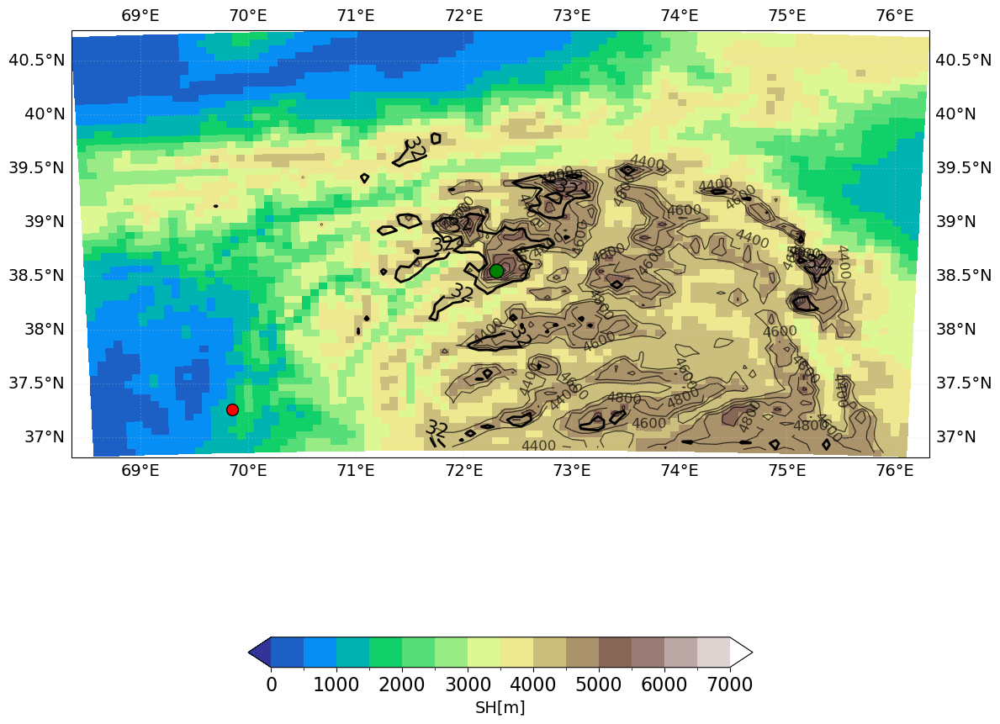

In [8]:
ice_level=32# % of ice on grid cell

clevs=np.arange(0,7500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(LONS_pamir, LATS_pamir, SH_pamir,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

# ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
#             levels=[10,ice_level,100],
#             hatches=['','X','X'],
#             colors="none",
#             transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(LONS_pamir, LATS_pamir, SH_pamir,
                             levels=[4400,4600,4800,5000,5200,5400,5600,5800,6000,6200,6400,6600,6800,7000],
                             colors="k", linewidths=0.9, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(LONS_pamir, LATS_pamir, ICE_pamir,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")
 
# ax.set_extent([71, 72, 39.4, 40], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="lightgray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# red dot = point de SMB = O
ax.plot(LON_0, LAT_0,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

# Identifier le point de grille ou se trouve la carotte Jasgulem
ax.plot(LONS_pamir[iY, iX], LATS_pamir[iY, iX],
        marker='o', markersize=12,
        markeredgecolor='black', markerfacecolor='green',
        transform=ccrs.PlateCarree())

plt.show()

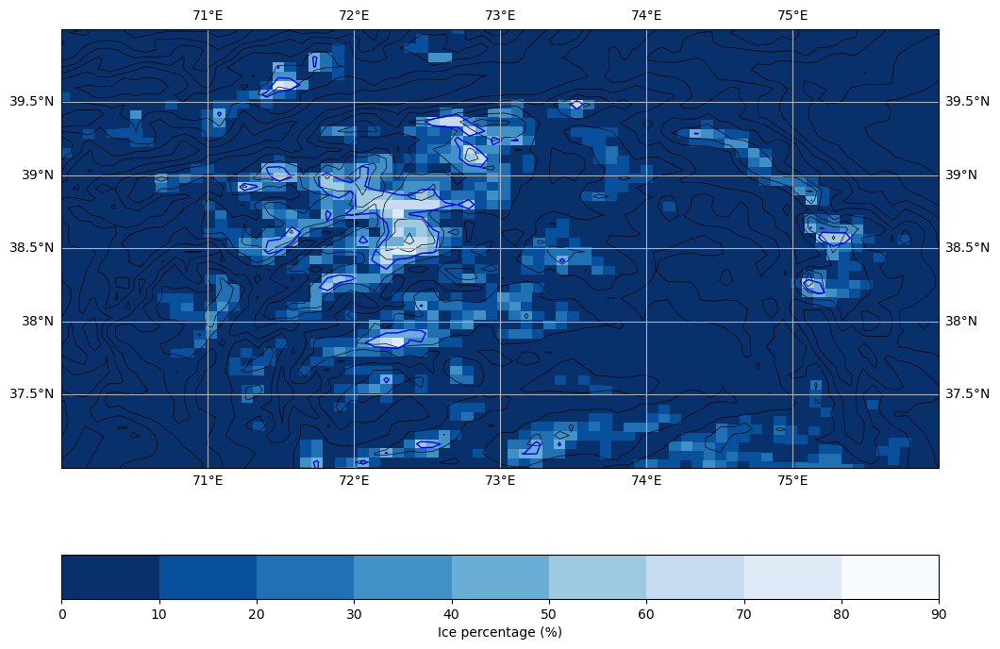

In [9]:
ice_level = 40 # Seuil à partir duquel on considère qu'on observe de la glace

clevs = np.arange(0, 100, 10) # Echelle de couleur de 0 à 100% tous les 10%
cmap = plt.get_cmap("Blues_r") # Palette de couleur bleu (reverse) pour voir le % de glace par grille
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) 


fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(LONS_pamir, LATS_pamir, SH_pamir, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Countour glaciers ####
ax.contour(LONS_pamir, LATS_pamir, ICE_pamir, 
           levels=[ice_level], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

# #### Mera Peak coord ####
# ax.plot(merap_lon, merap_lat,  # Coord exact du Mera Peak
#         marker='o', markersize=10,
#         markeredgecolor='black', markerfacecolor='red',
#         transform=ccrs.PlateCarree())

#### Percentage of ice ####
im = ax.pcolormesh(LONS_pamir, LATS_pamir,ICE_pamir,
                   cmap=cmap, norm=norm, # Affiche la couleur du % de glace
                   transform=ccrs.PlateCarree(),
                   shading="auto")
ax.set_extent([70, 76, 37, 40], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
#ax.set_extent([86.7, 87.1, 27.6, 27.9], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable zoom

ax.gridlines(draw_labels=True) # Grille de lattitude et longitude
plt.colorbar(im, orientation="horizontal", pad=0.1, label="Ice percentage (%)") # Paramètres de la barre d'altitude (disposition horizontale / taille / légende)
plt.show()

## 2. HIMAP areas

### Load HIMAP area

In [10]:
himap_folder = "/bettik/PROJECTS/pr-regional-climate/fainx/HMA_regions_Bolch/boundary_mountain_regions_hma_v3.shp"
regions = gpd.read_file(himap_folder)
regions = regions.to_crs(epsg=4326)
regions[['OBJECTID','Primary_ID']]

,OBJECTID,Primary_ID
0,8,Eastern Hindu Kush
1,10,Western Himalaya
2,12,Eastern Himalaya
3,11,Central Himalaya
4,9,Karakoram
5,6,Western Pamir
6,5,Pamir Alay
7,4,Northern/Western Tien Shan
8,1,Dzhungarsky Alatau
9,13,Western Kunlun Shan


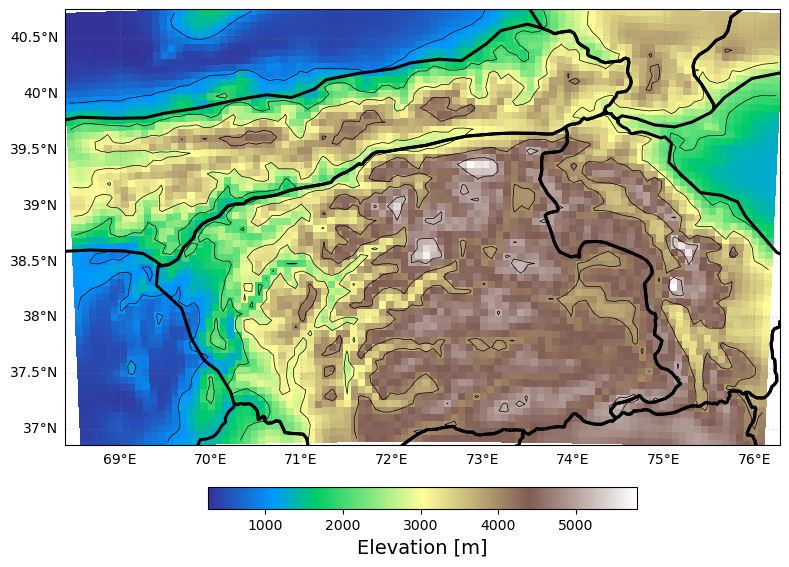

In [11]:
cmap = 'terrain'

fig = plt.figure(figsize=(8, 9))
ax2 = fig.add_subplot(111, projection=ccrs.PlateCarree())

ax2.set_extent([
    LONS_pamir.min(), LONS_pamir.max(),
    LATS_pamir.min(), LATS_pamir.max()
], crs=ccrs.PlateCarree())


# --- DATA ---
CS2 = ax2.pcolormesh(LONS_pamir, LATS_pamir, SH_pamir,
                     transform=ccrs.PlateCarree(),
                     cmap=cmap, shading="auto")

# --- CONTOURS ---
ax2.contour(LONS_pamir, LATS_pamir, SH_pamir,
            levels=[1000, 2000, 3000, 4000, 5000, 6000, 7000],
            colors="k", linewidths=0.5,
            transform=ccrs.PlateCarree())

# --- REGIONS  ---
regions.boundary.plot(
    ax=ax2,
    edgecolor='black',
    linewidth=2.2,
    transform=ccrs.PlateCarree()
)

# --- GRIDLINES ---
gl = ax2.gridlines(draw_labels=True,
                   linewidth=1, color="gray",
                   alpha=0.3, linestyle=":")
gl.top_labels = False
gl.right_labels = False

# --- COLORBAR ---
cbar = fig.colorbar(
    CS2,
    ax=ax2,
    orientation="horizontal",
    pad=0.05,
    fraction=0.05,
    shrink=0.6
)

cbar.set_label("Elevation [m]", fontsize=14)

plt.tight_layout()
plt.show()

### Create masks for different HIMAP regions

In [12]:
regions_mask = regionmask.from_geopandas(
    regions,
    names="Primary_ID",   # ou autre colonne
    numbers="OBJECTID"
)

mask = regions_mask.mask(LONS_pamir, LATS_pamir)

region_id = dict(zip(regions["Primary_ID"], regions["OBJECTID"]))
region_id

{'Eastern Hindu Kush': 8,
 'Western Himalaya': 10,
 'Eastern Himalaya': 12,
 'Central Himalaya': 11,
 'Karakoram': 9,
 'Western Pamir': 6,
 'Pamir Alay': 5,
 'Northern/Western Tien Shan': 4,
 'Dzhungarsky Alatau': 1,
 'Western Kunlun Shan': 13,
 'Nyainqentanglha': 18,
 'Gangdise Mountains': 17,
 'Hengduan Shan': 20,
 'Tibetan Interior Mountains': 16,
 'Tanggula Shan': 19,
 'Eastern Tibetan Mountains': 21,
 'Qilian Shan': 22,
 'Eastern Kunlun Shan': 14,
 'Altun Shan': 15,
 'Eastern Tien Shan': 2,
 'Central Tien Shan': 3,
 'Eastern Pamir': 7}

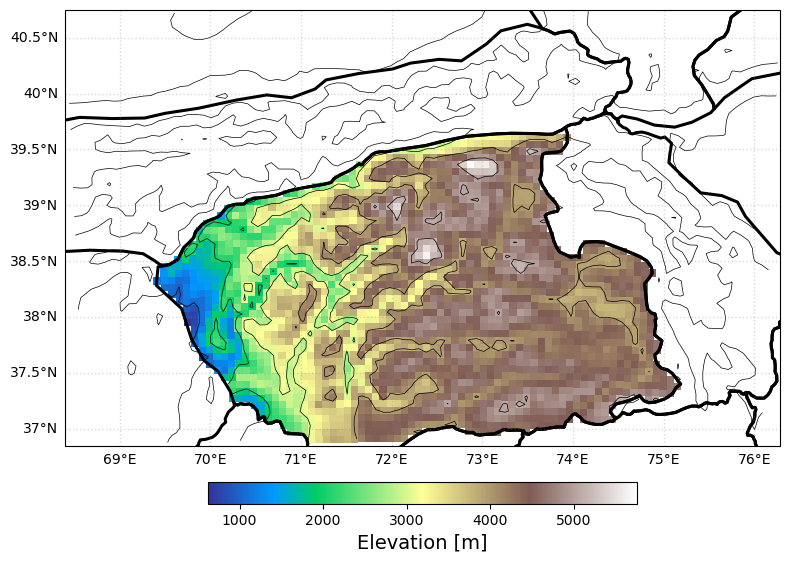

In [13]:
# Test

cmap = 'terrain'

fig = plt.figure(figsize=(8, 8))
ax2 = fig.add_subplot(111, projection=ccrs.PlateCarree())

ax2.set_extent([
    LONS_pamir.min(), LONS_pamir.max(),
    LATS_pamir.min(), LATS_pamir.max()
], crs=ccrs.PlateCarree())


# --- DATA ---
CS2 = ax2.pcolormesh(LONS_pamir, LATS_pamir, SH_pamir.where(mask == 6),
                     transform=ccrs.PlateCarree(),
                     cmap=cmap, shading="auto")

# --- CONTOURS ---
ax2.contour(LONS_pamir, LATS_pamir, SH_pamir,
            levels=[1000, 2000, 3000, 4000, 5000, 6000, 7000],
            colors="k", linewidths=0.5,
            transform=ccrs.PlateCarree())

# --- REGIONS ---
regions.boundary.plot(
    ax=ax2,
    edgecolor='black',
    linewidth=2.2,
    transform=ccrs.PlateCarree()
)

# --- GRIDLINES ---
gl = ax2.gridlines(draw_labels=True,
                   linewidth=1, color="gray",
                   alpha=0.3, linestyle=":")
gl.top_labels = False
gl.right_labels = False

# --- COLORBAR ---
cbar = fig.colorbar(
    CS2,
    ax=ax2,
    orientation="horizontal",
    pad=0.05,
    fraction=0.05,
    shrink=0.6
)


cbar.set_label("Elevation [m]", fontsize=14)

plt.tight_layout()
plt.show()

## 3. MAR SMB

### Load MAR SMB data

In [14]:
variable='SMB' 
#"Surface Mass Balance (SMB~SF+RF-RU-SU-SW)" 

ds_SMB = xr.open_mfdataset(sourceData_1 + "SMB_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SMB.isel(SECTOR=0).load()

ds_SMB = ds_SMB.assign_coords(X=np.round(ds_SMB.X.values))
ds_SMB = ds_SMB.assign_coords(Y=np.round(ds_SMB.Y.values))
ds_SMB = ds_SMB.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SMB = ds_SMB[:,nx:-nx,nx:-nx]

# Passer en m WE/yr
ds_SMB = ds_SMB/1000

In [15]:
ds_SMB = ds_SMB.chunk({"time": 50, "Y": 62, "X": 96})

In [16]:
mask_smb = xr.DataArray(
    mask,
    dims=("Y", "X"),
    coords={
        "Y": ds_SMB.Y,
        "X": ds_SMB.X
    }
)

### MAR SMB for each sub-regions

In [17]:
ds_SMB_PA = ds_SMB.where(mask_smb == region_id["Pamir Alay"])
ds_SMB_WP = ds_SMB.where(mask_smb ==  region_id["Western Pamir"])
ds_SMB_EP = ds_SMB.where(mask_smb ==  region_id["Eastern Pamir"])

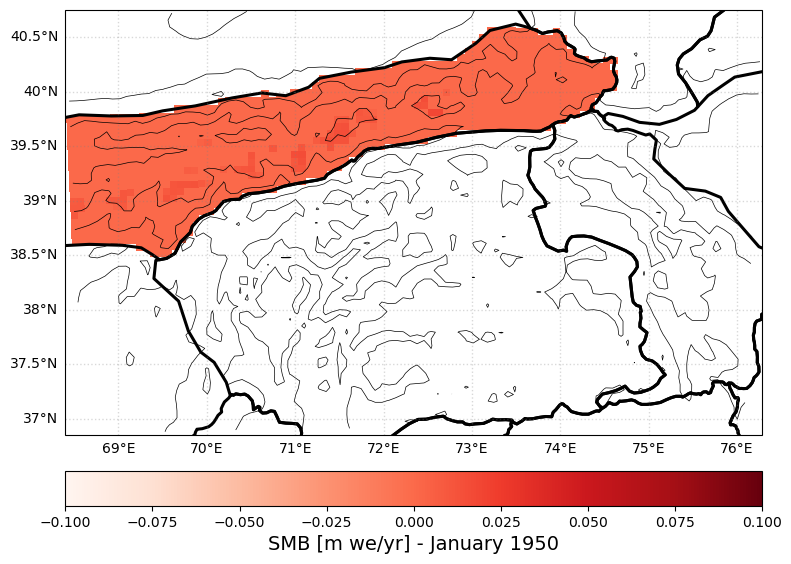

In [18]:
#Test plot

cmap = 'Red'

norm = colors.Normalize(
    vmin=0,
    vmax = ds_SMB_PA.isel(time=6).max().compute().item()
)

fig = plt.figure(figsize=(8, 8))
ax2 = fig.add_subplot(111, projection=ccrs.PlateCarree())

ax2.set_extent([
    LONS_pamir.min(), LONS_pamir.max(),
    LATS_pamir.min(), LATS_pamir.max()
], crs=ccrs.PlateCarree())


# --- DATA ---
CS2 = ax2.pcolormesh(
    LONS_pamir,
    LATS_pamir,
    ds_SMB_PA.isel(time=1),
    cmap="Reds",
    norm=norm,
    transform=ccrs.PlateCarree(),
    shading="auto"
)

# --- CONTOURS ---
ax2.contour(LONS_pamir, LATS_pamir, SH_pamir,
            levels=[1000, 2000, 3000, 4000, 5000, 6000, 7000],
            colors="k", linewidths=0.5,
            transform=ccrs.PlateCarree())

# --- REGIONS ---
regions.boundary.plot(
    ax=ax2,
    edgecolor='black',
    linewidth=2.2,
    transform=ccrs.PlateCarree()
)

# --- GRIDLINES ---
gl = ax2.gridlines(draw_labels=True,
                   linewidth=1, color="gray",
                   alpha=0.3, linestyle=":")
gl.top_labels = False
gl.right_labels = False

# --- COLORBAR ---
cbar = fig.colorbar(CS2, ax=ax2,
                    orientation="horizontal",
                    pad=0.05, fraction=0.05)

cbar.set_label("SMB [m we/yr] - January 1950", fontsize=14)

plt.tight_layout()
plt.show()

### Extract decadal mean SMB per region and per altitudinal bands

In [19]:
#Exclude the upper z-level integrating only 1 grid cell:
#max_elev_bin=6500
#elev_bins = np.arange(0, np.nanmax(max_elev_bin) + 250, 250)

#Consider all altitudinal level possible::
elev_bins = np.arange(0, np.nanmax(SH_pamir.values.flatten()) + 250, 250)

elev_bin_labels = (elev_bins[:-1] + elev_bins[1:]) / 2

In [20]:
# Compute mean of annual SMB on the considered period + binning

yr_start = '2000-01-16T12:00:00.000000000'
yr_stop = '2008-12-16T12:00:00.000000000'

dsList = [
    ds_SMB_PA,
    ds_SMB_EP,
    ds_SMB_WP
]

mean_data_by_elev_List = []
mean_data_by_elev_List_2000 = []
alt = SH_pamir.values.flatten()

for elem in dsList:
    data = elem.sel(time=slice(yr_start, yr_stop)) # selection de période
    data = data.resample(time="1Y").sum() # calcul du SMB (cumul) annuel
    data = data.mean(dim="time") # valeur moyenne du cumul annuel sur la période
    
    data_flat = data.values.flatten()
    
    df = pd.DataFrame({'elevation': alt, 'smb': data_flat})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)
    df = df[df['smb'] != 0] #Beaucoup de valeurs nulles de SMB qui fausseraient la moyenne
    mean_data_by_elev = df.groupby('elev_bin')['smb'].mean()
    mean_data_by_elev_List.append(mean_data_by_elev)
    
mean_data_by_elev_List_2000 = mean_data_by_elev_List
#mean_data_by_elev_List_2000

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/tmp/ipykernel_3755300/2629757351.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_data_by_elev = df.groupby('elev_bin')['smb'].mean()
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/tmp/ipykernel_3755300/2629757351.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=

In [21]:
# Compute mean of annual SMB on the considered period + binning

yr_start = '2009-01-16T12:00:00.000000000'
yr_stop = '2018-12-16T12:00:00.000000000'

dsList = [
    ds_SMB_PA,
    ds_SMB_EP,
    ds_SMB_WP
]

mean_data_by_elev_List = []
mean_data_by_elev_List_2009 = []
alt = SH_pamir.values.flatten()

for elem in dsList:
    data = elem.sel(time=slice(yr_start, yr_stop)) # selection de période
    data = data.resample(time="1Y").sum() # calcul du SMB (cumul) annuel
    data = data.mean(dim="time") # valeur moyenne du cumul annuel sur la période
    
    data_flat = data.values.flatten() 
    
    df = pd.DataFrame({'elevation': alt, 'smb': data_flat})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)
    df = df[df['smb'] != 0] #Beaucoup de valeurs nulles de SMB qui fausseraient la moyenne
    mean_data_by_elev = df.groupby('elev_bin')['smb'].mean()
    mean_data_by_elev_List.append(mean_data_by_elev)
    
mean_data_by_elev_List_2009 = mean_data_by_elev_List
#mean_data_by_elev_List_2009

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/tmp/ipykernel_3755300/523834272.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_data_by_elev = df.groupby('elev_bin')['smb'].mean()
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/tmp/ipykernel_3755300/523834272.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=Tr

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/tmp/ipykernel_3755300/4247331081.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby('elev_bin')['smb'].agg(['mean', 'std', 'count']).dropna()
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/tmp/ipykernel_3755300/4247331081.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current b

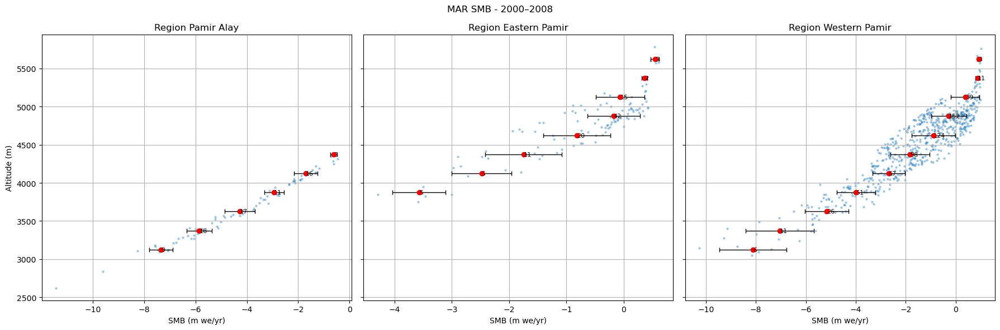

In [22]:
# Plot SMB per altiltude for each Sub-regions - 2000-2008

yr_start = '2000-01-16T12:00:00.000000000'
yr_stop = '2008-12-16T12:00:00.000000000'

dsList = [
    ds_SMB_PA,
    ds_SMB_EP,
    ds_SMB_WP
]

region_names = ["Pamir Alay", "Eastern Pamir", "Western Pamir"]
fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=True)

for i, ax in enumerate(axes):
    
    ds = dsList[i].sel(time=slice(yr_start, yr_stop)) \
                  .resample(time="1Y").sum() \
                  .mean(dim="time")

    smb = ds.values.flatten()
    alt = SH_pamir.values.flatten()

    mask_2 = (smb != 0) & (alt != 0)

    smb = smb[mask_2]
    alt = alt[mask_2]

    # Scatter brut
    ax.scatter(smb, alt, s=5, alpha=0.3)

    # DataFrame
    df = pd.DataFrame({'elevation': alt, 'smb': smb})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)

    # Stats par bin
    stats = df.groupby('elev_bin')['smb'].agg(['mean', 'std', 'count']).dropna()

    y = stats.index.astype(float)  # altitude (bins)
    x = stats['mean']
    xerr = stats['std']

    # Points + barres d'erreur
    ax.errorbar(x, y, xerr=xerr,
                fmt='o', color='red', ecolor='black',
                elinewidth=1, capsize=3)

    # Ajouter n
    for xi, yi, ni in zip(x, y, stats['count']):
        ax.text(xi, yi, f"{int(ni)}",
                fontsize=8, ha='left', va='center')

    ax.set_title(f"Region {region_names[i]}")
    ax.set_xlabel("SMB (m we/yr)")
    ax.grid()

axes[0].set_ylabel("Altitude (m)")

plt.suptitle("MAR SMB - 2000–2008")
plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/tmp/ipykernel_3755300/2599922416.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby('elev_bin')['smb'].agg(['mean', 'std', 'count']).dropna()
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/tmp/ipykernel_3755300/2599922416.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current b

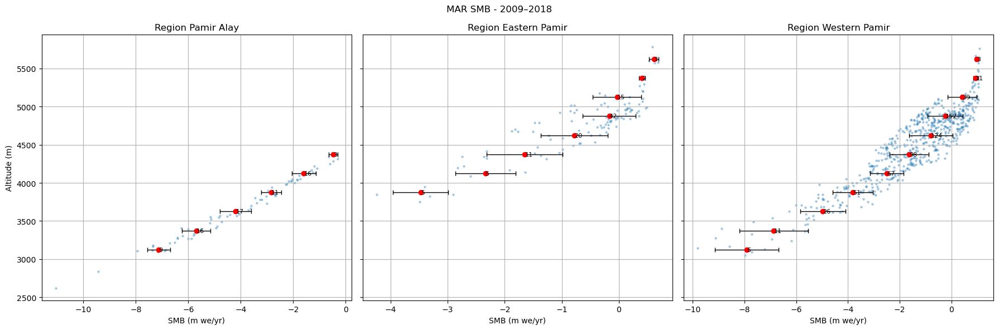

In [23]:
# Plot SMB per altiltude for each Sub-regions - 2009-2018

yr_start = '2009-01-16T12:00:00.000000000'
yr_stop = '2018-12-16T12:00:00.000000000'

dsList = [
    ds_SMB_PA,
    ds_SMB_EP,
    ds_SMB_WP
]

region_names = ["Pamir Alay", "Eastern Pamir", "Western Pamir"]
fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=True)

for i, ax in enumerate(axes):
    
    ds = dsList[i].sel(time=slice(yr_start, yr_stop)) \
                  .resample(time="1Y").sum() \
                  .mean(dim="time")

    smb = ds.values.flatten()
    alt = SH_pamir.values.flatten()

    mask_2 = (smb != 0) & (alt != 0)

    smb = smb[mask_2] 
    alt = alt[mask_2]

    # Scatter brut
    ax.scatter(smb, alt, s=5, alpha=0.3)

    # DataFrame
    df = pd.DataFrame({'elevation': alt, 'smb': smb})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)

    # Stats par bin
    stats = df.groupby('elev_bin')['smb'].agg(['mean', 'std', 'count']).dropna()

    y = stats.index.astype(float)  # altitude (bins)
    x = stats['mean']
    xerr = stats['std']

    # Points + barres d'erreur
    ax.errorbar(x, y, xerr=xerr,
                fmt='o', color='red', ecolor='black',
                elinewidth=1, capsize=3)

    # Ajouter n
    for xi, yi, ni in zip(x, y, stats['count']):
        ax.text(xi, yi, f"{int(ni)}",
                fontsize=8, ha='left', va='center')

    ax.set_title(f"Region {region_names[i]}")
    ax.set_xlabel("SMB (m we/yr)")
    ax.grid()

axes[0].set_ylabel("Altitude (m)")

plt.suptitle("MAR SMB - 2009–2018")
plt.tight_layout()
plt.show()

### Extract decadal temporal series of SMB per region

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


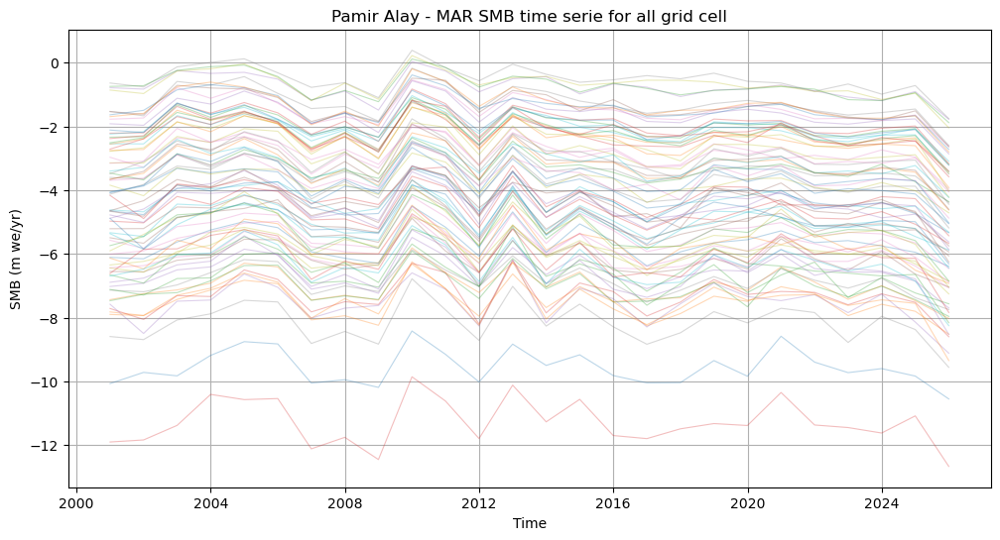

In [24]:
# Tres faible variabilité temporelle du SMB sur les deux périodes choisies (20 ans au total), par rapport à la variabilité altitudinale
# => Tracer les timeseries des glacier du Pamir Alay, par exemple

yr_start = '2000-01-16T12:00:00.000000000'
yr_stop = '2025-12-16T12:00:00.000000000'

da = ds_SMB_PA.sel(time=slice(yr_start, yr_stop)).resample(time="1Y").sum()

da2 = da.stack(points=("Y", "X"))

valid = (da2 != 0).any(dim="time").values 

da2 = da2[:, valid]

plt.figure(figsize=(12,6))

for i in range(da2.points.size):
    plt.plot(da2.time, da2[:, i], alpha=0.3, linewidth=0.8)

plt.xlabel("Time")
plt.ylabel("SMB (m we/yr)")
plt.title("Pamir Alay - MAR SMB time serie for all grid cell")
plt.grid()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


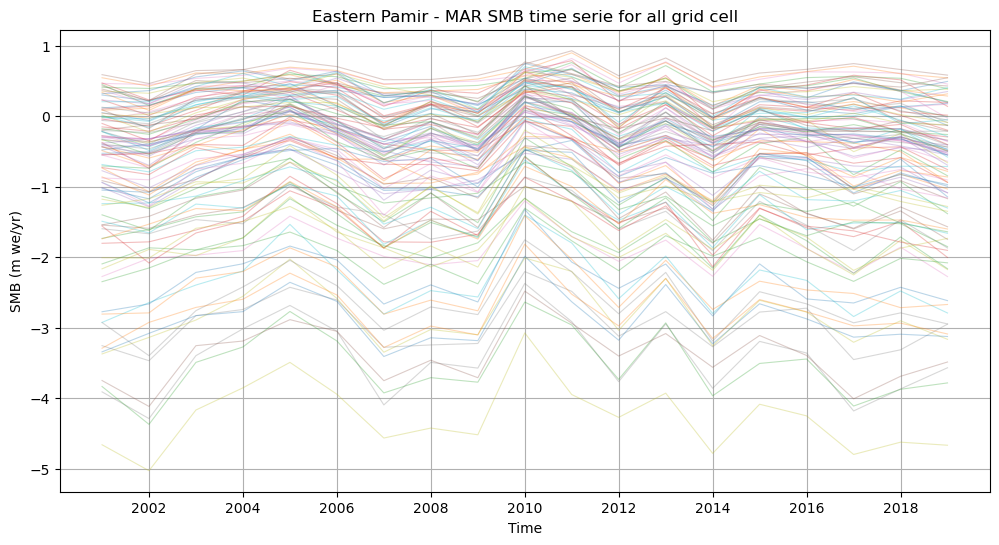

In [25]:
# Tres faible variabilité temporelle du SMB sur les deux périodes choisies (20 ans au total), par rapport à la variabilité altitudinale
# => Tracer les timeseries des glacier du Pamir Alay, par exemple

yr_start = '2000-01-16T12:00:00.000000000'
yr_stop = '2018-12-16T12:00:00.000000000'

da = ds_SMB_EP.sel(time=slice(yr_start, yr_stop)).resample(time="1Y").sum()

da2 = da.stack(points=("Y", "X"))

valid = (da2 != 0).any(dim="time").values 

da2 = da2[:, valid]

plt.figure(figsize=(12,6))

for i in range(da2.points.size):
    plt.plot(da2.time, da2[:, i], alpha=0.3, linewidth=0.8)

plt.xlabel("Time")
plt.ylabel("SMB (m we/yr)")
plt.title("Eastern Pamir - MAR SMB time serie for all grid cell")
plt.grid()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


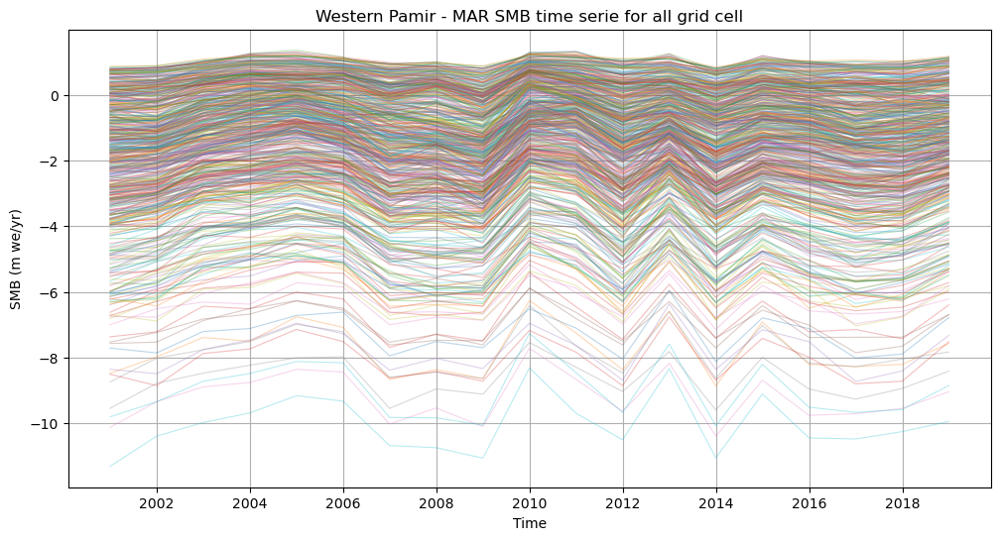

In [26]:
yr_start = '2000-01-16T12:00:00.000000000'
yr_stop = '2018-12-16T12:00:00.000000000'

da = ds_SMB_WP.sel(time=slice(yr_start, yr_stop)).resample(time="1Y").sum()

da2 = da.stack(points=("Y", "X"))

valid = (da2 != 0).any(dim="time").values 

da2 = da2[:, valid]

plt.figure(figsize=(12,6))

for i in range(da2.points.size):
    plt.plot(da2.time, da2[:, i], alpha=0.3, linewidth=0.8)

plt.xlabel("Time")
plt.ylabel("SMB (m we/yr)")
plt.title("Western Pamir - MAR SMB time serie for all grid cell")
plt.grid()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


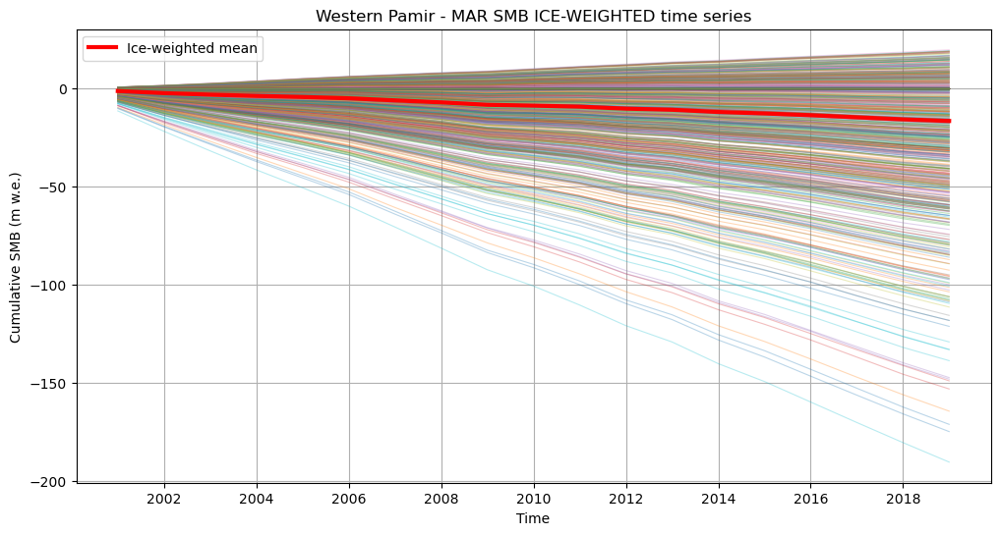

In [27]:
yr_start = '2000-01-16T12:00:00.000000000'
yr_stop = '2018-12-16T12:00:00.000000000'

da = ds_SMB_WP.sel(time=slice(yr_start, yr_stop)).resample(time="1Y").sum()

cum_smb = da.cumsum(dim="time")

# Empilement spatial
da2 = cum_smb.stack(points=("Y", "X"))

# Empilement du masque glacier
ice = ICE_pamir.stack(points=("Y", "X"))

# Garder uniquement les pixels glacier
valid = ice > 0

da2 = da2.where(valid, drop=True)
ice = ice.where(valid, drop=True)


plt.figure(figsize=(12,6))

# Séries temporelles de tous les pixels glacier
for i in range(da2.points.size):
    plt.plot(
        da2.time,
        da2[:, i],
        alpha=0.3,
        linewidth=0.8
    )


# Moyenne pondérée par ICE_pamir
weighted_mean = (da2 * ice).sum(dim="points") / ice.sum()

plt.plot(
    da2.time,
    weighted_mean,
    color='red',
    lw=3,
    label='Ice-weighted mean'
)

plt.xlabel("Time")
plt.ylabel("Cumulative SMB (m w.e.)")
plt.title("Western Pamir - MAR SMB ICE-WEIGHTED time series")
plt.grid()
plt.legend()

plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


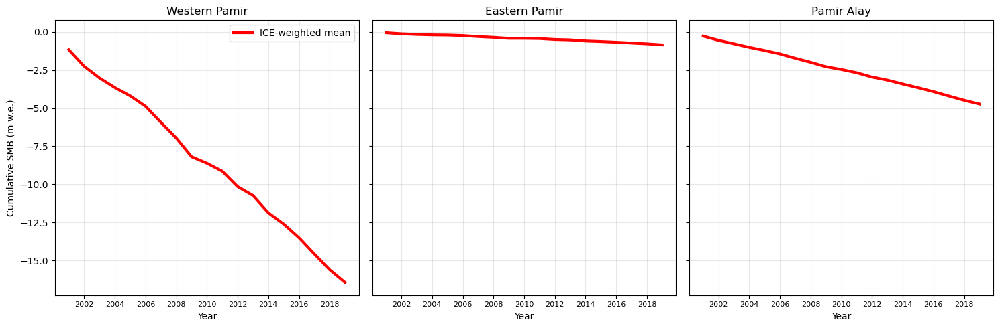

In [28]:
# ==========================
# Datasets MAR
# ==========================

ds_list = [ds_SMB_WP, ds_SMB_EP, ds_SMB_PA]
titles = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']


yr_start = '2000-01-16T12:00:00'
yr_stop  = '2018-12-16T12:00:00'


# ==========================
# Figure 3 panels
# ==========================

fig, axes = plt.subplots(
    1, 3,
    figsize=(15,5),
    sharex=True,
    sharey=True
)


for ax, ds, title in zip(axes, ds_list, titles):

    # SMB annuel
    da = (
        ds
        .sel(time=slice(yr_start, yr_stop))
        .resample(time="1Y")
        .sum()
    )

    # SMB cumulatif
    cum_smb = da.cumsum(dim="time")


    # ==========================
    # Pondération ICE_pamir
    # ==========================

    # Garder uniquement les pixels glacier
    weights = ICE_pamir.where(ICE_pamir > 0).fillna(0)

    # moyenne pondérée spatiale
    weighted_mean = (
        cum_smb
        .weighted(weights)
        .mean(dim=("Y", "X"))
    )


    # Plot
    ax.plot(
        weighted_mean.time,
        weighted_mean,
        color='red',
        lw=3,
        label='ICE-weighted mean'
    )


    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(alpha=0.3)


axes[0].set_ylabel("Cumulative SMB (m w.e.)")
axes[0].legend()

plt.tight_layout()
plt.show()

### MAR at Fedchenko

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(


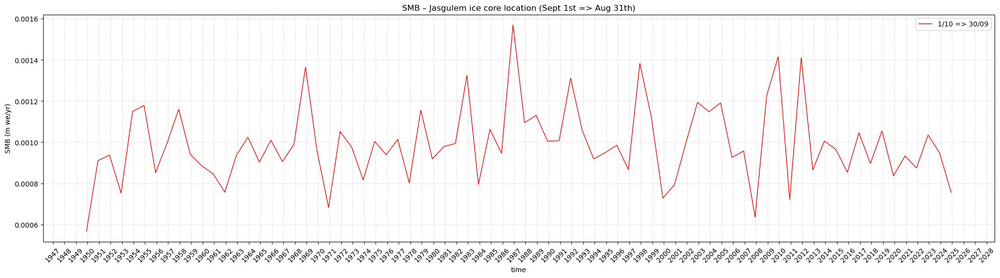

In [29]:
plt.figure(figsize=(25,8))

# Point précis Jasgulem
ds_jasg = ds_SMB_WP.isel(Y=iY, X=iX)

ds_jasg_aug = ds_jasg.resample(time="A-AUG").sum().sel(time=slice("1950-08-31", "2025-09-01"))/1000
ds_jasg_aug['time'] = (ds_jasg_aug['time'].values.astype('datetime64[M]') - np.timedelta64(8, 'M')).astype('datetime64[ns]') #plot yr 2014-2015 on 1/1/2015 similar to Lambrecht

ds_jasg_aug.plot(label="1/10 => 30/09", linewidth=1, color="red")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# Ajustement des marges pour éviter le chevauchement
plt.subplots_adjust(bottom=0.3)  # Plus d'espace en bas

plt.legend(ncol=3)
plt.title("SMB – Jasgulem ice core location (Sept 1st => Aug 31th)")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)

plt.savefig("FIG_smb.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
#VERIF ci dessous vs autre notebook

In [ ]:


# ==========================
# Datasets MAR
# ==========================

ds_list = [ds_SMB_WP, ds_SMB_EP, ds_SMB_PA]
titles = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']


yr_start = '1980-01-16T12:00:00'
yr_stop  = '2018-12-16T12:00:00'


# ==========================
# Figure 3 panels
# ==========================

fig, axes = plt.subplots(
    1, 3,
    figsize=(15,5),
    sharex=True,
    sharey=True
)


for ax, ds, title in zip(axes, ds_list, titles):

    # SMB annuel
    da = (
        ds
        .sel(time=slice(yr_start, yr_stop))
        .resample(time="1Y")
        .sum()
    )

    # SMB cumulatif
    cum_smb = da#.cumsum(dim="time")


    # ==========================
    # Pondération ICE_pamir
    # ==========================

    # Garder uniquement les pixels glacier
    weights = ICE_pamir.where(ICE_pamir > 0).fillna(0)

    # moyenne pondérée spatiale
    weighted_mean = (
        cum_smb
#        .weighted(weights)
        .mean(dim=("Y", "X"))
    )


    # Plot
    ax.plot(
        weighted_mean.time,
        weighted_mean,
        color='red',
        lw=3,
        label='ICE-weighted mean'
    )


    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(alpha=0.3)


axes[0].set_ylabel("Cumulative SMB (m w.e.)")
axes[0].legend()

plt.tight_layout()
plt.show()

# 4. Observation  dataset

### WGMS database

In [30]:
wgms_folder ='/bettik/PROJECTS/pr-regional-climate/fainx/PAMIR_SMB_OBS/WGMS-FoG-2026-02-10/'
wgms_file_glacier = 'glacier.csv'
wgms_file_smb = 'mass_balance.csv'

In [31]:
# WGMS Glacier ID
wgms_glaciers_list = [
    {"name": "Abramov", "id" : 732},
    {"name": "Zulmart", "id" : 13493},
    {"name": "Kyzylsu", "id" : 9276},
    # {"name": "Uruqmi", "id" : 853}, Hors domaine Pamir
    {"name": "Glacier_457", "id" : 21063}]

     
others_glaciers_list = [
    # {"name": "Grigoriev ", "lat":41.975, "lon" : 77.913}, Hors Pamir
    {"name": "Kangxiwa  ", "latitude": 38.28, "longitude" : 75.28},
    {"name": "Fedchenko", "latitude": 38.54063, "longitude" : 72.269816},
    {"name": "Kon Chukurbashi  ", "latitude": 39.250066, "longitude" :  73.557790}]

In [32]:
wgms_glacier_df = pd.read_csv(wgms_folder+wgms_file_glacier , sep=",")
wgms_glaciers_list_df = pd.DataFrame(wgms_glaciers_list)

wgms_glaciers = (
    wgms_glaciers_list_df
    .merge(wgms_glacier_df[["id", "latitude", "longitude"]], on="id", how="left")
)
wgms_glaciers['id']

0      732
1    13493
2     9276
3    21063
Name: id, dtype: int64

## RGI database

#### RGI v6 (https://www.glims.org/RGI/randolph60.html)

In [64]:
rgi_v6 = gpd.read_file(
    "/bettik/PROJECTS/pr-regional-climate/fainx/PAMIR_SMB_OBS/RGI/v6/13_rgi60_CentralAsia.shp"
)
print(rgi_v6.columns)

Index(['RGIId', 'GLIMSId', 'BgnDate', 'EndDate', 'CenLon', 'CenLat',
       'O1Region', 'O2Region', 'Area', 'Zmin', 'Zmax', 'Zmed', 'Slope',
       'Aspect', 'Lmax', 'Status', 'Connect', 'Form', 'TermType', 'Surging',
       'Linkages', 'Name', 'geometry'],
      dtype='object')


#### RGI v7

In [34]:
fedchenko_rgi = 13.54431

## Dussaillant et al. 2025

In [49]:
## this dataset reported on RGI v6

dus_folder ='/bettik/PROJECTS/pr-regional-climate/fainx/PAMIR_SMB_OBS/dussaillant_2025/'
dus_file_glacier = 'ASC_metadata.csv'
dus_file_smb = 'ASC_mwe.csv'

In [50]:
dus_glacier_df = pd.read_csv(dus_folder + dus_file_glacier)
dus_smb_df = pd.read_csv(dus_folder + dus_file_smb)
dus_df = dus_glacier_df.merge(dus_smb_df, on='outline_id', how='inner')

In [51]:
# Get glacier altitudes from RGI and include them to Dussaillant dataset

rgi_v6["key"] = rgi_v6["RGIId"]# .str[-5:]

dus_df["outline_id"] = dus_df["outline_id"].astype(str)
dus_df["key"] = dus_df["outline_id"]# .str[-5:]

dus_df = dus_df.merge(
    rgi_v6[["key", 'Zmin', 'Zmax', 'Zmed']], # checked that area, lon, and lat reported by Dussaillant are identical to RGI v6 database => OK
    on="key",
    how="left"
)

dus_df = dus_df.drop(columns=["key"])
dus_df = dus_df.rename(columns={"longitude": "lon"})
dus_df = dus_df.rename(columns={"latitude": "lat"})
dus_df = dus_df.rename(columns={"area_km2": "area"})

In [52]:
# Calculate mean SMB per decade

cols_2000_2009 = [str(y) for y in range(2000, 2010)]
cols_2010_2018 = [str(y) for y in range(2010, 2019)]

dus_df["2000_2009_mean"] = dus_df[cols_2000_2009].mean(axis=1)
dus_df["2010_2018_mean"] = dus_df[cols_2010_2018].mean(axis=1)

### Compilation in sub-region

In [54]:
gdf = gpd.GeoDataFrame(
    dus_df,
    geometry=gpd.points_from_xy(dus_df["lon"], dus_df["lat"]),
    crs="EPSG:4326"
)

gdf_joined = gpd.sjoin(
    gdf,
    regions[["OBJECTID", "Primary_ID", "geometry"]],
    how="left",
    predicate="within"
)

dus_df = gdf_joined.drop(columns="geometry")

ValueError: 'index_right' cannot be a column name in the frames being joined

In [40]:
dus_df.head()

,outline_id,glacier_id,lat,lon,area,1957,1958,1959,1960,1961,...,2024,2025,Zmin,Zmax,Zmed,2000_2009_mean,2010_2018_mean,index_right,OBJECTID,Primary_ID
0,RGI60-13.00001,146408.0,34.4713,79.4939,0.432,0.299,0.779,0.310,0.347,0.179,...,-0.922,-0.923,5678,5928,5763,-0.1794,-0.049111,4,9,Karakoram
1,RGI60-13.00002,146409.0,35.5452,77.9513,0.367,0.439,0.919,0.438,0.487,0.307,...,-0.800,-0.841,5889,6217,6051,-0.0297,0.092889,4,9,Karakoram
2,RGI60-13.00003,146410.0,35.5188,77.9295,0.070,0.575,1.055,0.574,0.624,0.443,...,-0.663,-0.704,5646,5849,5756,0.1059,0.229222,4,9,Karakoram
3,RGI60-13.00004,146411.0,35.5252,77.9237,0.255,0.377,0.857,0.376,0.426,0.245,...,-0.861,-0.903,5698,5850,5756,-0.0922,0.031000,4,9,Karakoram
4,RGI60-13.00005,146412.0,35.5309,77.9141,0.261,0.338,0.818,0.337,0.386,0.206,...,-0.900,-0.942,5644,5809,5745,-0.1313,-0.008000,4,9,Karakoram


In [41]:
dus_df_PA = dus_df[dus_df["OBJECTID"] == 5]
dus_df_WP = dus_df[dus_df["OBJECTID"] == 6]
dus_df_EP = dus_df[dus_df["OBJECTID"] == 7]

print('Nombre de glaciers recensé en Pamir Alay:', dus_df_PA.shape[0])
print('Nombre de glaciers recensé en Western Pamir:', dus_df_WP.shape[0])
print('Nombre de glaciers recensé en Eastern Pamir:', dus_df_EP.shape[0])

Nombre de glaciers recensé en Pamir Alay: 3151
Nombre de glaciers recensé en Western Pamir: 8833
Nombre de glaciers recensé en Eastern Pamir: 1400


### Focus Dussaillant sur Fedchenko

In [42]:
# DUssaillant data for Fedchanko
dus_df_fed = dus_df[dus_df["outline_id"] == "RGI60-13.54431"]
dus_df_fed

,outline_id,glacier_id,lat,lon,area,1957,1958,1959,1960,1961,...,2024,2025,Zmin,Zmax,Zmed,2000_2009_mean,2010_2018_mean,index_right,OBJECTID,Primary_ID
54440,RGI60-13.54431,194839.0,38.78024,72.23385,663.729,0.137,0.617,0.1,0.186,-0.032,...,-1.018,-1.247,2908,7392,4933,-0.2731,-0.175333,5,6,Western Pamir


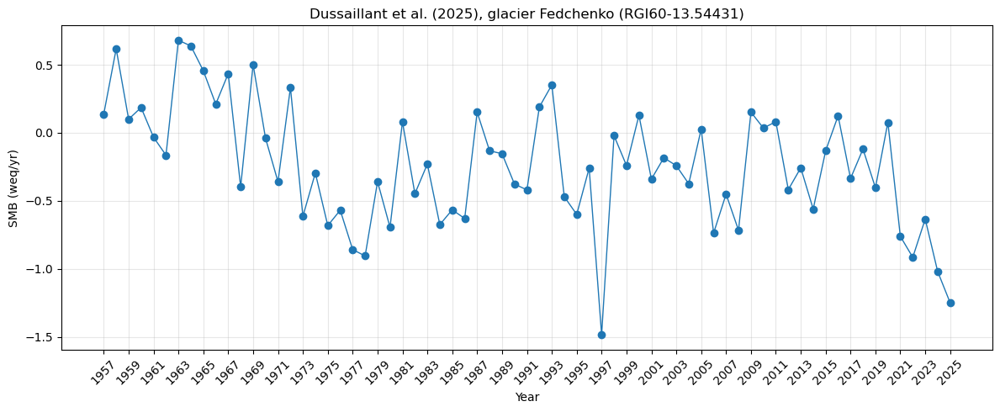

In [43]:
# Série SMB pour Fedchanko

# Identifier les colonnes correspondant aux années
years = [col for col in dus_df_fed.columns if str(col).isdigit() and 1900 <= int(col) <= 2100]

# Convertir les noms de colonnes en années
years = sorted(years, key=int)

# Récupérer les valeurs de SMB
smb = [dus_df_fed[year] for year in years]

# Tracer
plt.figure(figsize=(12, 5))
plt.plot(years, smb, marker="o", linewidth=1)

plt.xlabel("Year")
plt.ylabel("SMB (weq/yr)")
plt.title("Dussaillant et al. (2025), glacier Fedchenko (RGI60-13.54431)")
plt.grid(True, alpha=0.3)


plt.xticks(years[::2], rotation=45)

plt.tight_layout()
plt.show()

### Exploration Data Dussaillant

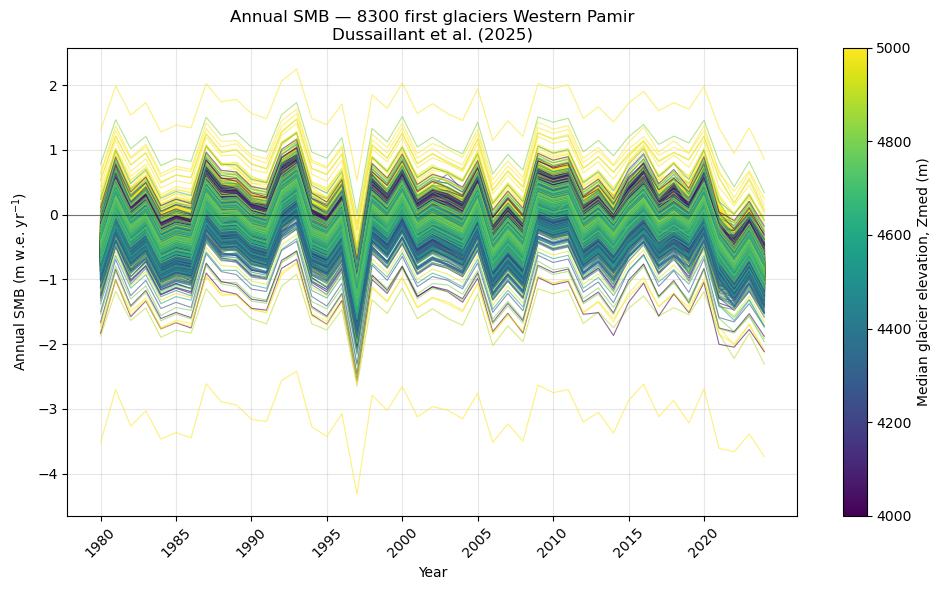

In [44]:
# ============================================================
# 1. PARAMÈTRES
# ============================================================

n_glaciers = 8300

year_start = 1980
year_end = 2024


# ============================================================
# 2. SÉLECTION DES GLACIERS
# ============================================================

df_plot = dus_df_WP.iloc[:n_glaciers].copy()


# ============================================================
# 3. COLONNES ANNÉES
# ============================================================

years = [
    str(y)
    for y in range(year_start, year_end + 1)
    if str(y) in df_plot.columns
]

years_num = np.array([
    int(y) for y in years
])


# ============================================================
# 4. VALEURS DE Zmed
# ============================================================

zmed = df_plot["Zmed"].values


# ============================================================
# 5. NORMALISATION POUR LA COULEUR
#    LIMITES FIXÉES À 3000–5000 m
# ============================================================

norm = mpl.colors.Normalize(
    vmin=4000,
    vmax=5000
)

cmap = plt.cm.viridis


# ============================================================
# 6. FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


# ============================================================
# 7. TRACER UNE COURBE PAR GLACIER
# ============================================================

for i, (_, glacier) in enumerate(
    df_plot.iterrows()
):

    smb = glacier[years].values.astype(float)

    ax.plot(
        years_num,
        smb,
        color=cmap(norm(glacier["Zmed"])),
        lw=0.8,
        alpha=0.6
    )


# ============================================================
# 8. LIGNE SMB = 0
# ============================================================

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ============================================================
# 9. COLORBAR = Zmed
# ============================================================

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax
)

cbar.set_label(
    "Median glacier elevation, Zmed (m)"
)


# ============================================================
# 10. LABELS
# ============================================================

ax.set_xlabel(
    "Year"
)

ax.set_ylabel(
    "Annual SMB (m w.e. yr$^{-1}$)"
)


# ============================================================
# 11. TITRE
# ============================================================

ax.set_title(
    f"Annual SMB — {n_glaciers} first glaciers Western Pamir\n"
    "Dussaillant et al. (2025)"
)


# ============================================================
# 12. AXE X
# ============================================================

ax.set_xticks(
    np.arange(
        year_start,
        year_end + 1,
        5
    )
)

ax.tick_params(
    axis="x",
    labelrotation=45
)


# ============================================================
# 13. GRILLE
# ============================================================

ax.grid(
    alpha=0.3
)


plt.tight_layout()
plt.show()

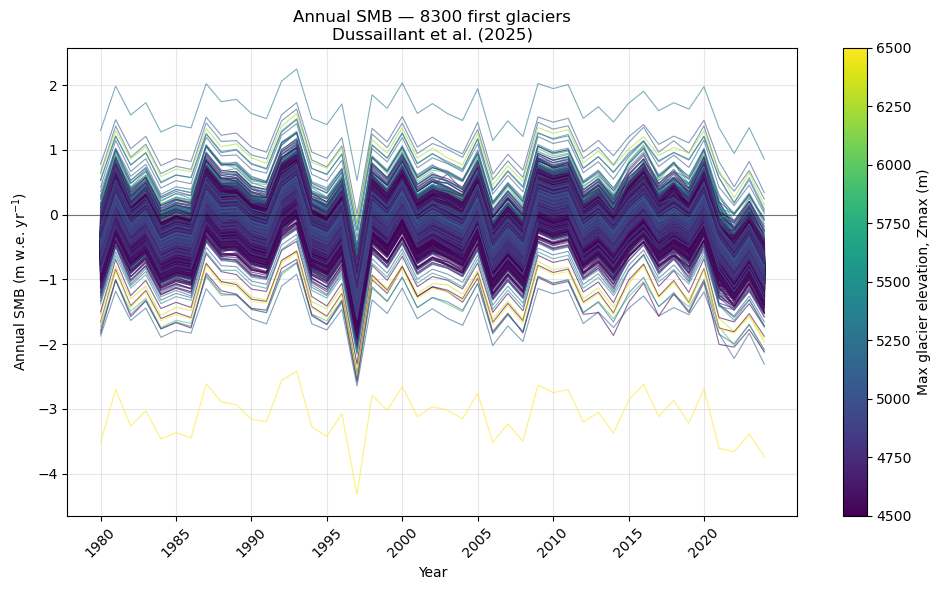

In [45]:
# ============================================================
# 1. PARAMÈTRES
# ============================================================

n_glaciers = 8300

year_start = 1980
year_end = 2024


# ============================================================
# 2. SÉLECTION DES GLACIERS
# ============================================================

df_plot = dus_df_WP.iloc[:n_glaciers].copy()


# ============================================================
# 3. COLONNES ANNÉES
# ============================================================

years = [
    str(y)
    for y in range(year_start, year_end + 1)
    if str(y) in df_plot.columns
]

years_num = np.array([
    int(y) for y in years
])


# ============================================================
# 4. VALEURS DE Zmax
# ============================================================

zmax = df_plot["Zmax"].values


# ============================================================
# 5. NORMALISATION POUR LA COULEUR
#    LIMITES FIXÉES À 3000–5000 m
# ============================================================

norm = mpl.colors.Normalize(
    vmin=4500,
    vmax=6500
)

cmap = plt.cm.viridis


# ============================================================
# 6. FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


# ============================================================
# 7. TRACER UNE COURBE PAR GLACIER
# ============================================================

for i, (_, glacier) in enumerate(
    df_plot.iterrows()
):

    smb = glacier[years].values.astype(float)

    ax.plot(
        years_num,
        smb,
        color=cmap(norm(glacier["Zmax"])),
        lw=0.8,
        alpha=0.6
    )


# ============================================================
# 8. LIGNE SMB = 0
# ============================================================

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ============================================================
# 9. COLORBAR = Zmax
# ============================================================

sm = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax
)

cbar.set_label(
    "Max glacier elevation, Zmax (m)"
)


# ============================================================
# 10. LABELS
# ============================================================

ax.set_xlabel(
    "Year"
)

ax.set_ylabel(
    "Annual SMB (m w.e. yr$^{-1}$)"
)


# ============================================================
# 11. TITRE
# ============================================================

ax.set_title(
    f"Annual SMB — {n_glaciers} first glaciers\n"
    "Dussaillant et al. (2025)"
)


# ============================================================
# 12. AXE X
# ============================================================

ax.set_xticks(
    np.arange(
        year_start,
        year_end + 1,
        5
    )
)

ax.tick_params(
    axis="x",
    labelrotation=45
)


# ============================================================
# 13. GRILLE
# ============================================================

ax.grid(
    alpha=0.3
)


plt.tight_layout()
plt.show()

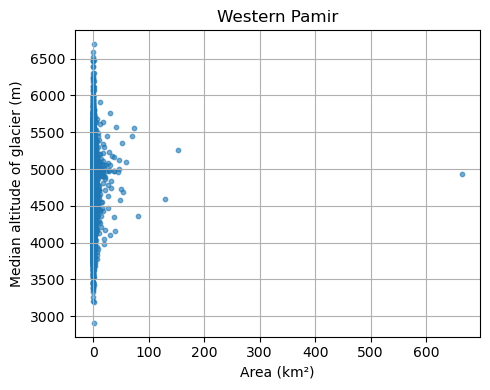

In [46]:
df = dus_df_WP.copy()

plt.figure(figsize=(5,4))

plt.scatter(df["area"], df["Zmed"], s=10, alpha=0.6)

plt.xlabel("Area (km²)")
plt.ylabel("Median altitude of glacier (m)")
plt.title("Western Pamir")
plt.grid()
plt.tight_layout()
plt.show()

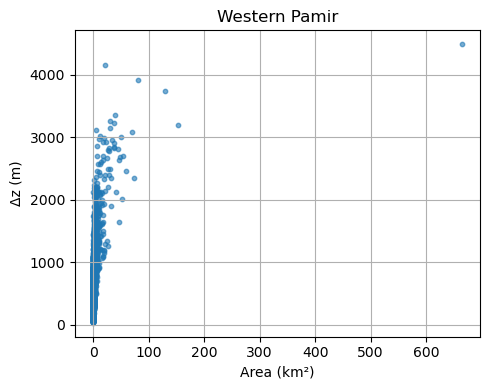

In [47]:
df = dus_df_WP.copy()
df["dz_m"] = df["Zmax"] - df["Zmin"]

plt.figure(figsize=(5,4))

plt.scatter(df["area"], df["dz_m"], s=10, alpha=0.6)

plt.xlabel("Area (km²)")
plt.ylabel("Δz (m)")
plt.title("Western Pamir")
plt.grid()
plt.tight_layout()
plt.show()

#Fedchenko est l'outlier en area !

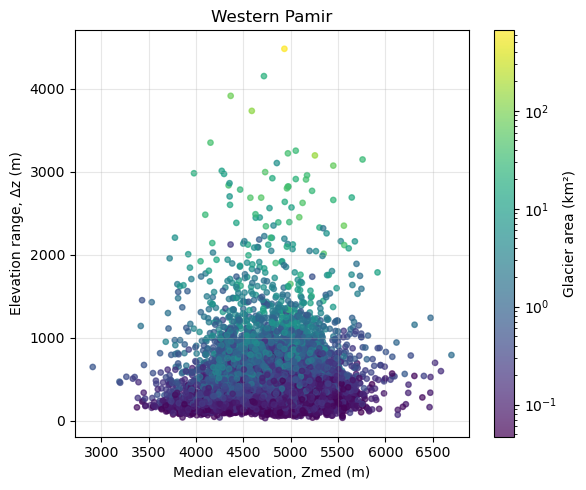

In [48]:
df = dus_df_WP.copy()
df["dz_m"] = df["Zmax"] - df["Zmin"]

plt.figure(figsize=(6, 5))

sc = plt.scatter(
    df["Zmed"],
    df["dz_m"],
    c=df["area"],
    cmap="viridis",
    norm=LogNorm(
        vmin=df["area"].min(),
        vmax=df["area"].max()
    ),
    s=15,
    alpha=0.7
)

plt.xlabel("Median elevation, Zmed (m)")
plt.ylabel("Elevation range, Δz (m)")
plt.title("Western Pamir")

cbar = plt.colorbar(sc)
cbar.set_label("Glacier area (km²)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

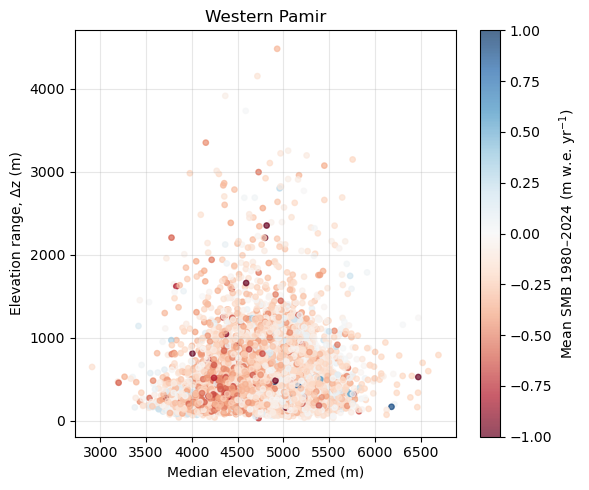

In [69]:
df = dus_df_WP.copy()

# Amplitude altitudinale du glacier
df["dz_m"] = df["Zmax"] - df["Zmin"]

# Colonnes SMB annuelles de 1980 à 2024
years = [str(y) for y in range(1980, 2025)]

# SMB moyen de chaque glacier sur 1980–2024
df["SMB_mean_1980_2024"] = df[years].mean(axis=1, skipna=True)

# Plot
plt.figure(figsize=(6, 5))

sc = plt.scatter(
    df["Zmed"],
    df["dz_m"],
    c=df["SMB_mean_1980_2024"],
    cmap="RdBu",
    vmin=-1,
    vmax=1,
    s=15,
    alpha=0.7
)

# Axes
plt.xlabel("Median elevation, Zmed (m)")
plt.ylabel("Elevation range, Δz (m)")
plt.title("Western Pamir")

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label("Mean SMB 1980–2024 (m w.e. yr$^{-1}$)")

# Grille
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### SMB Dussaillant integrated at subregion scale (glacier area waighting)

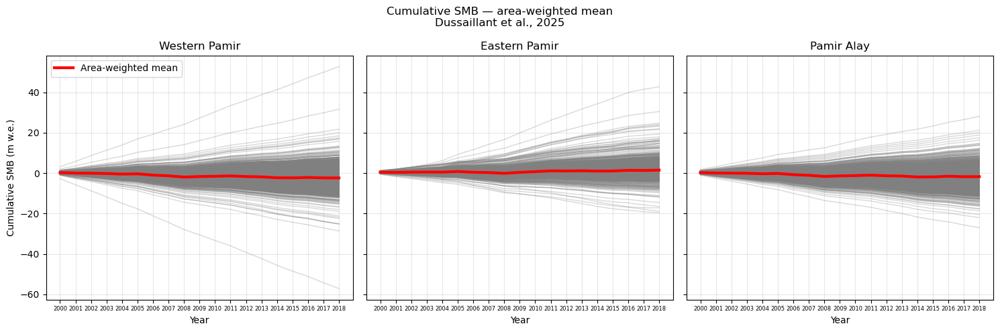

In [70]:
# eq 13 - Dussaillant 2025 : « The region-specific calibrated annual mass change time series (i.e., grid cell or glacier region) 
# Bcal at year Y and in region R is calculated as the area-weighted mean of the individual 
#calibrated annual mass balance time series of the sample of observed glaciers belonging to region R »


dfs = [dus_df_WP, dus_df_EP, dus_df_PA]
titles = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']

yrs = [str(y) for y in range(2000, 2019)]

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

for ax, df, title in zip(axes, dfs, titles):

    # SMB cumulatif pour chaque glacier
    cum_smb = df[yrs].cumsum(axis=1)

    # -----------------------------------------
    # Moyenne pondérée par la surface du glacier
    # -----------------------------------------
    weighted_mean_cum = (
        cum_smb.mul(df["area"], axis=0).sum(axis=0)
        / df["area"].sum()
    )

    # Toutes les courbes individuelles
    ax.plot(
        yrs,
        cum_smb.T,
        color='gray',
        alpha=0.3,
        lw=1
    )

    # Moyenne pondérée par la surface
    ax.plot(
        yrs,
        weighted_mean_cum,
        color='red',
        lw=3,
        label='Area-weighted mean'
    )

    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.tick_params(axis='x', labelsize=6)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Cumulative SMB (m w.e.)')
axes[0].legend()

plt.suptitle(
    "Cumulative SMB — area-weighted mean\nDussaillant et al., 2025"
)

plt.tight_layout()
plt.show()

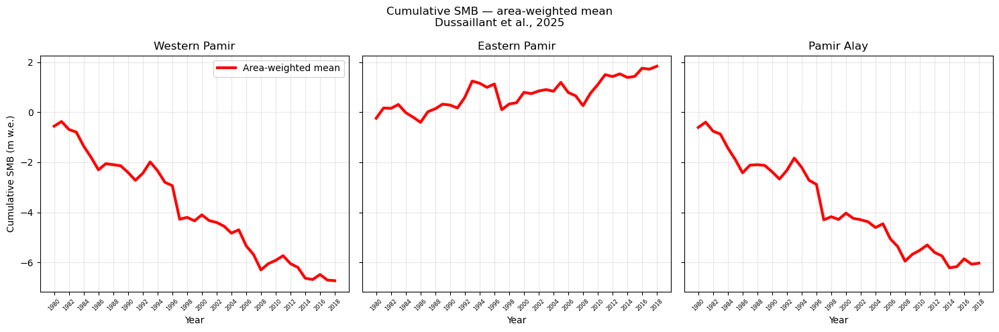

In [71]:
dfs = [dus_df_WP, dus_df_EP, dus_df_PA]
titles = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']

yrs = [str(y) for y in range(1980, 2019)]

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

for ax, df, title in zip(axes, dfs, titles):

    # SMB cumulatif pour chaque glacier
    cum_smb = df[yrs].cumsum(axis=1)

    # -----------------------------------------
    # Moyenne pondérée par la surface du glacier
    # -----------------------------------------
    weighted_mean_cum = (
        cum_smb.mul(df["area"], axis=0).sum(axis=0)
        / df["area"].sum()
    )

    # Moyenne pondérée par la surface
    ax.plot(
        yrs,
        weighted_mean_cum,
        color='red',
        lw=3,
        label='Area-weighted mean'
    )

    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.tick_params(axis='x', labelsize=6)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Cumulative SMB (m w.e.)')
axes[0].legend()

plt.suptitle(
    "Cumulative SMB — area-weighted mean\nDussaillant et al., 2025"
)

for ax in axes:
    ax.set_xticks(yrs[::2])
    ax.tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

## 5. Comparaison MAR - Dussaillant et al. (2025)

### Hypsometry

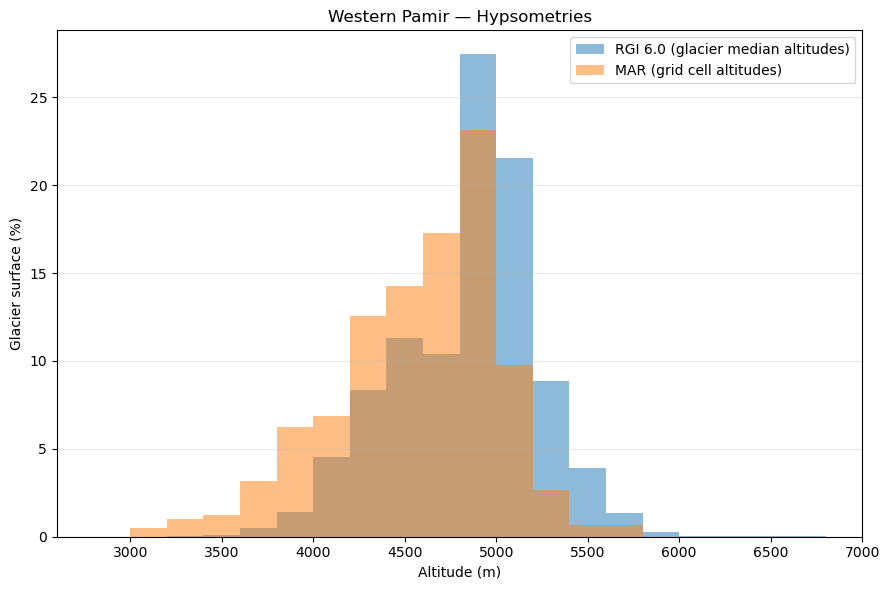

Surface glaciaire totale RGI : 8238.19 km²
Surface glaciaire totale MAR : 7553.20 km²
Somme RGI : 100.00 %
Somme MAR : 100.00 %


In [70]:
# HYPSOMETRIE COMPAREE RGI 6.0 et MAR - Western Pamir

dz = 200
region_value = 6       # Western Pamir
cell_area = 7 * 7      # km²
df = dus_df_WP.copy()


# ============================================================
# 1. RGI 6.0 — distribution selon Zmed
# ============================================================

#df = dus_df_WP[
#    dus_df_WP["Primary_ID"] == "Western Pamir"
#].copy()

#df = df.rename(columns={"Zmed_x": "Zmed"})

# Garder les glaciers avec données valides
#df = df.dropna(subset=["Zmed", "area"])

# Surface glaciaire totale RGI
total_area_rgi = df["area"].sum()

# ============================================================
# 2. MAR / ICE — distribution selon altitude
# ============================================================

# Altitudes du Western Pamir
altitudes = SH_pamir.where(
    (mask == region_value) &
    (ICE_pamir > 0)
)



# Surface glaciaire par cellule
ice_area = ICE_pamir/100 * cell_area

# Garder uniquement Western Pamir + glace
ice_area = ice_area.where(
    (mask == region_value) &
    (ICE_pamir > 0)
)

# Conversion en tableaux 1D
altitudes_flat = altitudes.values.flatten()
ice_area_flat = ice_area.values.flatten()

# Retirer les NaN
valid = (
    np.isfinite(altitudes_flat) &
    np.isfinite(ice_area_flat)
)

altitudes_flat = altitudes_flat[valid]
ice_area_flat = ice_area_flat[valid]

# ============================================================
# 3. Classes d'altitude communes aux deux méthodes
# ============================================================

zmin = np.floor(
    min(df["Zmed"].min(), altitudes_flat.min()) / dz
) * dz

zmax = np.ceil(
    max(df["Zmed"].max(), altitudes_flat.max()) / dz
) * dz

bins = np.arange(zmin, zmax + dz, dz)

z_center = (bins[:-1] + bins[1:]) / 2


# ============================================================
# 4. RGI — surface par classe de Zmed
# ============================================================

area_rgi_by_bin, _ = np.histogram(
    df["Zmed"],
    bins=bins,
    weights=df["area"]
)

percentage_rgi = (
    area_rgi_by_bin /
    total_area_rgi
) * 100


# ============================================================
# 5. MAR / ICE — surface par classe d'altitude
# ============================================================

area_mar_by_bin, _ = np.histogram(
    altitudes_flat,
    bins=bins,
    weights=ice_area_flat
)

total_ice_area = area_mar_by_bin.sum()

percentage_mar = (
    area_mar_by_bin /
    total_ice_area
) * 100


# ============================================================
# 6. PLOT COMPARATIF
# ============================================================

plt.figure(figsize=(9, 6))

# RGI 6.0
plt.bar(
    z_center,
    percentage_rgi,
    width=dz,
    align="center",
    alpha=0.5,
    label="RGI 6.0 (glacier median altitudes)"
)

# MAR / ICE
plt.bar(
    z_center,
    percentage_mar,
    width=dz,
    align="center",
    alpha=0.5,
    label="MAR (grid cell altitudes)"
)

plt.xlabel("Altitude (m)")
plt.ylabel("Glacier surface (%)")
plt.title("Western Pamir — Hypsometries")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 7. VÉRIFICATIONS
# ============================================================

print(
    f"Surface glaciaire totale RGI : "
    f"{total_area_rgi:.2f} km²"
)

print(
    f"Surface glaciaire totale MAR : "
    f"{total_ice_area:.2f} km²"
)

print(
    f"Somme RGI : "
    f"{percentage_rgi.sum():.2f} %"
)

print(
    f"Somme MAR : "
    f"{percentage_mar.sum():.2f} %"
)


hypsometry_rgi_WP = pd.DataFrame({
    "altitude_m": z_center,
    "percentage_rgi": percentage_rgi
})

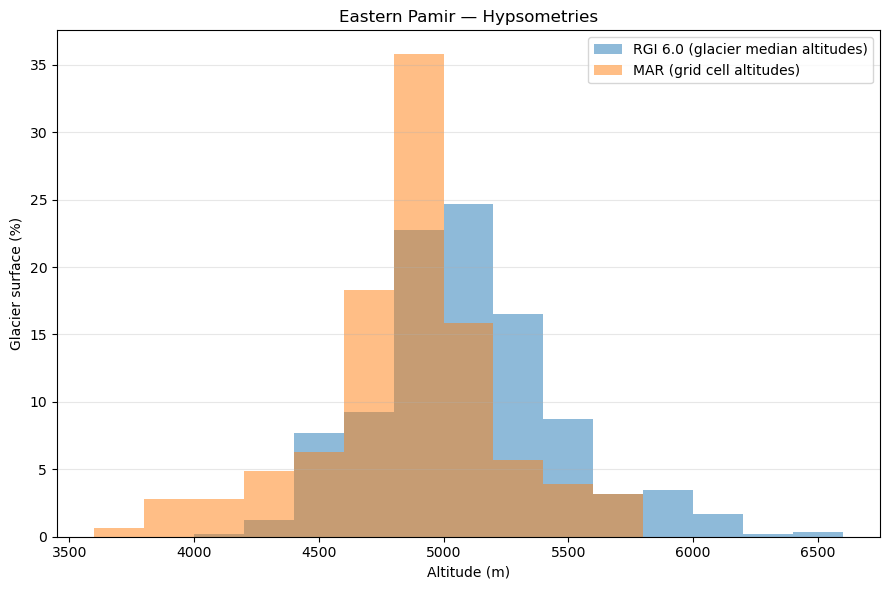

Surface glaciaire totale RGI : 1995.41 km²
Surface glaciaire totale MAR : 1070.30 km²
Somme RGI : 100.00 %
Somme MAR : 100.00 %


In [71]:
# HYPSOMETRIE COMPAREE RGI 6.0 et MAR - EASTERN Pamir

dz = 200
region_value = 7       # Eastern Pamir
cell_area = 7 * 7      # km²

# ============================================================
# 1. RGI 6.0 — distribution selon Zmed
# ============================================================

df = dus_df_EP.copy()
#df = df.rename(columns={"Zmed_x": "Zmed"})


# Surface glaciaire totale RGI
total_area_rgi = df["area"].sum()

# ============================================================
# 2. MAR / ICE — distribution selon altitude
# ============================================================

# Altitudes du Western Pamir
altitudes = SH_pamir.where(
    (mask == region_value) &
    (ICE_pamir > 0)
)



# Surface glaciaire par cellule
ice_area = ICE_pamir/100 * cell_area

# Garder uniquement Western Pamir + glace
ice_area = ice_area.where(
    (mask == region_value) &
    (ICE_pamir > 0)
)

# Conversion en tableaux 1D
altitudes_flat = altitudes.values.flatten()
ice_area_flat = ice_area.values.flatten()

# Retirer les NaN
valid = (
    np.isfinite(altitudes_flat) &
    np.isfinite(ice_area_flat)
)

altitudes_flat = altitudes_flat[valid]
ice_area_flat = ice_area_flat[valid]

# ============================================================
# 3. Classes d'altitude communes aux deux méthodes
# ============================================================

zmin = np.floor(
    min(df["Zmed"].min(), altitudes_flat.min()) / dz
) * dz

zmax = np.ceil(
    max(df["Zmed"].max(), altitudes_flat.max()) / dz
) * dz

bins = np.arange(zmin, zmax + dz, dz)

z_center = (bins[:-1] + bins[1:]) / 2


# ============================================================
# 4. RGI — surface par classe de Zmed
# ============================================================

area_rgi_by_bin, _ = np.histogram(
    df["Zmed"],
    bins=bins,
    weights=df["area"]
)

percentage_rgi = (
    area_rgi_by_bin /
    total_area_rgi
) * 100


# ============================================================
# 5. MAR / ICE — surface par classe d'altitude
# ============================================================

area_mar_by_bin, _ = np.histogram(
    altitudes_flat,
    bins=bins,
    weights=ice_area_flat
)

total_ice_area = area_mar_by_bin.sum()

percentage_mar = (
    area_mar_by_bin /
    total_ice_area
) * 100


# ============================================================
# 6. PLOT COMPARATIF
# ============================================================

plt.figure(figsize=(9, 6))

# RGI 6.0
plt.bar(
    z_center,
    percentage_rgi,
    width=dz,
    align="center",
    alpha=0.5,
    label="RGI 6.0 (glacier median altitudes)"
)

# MAR / ICE
plt.bar(
    z_center,
    percentage_mar,
    width=dz,
    align="center",
    alpha=0.5,
    label="MAR (grid cell altitudes)"
)

plt.xlabel("Altitude (m)")
plt.ylabel("Glacier surface (%)")
plt.title("Eastern Pamir — Hypsometries")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 7. VÉRIFICATIONS
# ============================================================

print(
    f"Surface glaciaire totale RGI : "
    f"{total_area_rgi:.2f} km²"
)

print(
    f"Surface glaciaire totale MAR : "
    f"{total_ice_area:.2f} km²"
)

print(
    f"Somme RGI : "
    f"{percentage_rgi.sum():.2f} %"
)

print(
    f"Somme MAR : "
    f"{percentage_mar.sum():.2f} %"
)


hypsometry_rgi_EP = pd.DataFrame({
    "altitude_m": z_center,
    "percentage_rgi": percentage_rgi
})

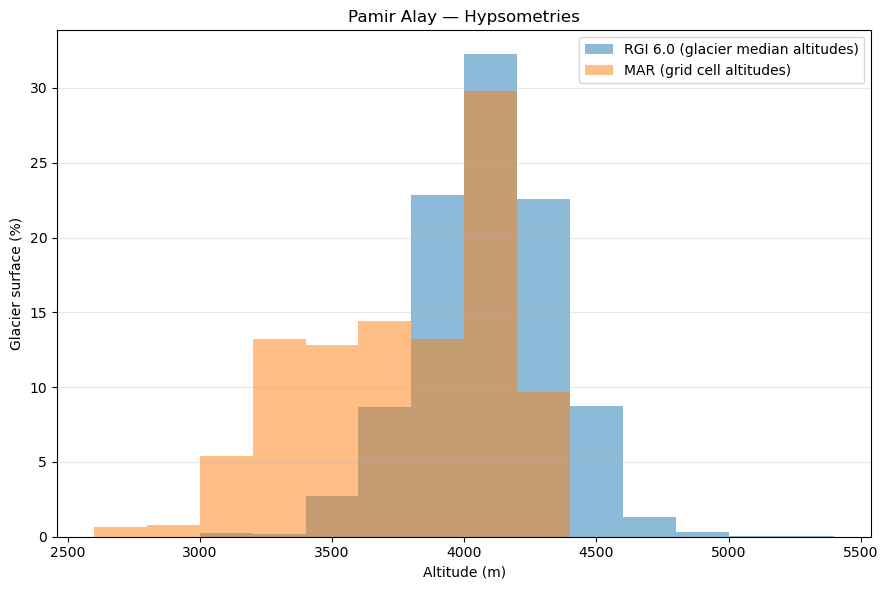

Surface glaciaire totale RGI : 1846.04 km²
Surface glaciaire totale MAR : 731.04 km²
Somme RGI : 100.00 %
Somme MAR : 100.00 %


In [72]:
# HYPSOMETRIE COMPAREE RGI 6.0 et MAR - Pamir ALAY

dz = 200
region_value = 5       # Pamir Alay
cell_area = 7 * 7      # km²
df = dus_df_PA.copy()

# ============================================================
# 1. RGI 6.0 — distribution selon Zmed
# ============================================================
#df = df.rename(columns={"Zmed_x": "Zmed"})

# Surface glaciaire totale RGI
total_area_rgi = df["area"].sum()

# ============================================================
# 2. MAR / ICE — distribution selon altitude
# ============================================================

# Altitudes du Western Pamir
altitudes = SH_pamir.where(
    (mask == region_value) &
    (ICE_pamir > 0)
)

# Surface glaciaire par cellule
ice_area = ICE_pamir/100 * cell_area

# Garder uniquement Western Pamir + glace
ice_area = ice_area.where(
    (mask == region_value) &
    (ICE_pamir > 0)
)

# Conversion en tableaux 1D
altitudes_flat = altitudes.values.flatten()
ice_area_flat = ice_area.values.flatten()

# Retirer les NaN
valid = (
    np.isfinite(altitudes_flat) &
    np.isfinite(ice_area_flat)
)

altitudes_flat = altitudes_flat[valid]
ice_area_flat = ice_area_flat[valid]

# ============================================================
# 3. Classes d'altitude communes aux deux méthodes
# ============================================================

zmin = np.floor(
    min(df["Zmed"].min(), altitudes_flat.min()) / dz
) * dz

zmax = np.ceil(
    max(df["Zmed"].max(), altitudes_flat.max()) / dz
) * dz

bins = np.arange(zmin, zmax + dz, dz)

z_center = (bins[:-1] + bins[1:]) / 2


# ============================================================
# 4. RGI — surface par classe de Zmed
# ============================================================

area_rgi_by_bin, _ = np.histogram(
    df["Zmed"],
    bins=bins,
    weights=df["area"]
)

percentage_rgi = (
    area_rgi_by_bin /
    total_area_rgi
) * 100


# ============================================================
# 5. MAR / ICE — surface par classe d'altitude
# ============================================================

area_mar_by_bin, _ = np.histogram(
    altitudes_flat,
    bins=bins,
    weights=ice_area_flat
)

total_ice_area = area_mar_by_bin.sum()

percentage_mar = (
    area_mar_by_bin /
    total_ice_area
) * 100


# ============================================================
# 6. PLOT COMPARATIF
# ============================================================

plt.figure(figsize=(9, 6))

# RGI 6.0
plt.bar(
    z_center,
    percentage_rgi,
    width=dz,
    align="center",
    alpha=0.5,
    label="RGI 6.0 (glacier median altitudes)"
)

# MAR / ICE
plt.bar(
    z_center,
    percentage_mar,
    width=dz,
    align="center",
    alpha=0.5,
    label="MAR (grid cell altitudes)"
)

plt.xlabel("Altitude (m)")
plt.ylabel("Glacier surface (%)")
plt.title("Pamir Alay — Hypsometries")

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 7. VÉRIFICATIONS
# ============================================================

print(
    f"Surface glaciaire totale RGI : "
    f"{total_area_rgi:.2f} km²"
)

print(
    f"Surface glaciaire totale MAR : "
    f"{total_ice_area:.2f} km²"
)

print(
    f"Somme RGI : "
    f"{percentage_rgi.sum():.2f} %"
)

print(
    f"Somme MAR : "
    f"{percentage_mar.sum():.2f} %"
)

hypsometry_rgi_PA = pd.DataFrame({
    "altitude_m": z_center,
    "percentage_rgi": percentage_rgi
})

### Projection MAR sur l'hypsometrie RGI 6.0

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


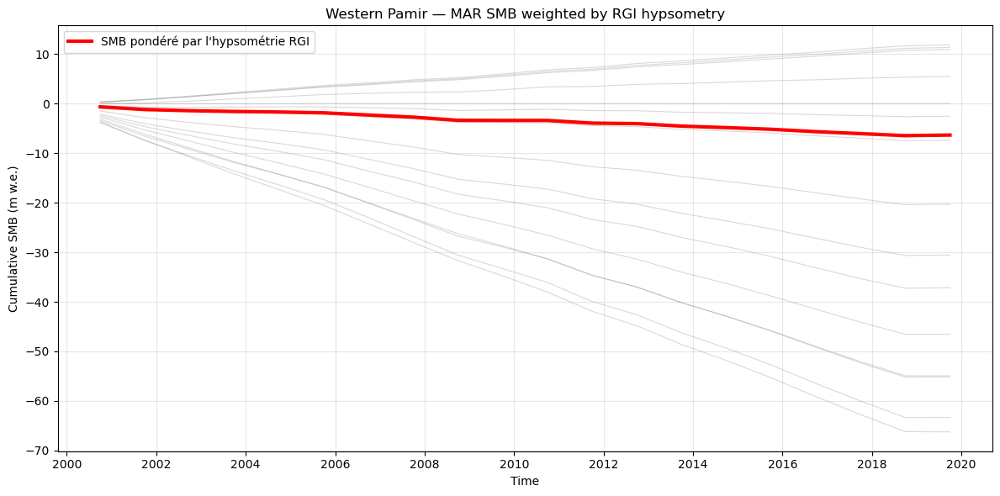

In [75]:
# ============================================================
# 1. MAR : SMB annuel puis cumulatif
# ============================================================

yr_start = '2000-01-16T12:00:00.000000000'
yr_stop  = '2018-12-16T12:00:00.000000000'

da = (
    ds_SMB_WP
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="A-SEP")
    .sum()
)

cum_smb = da.cumsum(dim="time")


# ============================================================
# 2. Empilement spatial
# ============================================================

cum_smb_points = cum_smb.stack(points=("Y", "X"))

elevation = SH_pamir.stack(points=("Y", "X"))


# ============================================================
# 3. Garder uniquement les pixels glaciers
#    ICE_pamir sert uniquement de masque, PAS de poids
# ============================================================

valid_glacier = (
    (ICE_pamir > 0) &
    np.isfinite(SH_pamir)
)

valid_glacier = valid_glacier.stack(points=("Y", "X"))

cum_smb_points = cum_smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

hyps_rgi = hypsometry_rgi_WP.copy()

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values

dz = 200


# ============================================================
# 5. Définir les mêmes classes de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)


# ============================================================
# 6. Attribuer chaque pixel MAR à une classe d'altitude
# ============================================================

elevation_values = elevation.values

class_index = np.digitize(
    elevation_values,
    bins
) - 1


valid_class = (
    (class_index >= 0) &
    (class_index < len(bins) - 1)
)


# ============================================================
# 7. Calculer le SMB MAR moyen dans chaque classe de 200 m
# ============================================================

smb_by_altitude = []

for i in range(len(bins) - 1):

    # Pixels appartenant à la classe i
    pixel_class = class_index == i

    if not np.any(pixel_class):
        smb_by_altitude.append(
            np.full(cum_smb_points.time.size, np.nan)
        )
        continue

    # Sélection des pixels
    smb_class = cum_smb_points.isel(
        points=np.where(pixel_class)[0]
    )

    # Moyenne spatiale simple dans la classe
    smb_mean_class = smb_class.mean(
        dim="points",
        skipna=True
    )

    smb_by_altitude.append(
        smb_mean_class.values
    )


smb_by_altitude = np.array(smb_by_altitude)


# ============================================================
# 8. Centres des classes d'altitude
# ============================================================

z_center = (bins[:-1] + bins[1:]) / 2


# ============================================================
# 9. Associer la distribution RGI aux mêmes classes
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(altitude_rgi[idx] - z) < dz / 2:
        percentage_rgi_aligned[i] = percentage_rgi[idx]


# ============================================================
# 10. Calcul du SMB régional pondéré par l'hypsométrie RGI
# ============================================================

weighted_smb = []

for t in range(cum_smb_points.time.size):

    smb_t = smb_by_altitude[:, t]

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(percentage_rgi_aligned)
    )

    weighted_mean = (
        np.sum(
            smb_t[valid] *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb.append(weighted_mean)


weighted_smb = np.array(weighted_smb)


# ============================================================
# 11. Plot
# ============================================================

years = cum_smb_points.time.values

plt.figure(figsize=(12, 6))

# SMB de chaque classe d'altitude
for i in range(len(z_center)):

    if np.isfinite(
        smb_by_altitude[i]
    ).any():

        plt.plot(
            years,
            smb_by_altitude[i],
            color="gray",
            alpha=0.3,
            linewidth=0.8
        )


# SMB régional pondéré par RGI
plt.plot(
    years,
    weighted_smb,
    color="red",
    linewidth=3,
    label="SMB pondéré par l'hypsométrie RGI"
)

plt.xlabel("Time")
plt.ylabel("Cumulative SMB (m w.e.)")

plt.title(
    "Western Pamir — MAR SMB weighted by RGI hypsometry"
)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Projection MAR (ice-weighted) sur l'hypsometrie RGI 6.0

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


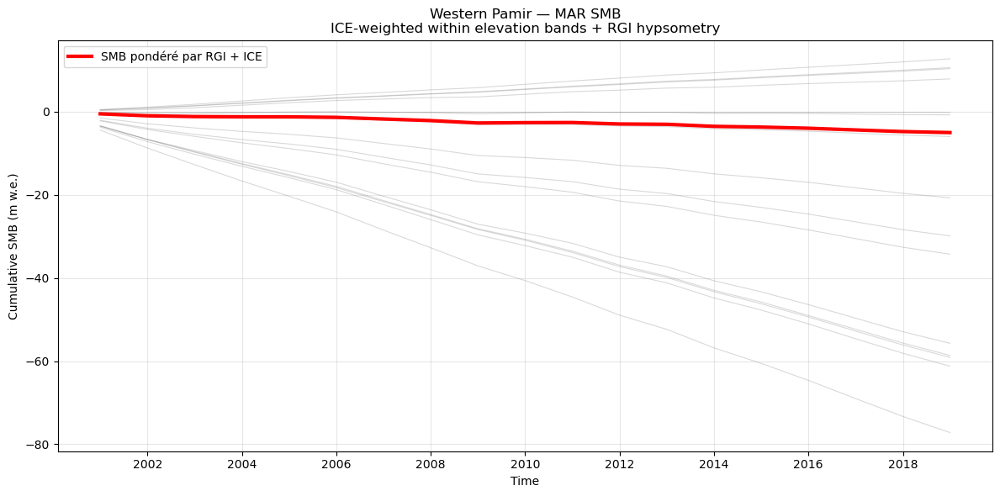

In [76]:
## WESTERN PAMIR


# ============================================================
# 1. MAR : SMB annuel puis cumulatif
# ============================================================

yr_start = '2000-01-16T12:00:00.000000000'
yr_stop  = '2018-12-16T12:00:00.000000000'

da = (
    ds_SMB_WP
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="1Y")
    .sum()
)

cum_smb = da.cumsum(dim="time")


# ============================================================
# 2. Empilement spatial
# ============================================================

cum_smb_points = cum_smb.stack(points=("Y", "X"))

elevation = SH_pamir.stack(points=("Y", "X"))

ice = ICE_pamir.stack(points=("Y", "X"))


# ============================================================
# 3. Garder uniquement les pixels contenant de la glace
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation)
)

cum_smb_points = cum_smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)

ice = ice.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

hyps_rgi = hypsometry_rgi_WP.copy()

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values

dz = 200


# ============================================================
# 5. Définir les classes de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (bins[:-1] + bins[1:]) / 2


# ============================================================
# 6. Attribuer chaque pixel MAR à une classe d'altitude
# ============================================================

elevation_values = elevation.values

class_index = np.digitize(
    elevation_values,
    bins
) - 1


# ============================================================
# 7. SMB MAR MOYEN PONDÉRÉ PAR ICE
# ============================================================

smb_by_altitude = []

for i in range(len(bins) - 1):

    # Pixels appartenant à la classe d'altitude
    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(
                cum_smb_points.time.size,
                np.nan
            )
        )

        continue


    # --------------------------------------------------------
    # Sélection des pixels de cette tranche
    # --------------------------------------------------------

    smb_class = cum_smb_points.isel(
        points=np.where(pixel_class)[0]
    )

    ice_class = ice.isel(
        points=np.where(pixel_class)[0]
    )


    # --------------------------------------------------------
    # Moyenne pondérée par la fraction de glace
    # --------------------------------------------------------

    weighted_smb_class = (
        (smb_class * ice_class).sum(
            dim="points",
            skipna=True
        )
        /
        ice_class.sum(
            dim="points",
            skipna=True
        )
    )


    smb_by_altitude.append(
        weighted_smb_class.values
    )


smb_by_altitude = np.array(
    smb_by_altitude
)


# ============================================================
# 8. Associer la distribution RGI aux mêmes classes
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(
        altitude_rgi[idx] - z
    ) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB régional pondéré par l'hypsométrie RGI
# ============================================================

weighted_smb = []

for t in range(
    cum_smb_points.time.size
):

    smb_t = smb_by_altitude[:, t]

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(
            percentage_rgi_aligned
        )
    )

    weighted_mean = (
        np.sum(
            smb_t[valid] *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb.append(
        weighted_mean
    )


weighted_smb = np.array(
    weighted_smb
)


# ============================================================
# 10. Plot
# ============================================================

years = cum_smb_points.time.values

plt.figure(figsize=(12, 6))


# ------------------------------------------------------------
# SMB de chaque classe d'altitude
# (déjà pondéré par ICE)
# ------------------------------------------------------------

for i in range(
    len(z_center)
):

    if np.isfinite(
        smb_by_altitude[i]
    ).any():

        plt.plot(
            years,
            smb_by_altitude[i],
            color="gray",
            alpha=0.3,
            linewidth=0.8
        )


# ------------------------------------------------------------
# SMB régional pondéré par RGI
# ------------------------------------------------------------

plt.plot(
    years,
    weighted_smb,
    color="red",
    linewidth=3,
    label="SMB pondéré par RGI + ICE"
)


plt.xlabel("Time")

plt.ylabel(
    "Cumulative SMB (m w.e.)"
)

plt.title(
    "Western Pamir — MAR SMB\n"
    "ICE-weighted within elevation bands + RGI hypsometry"
)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

## Comparaison des CUMULS SMB

### Comparaison MAR vs Dussaillant WESTERN Pamir Avec et Sans ice weighting pour MAR 

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


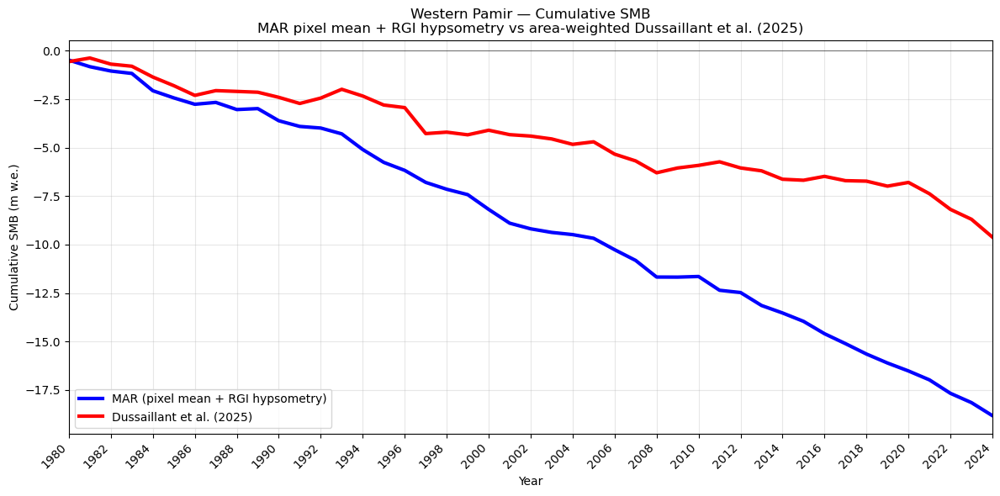

In [77]:
# ============================================================
# 0. INPUTS
# ============================================================

region_name = "Western Pamir"

yr_start = '1980-01-16T12:00:00.000000000'
yr_stop  = '2024-12-16T12:00:00.000000000'

da = ds_SMB_WP
df = dus_df_WP.copy()
hyps_rgi = hypsometry_rgi_WP.copy()


# ============================================================
# 1. MAR : SMB annuel puis cumulatif
# ============================================================

da = (
    da
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="A-SEP")
    .sum()
)

cum_smb = da.cumsum(dim="time")


# ============================================================
# 2. Empilement spatial
# ============================================================

cum_smb_points = cum_smb.stack(points=("Y", "X"))

elevation = (
    SH_pamir
    .where(mask_smb == region_id[region_name])
    .stack(points=("Y", "X"))
)

ice = (
    ICE_pamir
    .where(mask_smb == region_id[region_name])
    .stack(points=("Y", "X"))
)


# ============================================================
# 3. Garder uniquement les pixels glaciers de la région
#
#    ICE sert uniquement à identifier les pixels glaciers.
#    Il n'est PAS utilisé comme poids dans le calcul du SMB.
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation) &
    np.isfinite(ice)
)

cum_smb_points = cum_smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)

ice = ice.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values

dz = 200


# ============================================================
# 5. Classes d'altitude de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (
    bins[:-1] + bins[1:]
) / 2


# ============================================================
# 6. Assigner chaque pixel MAR à une classe d'altitude
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR moyen dans chaque classe d'altitude
#
#    PAS DE PONDÉRATION PAR ICE
#
#    Chaque pixel glacier compte de manière égale.
#
#    SMB_class =
#        SUM(SMB_i)
#        ----------
#        N_pixels
#
# ============================================================

smb_by_altitude = []

for i in range(len(z_center)):

    # Pixels appartenant à la classe d'altitude
    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(
                cum_smb_points.time.size,
                np.nan
            )
        )

        continue


    # --------------------------------------------------------
    # Sélection des pixels
    # --------------------------------------------------------

    indices = np.where(pixel_class)[0]

    smb_class = cum_smb_points.isel(
        points=indices
    )


    # --------------------------------------------------------
    # Moyenne SIMPLE des pixels
    # --------------------------------------------------------
    #
    # Chaque pixel a le même poids.
    #
    # ICE n'intervient PAS ici.
    #
    # --------------------------------------------------------

    smb_mean_class = smb_class.mean(
        dim="points",
        skipna=True
    )


    smb_by_altitude.append(
        smb_mean_class.values
    )


smb_by_altitude = np.array(
    smb_by_altitude
)


# ============================================================
# 8. Aligner l'hypsométrie RGI avec les classes MAR
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(
        altitude_rgi[idx] - z
    ) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB régional MAR
#    pondéré par l'hypsométrie RGI
# ============================================================

weighted_smb_mar = []

for t in range(
    cum_smb_points.time.size
):

    smb_t = smb_by_altitude[:, t]

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(
            percentage_rgi_aligned
        )
    )

    weighted_mean = (
        np.sum(
            smb_t[valid]
            *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb_mar.append(
        weighted_mean
    )


weighted_smb_mar = np.array(
    weighted_smb_mar
)


# ============================================================
# 10. Années MAR
# ============================================================

years_mar = [
    str(pd.Timestamp(t).year)
    for t in cum_smb_points.time.values
]


# ============================================================
# 11. DUSSAILLANT
# ============================================================

year_1 = pd.Timestamp(yr_start).year
year_2 = pd.Timestamp(yr_stop).year + 1

yrs = [
    str(y)
    for y in range(year_1, year_2)
]


# SMB cumulatif de chaque glacier
cum_smb_dus = df[yrs].cumsum(
    axis=1
)


# Moyenne pondérée par la surface des glaciers
weighted_mean_dus = (
    cum_smb_dus.mul(
        df["area"],
        axis=0
    ).sum(axis=0)
    /
    df["area"].sum()
)


# ============================================================
# 12. Comparaison MAR vs Dussaillant
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))


# ------------------------------------------------------------
# Conversion des années en numériques
# ------------------------------------------------------------

years_mar_num = np.array([
    int(y) for y in years_mar
])

years_dus_num = np.array([
    int(y) for y in yrs
])


# ------------------------------------------------------------
# MAR + hypsométrie RGI
# ------------------------------------------------------------

ax.plot(
    years_mar_num,
    weighted_smb_mar,
    color="blue",
    lw=3,
    label="MAR (pixel mean + RGI hypsometry)"
)


# ------------------------------------------------------------
# Dussaillant et al. (2025)
# ------------------------------------------------------------

ax.plot(
    years_dus_num,
    weighted_mean_dus.values,
    color="red",
    lw=3,
    label="Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Ligne SMB = 0
# ------------------------------------------------------------

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_xlabel("Year")

ax.set_ylabel(
    "Cumulative SMB (m w.e.)"
)


# ------------------------------------------------------------
# Axe X
# ------------------------------------------------------------

years_ticks = np.arange(
    1980,
    2025,
    2
)

ax.set_xticks(years_ticks)

ax.set_xticklabels(
    [str(y) for y in years_ticks],
    rotation=45,
    ha="right"
)


# ------------------------------------------------------------
# Limites X
# ------------------------------------------------------------

ax.set_xlim(
    1980,
    2024
)


# ------------------------------------------------------------
# Titre
# ------------------------------------------------------------

ax.set_title(
    f"{region_name} — Cumulative SMB\n"
    "MAR pixel mean + RGI hypsometry vs "
    "area-weighted Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Grille + légende
# ------------------------------------------------------------

ax.grid(alpha=0.3)

ax.legend()

plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


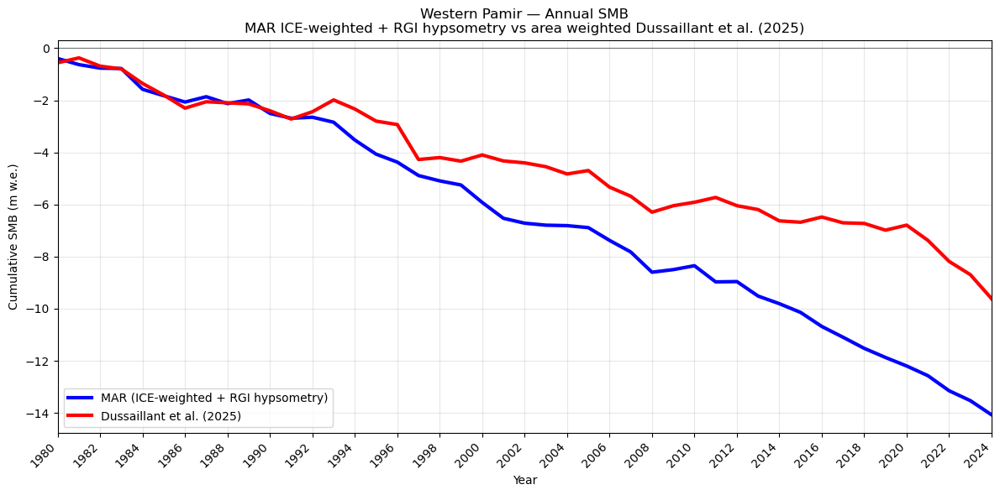

In [78]:
# ============================================================
# 0. INPUTS
# ============================================================

region_name = "Western Pamir"

yr_start = '1980-01-16T12:00:00.000000000'
yr_stop  = '2024-12-16T12:00:00.000000000'

da =  ds_SMB_WP
df = dus_df_WP.copy()
hyps_rgi = hypsometry_rgi_WP.copy()


# ============================================================
# 1. MAR : SMB annuel puis cumulatif
# ============================================================


da = (
    da
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="A-SEP")
    .sum()
)

cum_smb = da.cumsum(dim="time")


# ============================================================
# 2. Empilement spatial
# ============================================================

cum_smb_points = cum_smb.stack(points=("Y", "X"))


elevation = (
    SH_pamir
    .where(mask_smb == region_id[region_name]) # inutile ..
    .stack(points=("Y", "X"))
)

ice = (
    ICE_pamir
    .where(mask_smb == region_id[region_name])
    .stack(points=("Y", "X"))
)

# ============================================================
# 3. Garder uniquement les pixels glaciers
#    ICE_pamir sert maintenant de POIDS
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation) &
    np.isfinite(ice)
)

cum_smb_points = cum_smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)

ice = ice.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

#hyps_rgi = hypsometry_rgi_WP.copy()

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values

dz = 200


# ============================================================
# 5. Classes d'altitude de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (
    bins[:-1] + bins[1:]
) / 2


# ============================================================
# 6. Assigner chaque pixel MAR à une classe d'altitude
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR moyen dans chaque classe d'altitude
#    PONDÉRÉ PAR ICE
# ============================================================

smb_by_altitude = []

for i in range(len(z_center)):

    # Pixels appartenant à la classe d'altitude
    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(
                cum_smb_points.time.size,
                np.nan
            )
        )

        continue


    # --------------------------------------------------------
    # Sélection des pixels
    # --------------------------------------------------------

    indices = np.where(pixel_class)[0]

    smb_class = cum_smb_points.isel(
        points=indices
    )

    ice_class = ice.isel(
        points=indices
    )


    # --------------------------------------------------------
    # Moyenne pondérée par ICE
    # --------------------------------------------------------
    #
    # ICE = fraction de glace dans chaque cellule
    #
    # SMB_class =
    #     SUM(SMB_i * ICE_i)
    #     ------------------
    #          SUM(ICE_i)
    #
    # --------------------------------------------------------

    smb_weighted_class = (
        (smb_class * ice_class).sum(
            dim="points",
            skipna=True
        )
        /
        ice_class.sum(
            dim="points",
            skipna=True
        )
    )


    smb_by_altitude.append(
        smb_weighted_class.values
    )


smb_by_altitude = np.array(
    smb_by_altitude
)


# ============================================================
# 8. Aligner l'hypsométrie RGI avec les classes MAR
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(
        altitude_rgi[idx] - z
    ) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB régional MAR
#    pondéré par l'hypsométrie RGI
# ============================================================

weighted_smb_mar = []

for t in range(
    cum_smb_points.time.size
):

    smb_t = smb_by_altitude[:, t]

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(
            percentage_rgi_aligned
        )
    )

    weighted_mean = (
        np.sum(
            smb_t[valid]
            *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb_mar.append(
        weighted_mean
    )


weighted_smb_mar = np.array(
    weighted_smb_mar
)


# ============================================================
# 10. Années MAR
# ============================================================

years_mar = [
    str(pd.Timestamp(t).year)
    for t in cum_smb_points.time.values
]


# ============================================================
# 11. DUSSAILLANT
# ============================================================

#df = dus_df_WP.copy()

year_1 = pd.Timestamp(yr_start).year
year_2 = pd.Timestamp(yr_stop).year +1

yrs = [
    str(y)
    for y in range(year_1, year_2)
]


# SMB cumulatif de chaque glacier
cum_smb_dus = df[yrs].cumsum(
    axis=1
)


# Moyenne pondérée par la surface des glaciers
weighted_mean_dus = (
    cum_smb_dus.mul(
        df["area"],
        axis=0
    ).sum(axis=0)
    /
    df["area"].sum()
)


# ============================================================
# 12. Comparaison MAR vs Dussaillant
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# ------------------------------------------------------------
# Conversion des années en numériques
# ------------------------------------------------------------

years_mar_num = np.array([
    int(y) for y in years_mar
])

years_dus_num = np.array([
    int(y) for y in yrs
])


# ------------------------------------------------------------
# MAR + ICE + hypsométrie RGI
# ------------------------------------------------------------

ax.plot(
    years_mar_num,
    weighted_smb_mar,
    color="blue",
    lw=3,
    label="MAR (ICE-weighted + RGI hypsometry)"
)


# ------------------------------------------------------------
# Dussaillant et al. (2025)
# ------------------------------------------------------------

ax.plot(
    years_dus_num,
    weighted_mean_dus.values,
    color="red",
    lw=3,
    label="Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Ligne SMB = 0
# ------------------------------------------------------------

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_xlabel("Year")

ax.set_ylabel(
    "Cumulative SMB (m w.e.)"
)


# ------------------------------------------------------------
# Axe X : un label tous les 5 ans
# ------------------------------------------------------------

years_ticks = np.arange(1980, 2025, 2)

ax.set_xticks(years_ticks)

ax.set_xticklabels(
    [str(y) for y in years_ticks],
    rotation=45,
    ha="right"
)


# ------------------------------------------------------------
# Limites X
# ------------------------------------------------------------

ax.set_xlim(
    1980,
    2024
)


# ------------------------------------------------------------
# Titre
# ------------------------------------------------------------

ax.set_title(
    f"{region_name} — Annual SMB\n"
    "MAR ICE-weighted + RGI hypsometry vs "
    "area weighted Dussaillant et al. (2025)"
)



# ------------------------------------------------------------
# Grille + légende
# ------------------------------------------------------------

ax.grid(alpha=0.3)

ax.legend()


plt.tight_layout()
plt.show()
plt.show()

### Comparaison MAR vs Dussaillant Eastern Pamir Avec et Sans ice weighting pour MAR  

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


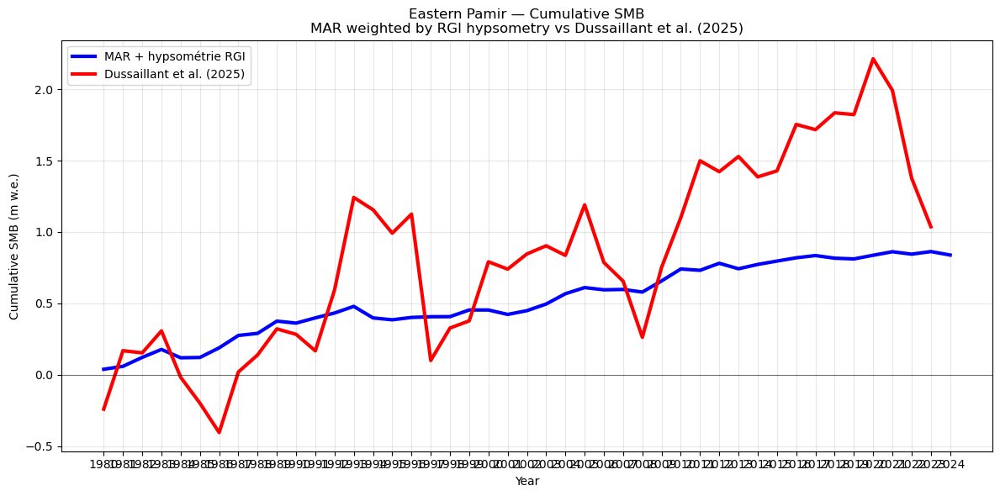

In [79]:
# ============================================================
# 1. MAR : SMB annuel puis cumulatif
# ============================================================

yr_start = '1980-01-16T12:00:00.000000000'
yr_stop  = '2024-12-16T12:00:00.000000000'

da = (
    ds_SMB_EP
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="1Y")
    .sum()
)

cum_smb = da.cumsum(dim="time")


# ============================================================
# 2. Empilement spatial
# ============================================================

cum_smb_points = cum_smb.stack(points=("Y", "X"))

elevation = SH_pamir.stack(points=("Y", "X"))

ice = ICE_pamir.stack(points=("Y", "X"))


# ============================================================
# 3. Garder uniquement les pixels glaciers
#    ICE_pamir = masque uniquement, PAS un poids
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation)
)

cum_smb_points = cum_smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

hyps_rgi = hypsometry_rgi_EP.copy()

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values

dz = 200


# ============================================================
# 5. Classes d'altitude de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (bins[:-1] + bins[1:]) / 2


# ============================================================
# 6. Assigner chaque pixel MAR à une classe d'altitude
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR moyen dans chaque classe d'altitude
# ============================================================

smb_by_altitude = []

for i in range(len(z_center)):

    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(cum_smb_points.time.size, np.nan)
        )

    else:

        smb_class = cum_smb_points.isel(
            points=np.where(pixel_class)[0]
        )

        smb_mean_class = smb_class.mean(
            dim="points",
            skipna=True
        )

        smb_by_altitude.append(
            smb_mean_class.values
        )

smb_by_altitude = np.array(smb_by_altitude)


# ============================================================
# 8. Aligner l'hypsométrie RGI avec les classes MAR
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(altitude_rgi[idx] - z) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB régional MAR pondéré par l'hypsométrie RGI
# ============================================================

weighted_smb_mar = []

for t in range(cum_smb_points.time.size):

    smb_t = smb_by_altitude[:, t]

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(percentage_rgi_aligned)
    )

    weighted_mean = (
        np.sum(
            smb_t[valid] *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb_mar.append(weighted_mean)


weighted_smb_mar = np.array(weighted_smb_mar)


# ============================================================
# 10. Années MAR
# ============================================================

years_mar = [
    str(pd.Timestamp(t).year)
    for t in cum_smb_points.time.values
]


# ============================================================
# 11. DUSSAILLANT — EASTERN PAMIR 
# ============================================================

df = dus_df_EP.copy()

yrs = [str(y) for y in range(1980, 2024)]

# SMB cumulatif de chaque glacier
cum_smb_dus = df[yrs].cumsum(axis=1)

# Moyenne pondérée par la surface des glaciers
weighted_mean_dus = (
    cum_smb_dus.mul(
        df["area"],
        axis=0
    ).sum(axis=0)
    /
    df["area"].sum()
)


# ============================================================
# 12. Comparaison MAR vs Dussaillant 
# ============================================================

plt.figure(figsize=(12, 6))

# ------------------------------------------------------------
# MAR + hypsométrie RGI
# ------------------------------------------------------------

plt.plot(
    years_mar,
    weighted_smb_mar,
    color="blue",
    lw=3,
    label="MAR + hypsométrie RGI"
)


# ------------------------------------------------------------
# Dussaillant et al. (2025)
# ------------------------------------------------------------

plt.plot(
    yrs,
    weighted_mean_dus.values,
    color="red",
    lw=3,
    label="Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Mise en forme
# ------------------------------------------------------------

plt.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)

plt.xlabel("Year")
plt.ylabel("Cumulative SMB (m w.e.)")

plt.title(
    "Eastern Pamir — Cumulative SMB\n"
    "MAR weighted by RGI hypsometry vs Dussaillant et al. (2025)"
)

plt.grid(alpha=0.3)
plt.legend()


plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


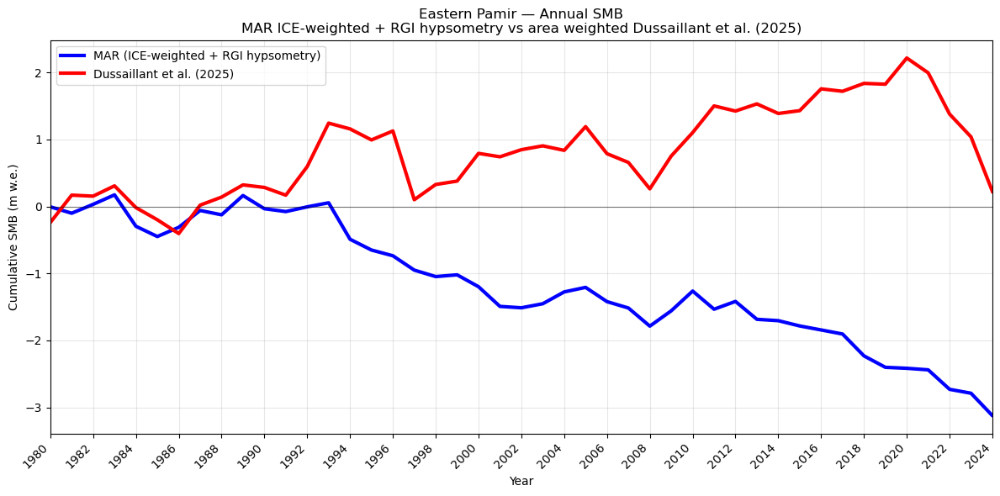

In [80]:
# ============================================================
# 0. INPUTS
# ============================================================

region_name = "Eastern Pamir"

yr_start = '1980-01-16T12:00:00.000000000'
yr_stop  = '2024-12-16T12:00:00.000000000'

da =  ds_SMB_EP
df = dus_df_EP.copy()
hyps_rgi = hypsometry_rgi_EP.copy()


# ============================================================
# 1. MAR : SMB annuel puis cumulatif
# ============================================================


da = (
    da
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="A-SEP")
    .sum()
)

cum_smb = da.cumsum(dim="time")


# ============================================================
# 2. Empilement spatial
# ============================================================

cum_smb_points = cum_smb.stack(points=("Y", "X"))


elevation = (
    SH_pamir
    .where(mask_smb == region_id[region_name]) # inutile ..
    .stack(points=("Y", "X"))
)

ice = (
    ICE_pamir
    .where(mask_smb == region_id[region_name])
    .stack(points=("Y", "X"))
)

# ============================================================
# 3. Garder uniquement les pixels glaciers
#    ICE_pamir sert maintenant de POIDS
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation) &
    np.isfinite(ice)
)

cum_smb_points = cum_smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)

ice = ice.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

#hyps_rgi = hypsometry_rgi_WP.copy()

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values

dz = 200


# ============================================================
# 5. Classes d'altitude de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (
    bins[:-1] + bins[1:]
) / 2


# ============================================================
# 6. Assigner chaque pixel MAR à une classe d'altitude
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR moyen dans chaque classe d'altitude
#    PONDÉRÉ PAR ICE
# ============================================================

smb_by_altitude = []

for i in range(len(z_center)):

    # Pixels appartenant à la classe d'altitude
    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(
                cum_smb_points.time.size,
                np.nan
            )
        )

        continue


    # --------------------------------------------------------
    # Sélection des pixels
    # --------------------------------------------------------

    indices = np.where(pixel_class)[0]

    smb_class = cum_smb_points.isel(
        points=indices
    )

    ice_class = ice.isel(
        points=indices
    )


    # --------------------------------------------------------
    # Moyenne pondérée par ICE
    # --------------------------------------------------------
    #
    # ICE = fraction de glace dans chaque cellule
    #
    # SMB_class =
    #     SUM(SMB_i * ICE_i)
    #     ------------------
    #          SUM(ICE_i)
    #
    # --------------------------------------------------------

    smb_weighted_class = (
        (smb_class * ice_class).sum(
            dim="points",
            skipna=True
        )
        /
        ice_class.sum(
            dim="points",
            skipna=True
        )
    )


    smb_by_altitude.append(
        smb_weighted_class.values
    )


smb_by_altitude = np.array(
    smb_by_altitude
)


# ============================================================
# 8. Aligner l'hypsométrie RGI avec les classes MAR
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(
        altitude_rgi[idx] - z
    ) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB régional MAR
#    pondéré par l'hypsométrie RGI
# ============================================================

weighted_smb_mar = []

for t in range(
    cum_smb_points.time.size
):

    smb_t = smb_by_altitude[:, t]

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(
            percentage_rgi_aligned
        )
    )

    weighted_mean = (
        np.sum(
            smb_t[valid]
            *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb_mar.append(
        weighted_mean
    )


weighted_smb_mar = np.array(
    weighted_smb_mar
)


# ============================================================
# 10. Années MAR
# ============================================================

years_mar = [
    str(pd.Timestamp(t).year)
    for t in cum_smb_points.time.values
]


# ============================================================
# 11. DUSSAILLANT
# ============================================================

#df = dus_df_WP.copy()

year_1 = pd.Timestamp(yr_start).year
year_2 = pd.Timestamp(yr_stop).year +1

yrs = [
    str(y)
    for y in range(year_1, year_2)
]


# SMB cumulatif de chaque glacier
cum_smb_dus = df[yrs].cumsum(
    axis=1
)


# Moyenne pondérée par la surface des glaciers
weighted_mean_dus = (
    cum_smb_dus.mul(
        df["area"],
        axis=0
    ).sum(axis=0)
    /
    df["area"].sum()
)


# ============================================================
# 12. Comparaison MAR vs Dussaillant
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# ------------------------------------------------------------
# Conversion des années en numériques
# ------------------------------------------------------------

years_mar_num = np.array([
    int(y) for y in years_mar
])

years_dus_num = np.array([
    int(y) for y in yrs
])


# ------------------------------------------------------------
# MAR + ICE + hypsométrie RGI
# ------------------------------------------------------------

ax.plot(
    years_mar_num,
    weighted_smb_mar,
    color="blue",
    lw=3,
    label="MAR (ICE-weighted + RGI hypsometry)"
)


# ------------------------------------------------------------
# Dussaillant et al. (2025)
# ------------------------------------------------------------

ax.plot(
    years_dus_num,
    weighted_mean_dus.values,
    color="red",
    lw=3,
    label="Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Ligne SMB = 0
# ------------------------------------------------------------

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_xlabel("Year")

ax.set_ylabel(
    "Cumulative SMB (m w.e.)"
)


# ------------------------------------------------------------
# Axe X : un label tous les 5 ans
# ------------------------------------------------------------

years_ticks = np.arange(1980, 2025, 2)

ax.set_xticks(years_ticks)

ax.set_xticklabels(
    [str(y) for y in years_ticks],
    rotation=45,
    ha="right"
)


# ------------------------------------------------------------
# Limites X
# ------------------------------------------------------------

ax.set_xlim(
    1980,
    2024
)


# ------------------------------------------------------------
# Titre
# ------------------------------------------------------------

ax.set_title(
    f"{region_name} — Annual SMB\n"
    "MAR ICE-weighted + RGI hypsometry vs "
    "area weighted Dussaillant et al. (2025)"
)



# ------------------------------------------------------------
# Grille + légende
# ------------------------------------------------------------

ax.grid(alpha=0.3)

ax.legend()


plt.tight_layout()
plt.show()
plt.show()

### Comparaison MAR vs Dussaillant Pamir Alay Avec et Sans ice weighting pour MAR  

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


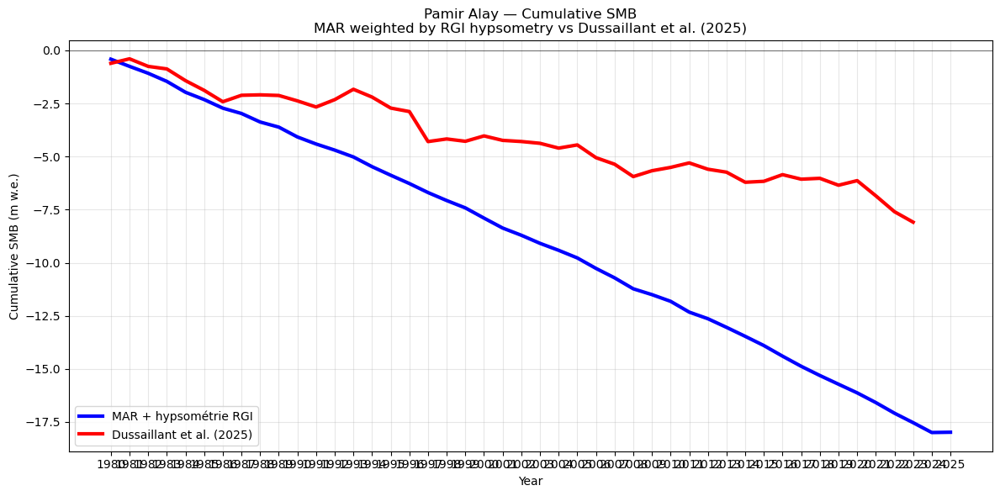

In [81]:
# ============================================================
# 1. MAR : SMB annuel puis cumulatif
# ============================================================

yr_start = '1980-01-16T12:00:00.000000000'
yr_stop  = '2024-12-16T12:00:00.000000000'

da = (
    ds_SMB_PA
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="A-SEP")
    .sum()
)

cum_smb = da.cumsum(dim="time")


# ============================================================
# 2. Empilement spatial
# ============================================================

cum_smb_points = cum_smb.stack(points=("Y", "X"))

elevation = SH_pamir.stack(points=("Y", "X"))

ice = ICE_pamir.stack(points=("Y", "X"))


# ============================================================
# 3. Garder uniquement les pixels glaciers
#    ICE_pamir = masque uniquement, PAS un poids
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation)
)

cum_smb_points = cum_smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

hyps_rgi = hypsometry_rgi_PA.copy()

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values

dz = 200


# ============================================================
# 5. Classes d'altitude de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (bins[:-1] + bins[1:]) / 2


# ============================================================
# 6. Assigner chaque pixel MAR à une classe d'altitude
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR moyen dans chaque classe d'altitude
# ============================================================

smb_by_altitude = []

for i in range(len(z_center)):

    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(cum_smb_points.time.size, np.nan)
        )

    else:

        smb_class = cum_smb_points.isel(
            points=np.where(pixel_class)[0]
        )

        smb_mean_class = smb_class.mean(
            dim="points",
            skipna=True
        )

        smb_by_altitude.append(
            smb_mean_class.values
        )

smb_by_altitude = np.array(smb_by_altitude)


# ============================================================
# 8. Aligner l'hypsométrie RGI avec les classes MAR
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(altitude_rgi[idx] - z) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB régional MAR pondéré par l'hypsométrie RGI
# ============================================================

weighted_smb_mar = []

for t in range(cum_smb_points.time.size):

    smb_t = smb_by_altitude[:, t]

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(percentage_rgi_aligned)
    )

    weighted_mean = (
        np.sum(
            smb_t[valid] *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb_mar.append(weighted_mean)


weighted_smb_mar = np.array(weighted_smb_mar)


# ============================================================
# 10. Années MAR
# ============================================================

years_mar = [
    str(pd.Timestamp(t).year)
    for t in cum_smb_points.time.values
]


# ============================================================
# 11. DUSSAILLANT —  PAMIR ALAY
# ============================================================

df = dus_df_PA.copy()

yrs = [str(y) for y in range(1980, 2024)]

# SMB cumulatif de chaque glacier
cum_smb_dus = df[yrs].cumsum(axis=1)

# Moyenne pondérée par la surface des glaciers
weighted_mean_dus = (
    cum_smb_dus.mul(
        df["area"],
        axis=0
    ).sum(axis=0)
    /
    df["area"].sum()
)


# ============================================================
# 12. Comparaison MAR vs Dussaillant
# ============================================================

plt.figure(figsize=(12, 6))

# ------------------------------------------------------------
# MAR + hypsométrie RGI
# ------------------------------------------------------------

plt.plot(
    years_mar,
    weighted_smb_mar,
    color="blue",
    lw=3,
    label="MAR + hypsométrie RGI"
)


# ------------------------------------------------------------
# Dussaillant et al. (2025)
# ------------------------------------------------------------

plt.plot(
    yrs,
    weighted_mean_dus.values,
    color="red",
    lw=3,
    label="Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Mise en forme
# ------------------------------------------------------------

plt.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)

plt.xlabel("Year")
plt.ylabel("Cumulative SMB (m w.e.)")

plt.title(
    "Pamir Alay — Cumulative SMB\n"
    "MAR weighted by RGI hypsometry vs Dussaillant et al. (2025)"
)

plt.grid(alpha=0.3)
plt.legend()


plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


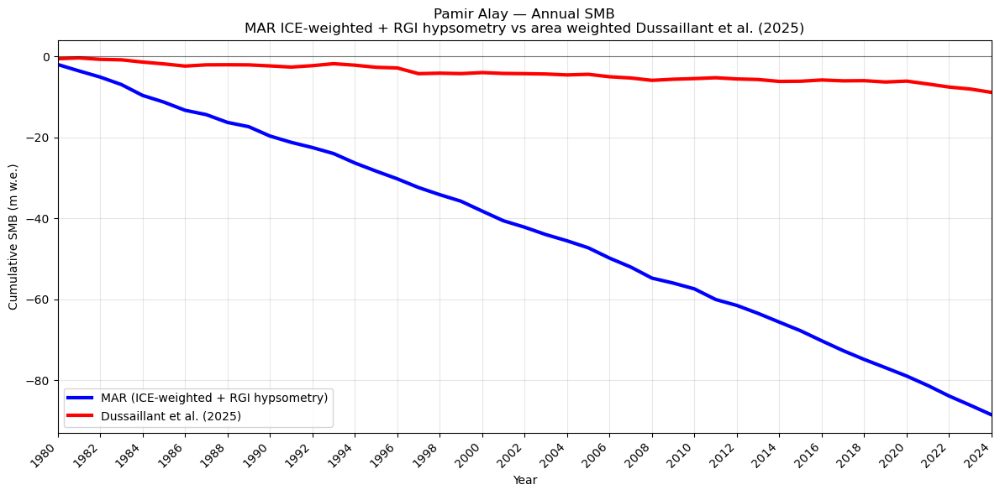

In [82]:
# ============================================================
# 0. INPUTS
# ============================================================

region_name = "Pamir Alay"

yr_start = '1980-01-16T12:00:00.000000000'
yr_stop  = '2024-12-16T12:00:00.000000000'

da =  ds_SMB_PA
df = dus_df_PA.copy()
hyps_rgi = hypsometry_rgi_PA.copy()


# ============================================================
# 1. MAR : SMB annuel puis cumulatif
# ============================================================


da = (
    da
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="A-SEP")
    .sum()
)

cum_smb = da.cumsum(dim="time")


# ============================================================
# 2. Empilement spatial
# ============================================================

cum_smb_points = cum_smb.stack(points=("Y", "X"))


elevation = (
    SH_pamir
    .where(mask_smb == region_id[region_name]) # inutile ..
    .stack(points=("Y", "X"))
)

ice = (
    ICE_pamir
    .where(mask_smb == region_id[region_name])
    .stack(points=("Y", "X"))
)

# ============================================================
# 3. Garder uniquement les pixels glaciers
#    ICE_pamir sert maintenant de POIDS
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation) &
    np.isfinite(ice)
)

cum_smb_points = cum_smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)

ice = ice.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

#hyps_rgi = hypsometry_rgi_WP.copy()

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values

dz = 200


# ============================================================
# 5. Classes d'altitude de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (
    bins[:-1] + bins[1:]
) / 2


# ============================================================
# 6. Assigner chaque pixel MAR à une classe d'altitude
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR moyen dans chaque classe d'altitude
#    PONDÉRÉ PAR ICE
# ============================================================

smb_by_altitude = []

for i in range(len(z_center)):

    # Pixels appartenant à la classe d'altitude
    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(
                cum_smb_points.time.size,
                np.nan
            )
        )

        continue


    # --------------------------------------------------------
    # Sélection des pixels
    # --------------------------------------------------------

    indices = np.where(pixel_class)[0]

    smb_class = cum_smb_points.isel(
        points=indices
    )

    ice_class = ice.isel(
        points=indices
    )


    # --------------------------------------------------------
    # Moyenne pondérée par ICE
    # --------------------------------------------------------
    #
    # ICE = fraction de glace dans chaque cellule
    #
    # SMB_class =
    #     SUM(SMB_i * ICE_i)
    #     ------------------
    #          SUM(ICE_i)
    #
    # --------------------------------------------------------

    smb_weighted_class = (
        (smb_class * ice_class).sum(
            dim="points",
            skipna=True
        )
        /
        ice_class.sum(
            dim="points",
            skipna=True
        )
    )


    smb_by_altitude.append(
        smb_weighted_class.values
    )


smb_by_altitude = np.array(
    smb_by_altitude
)


# ============================================================
# 8. Aligner l'hypsométrie RGI avec les classes MAR
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(
        altitude_rgi[idx] - z
    ) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB régional MAR
#    pondéré par l'hypsométrie RGI
# ============================================================

weighted_smb_mar = []

for t in range(
    cum_smb_points.time.size
):

    smb_t = smb_by_altitude[:, t]

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(
            percentage_rgi_aligned
        )
    )

    weighted_mean = (
        np.sum(
            smb_t[valid]
            *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb_mar.append(
        weighted_mean
    )


weighted_smb_mar = np.array(
    weighted_smb_mar
)


# ============================================================
# 10. Années MAR
# ============================================================

years_mar = [
    str(pd.Timestamp(t).year)
    for t in cum_smb_points.time.values
]


# ============================================================
# 11. DUSSAILLANT
# ============================================================

#df = dus_df_WP.copy()

year_1 = pd.Timestamp(yr_start).year
year_2 = pd.Timestamp(yr_stop).year +1

yrs = [
    str(y)
    for y in range(year_1, year_2)
]


# SMB cumulatif de chaque glacier
cum_smb_dus = df[yrs].cumsum(
    axis=1
)


# Moyenne pondérée par la surface des glaciers
weighted_mean_dus = (
    cum_smb_dus.mul(
        df["area"],
        axis=0
    ).sum(axis=0)
    /
    df["area"].sum()
)


# ============================================================
# 12. Comparaison MAR vs Dussaillant
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# ------------------------------------------------------------
# Conversion des années en numériques
# ------------------------------------------------------------

years_mar_num = np.array([
    int(y) for y in years_mar
])

years_dus_num = np.array([
    int(y) for y in yrs
])


# ------------------------------------------------------------
# MAR + ICE + hypsométrie RGI
# ------------------------------------------------------------

ax.plot(
    years_mar_num,
    weighted_smb_mar,
    color="blue",
    lw=3,
    label="MAR (ICE-weighted + RGI hypsometry)"
)


# ------------------------------------------------------------
# Dussaillant et al. (2025)
# ------------------------------------------------------------

ax.plot(
    years_dus_num,
    weighted_mean_dus.values,
    color="red",
    lw=3,
    label="Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Ligne SMB = 0
# ------------------------------------------------------------

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_xlabel("Year")

ax.set_ylabel(
    "Cumulative SMB (m w.e.)"
)


# ------------------------------------------------------------
# Axe X : un label tous les 5 ans
# ------------------------------------------------------------

years_ticks = np.arange(1980, 2025, 2)

ax.set_xticks(years_ticks)

ax.set_xticklabels(
    [str(y) for y in years_ticks],
    rotation=45,
    ha="right"
)


# ------------------------------------------------------------
# Limites X
# ------------------------------------------------------------

ax.set_xlim(
    1980,
    2024
)


# ------------------------------------------------------------
# Titre
# ------------------------------------------------------------

ax.set_title(
    f"{region_name} — Annual SMB\n"
    "MAR ICE-weighted + RGI hypsometry vs "
    "area weighted Dussaillant et al. (2025)"
)



# ------------------------------------------------------------
# Grille + légende
# ------------------------------------------------------------

ax.grid(alpha=0.3)

ax.legend()


plt.tight_layout()
plt.show()
plt.show()

### Synthese avec MAR ice-weighted

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


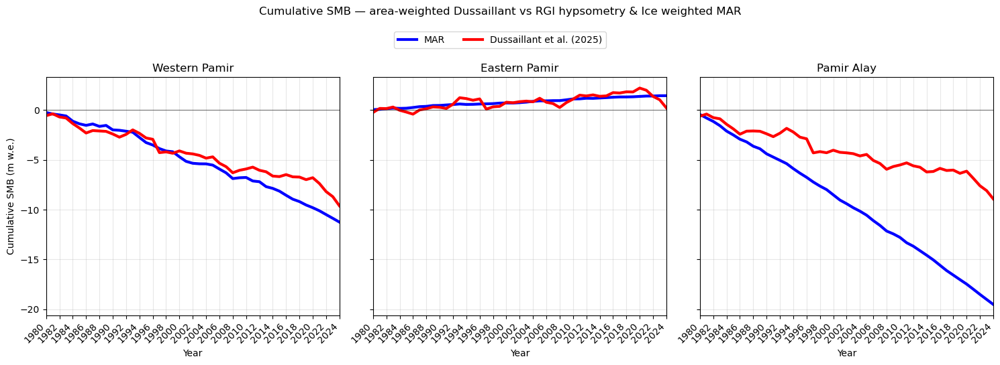

In [84]:
# ============================================================
# 1. PARAMÈTRES
# ============================================================

yr_start = '1979-10-01T12:00:00.000000000'
yr_stop  = '2024-09-30T12:00:00.000000000'

dz = 200


# ============================================================
# 2. DONNÉES DES 3 RÉGIONS
# ============================================================

regions = [
    {
        "name": "Western Pamir",
        "ds": ds_SMB_WP,
        "df": dus_df_WP.copy(),
        "hyps": hypsometry_rgi_WP.copy(),
    },
    {
        "name": "Eastern Pamir",
        "ds": ds_SMB_EP,
        "df": dus_df_EP.copy(),
        "hyps": hypsometry_rgi_EP.copy(),
    },
    {
        "name": "Pamir Alay",
        "ds": ds_SMB_PA,
        "df": dus_df_PA.copy(),
        "hyps": hypsometry_rgi_PA.copy(),
    }
]


# ============================================================
# 3. FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)


# ============================================================
# 4. BOUCLE SUR LES RÉGIONS
# ============================================================

for ax, region in zip(axes, regions):

    region_name = region["name"]
    da = region["ds"]
    df = region["df"]
    hyps_rgi = region["hyps"]


    # ========================================================
    # MAR : SMB annuel puis cumulatif
    # ========================================================

    da = (
        da
        .sel(
            time=slice(
                yr_start,
                yr_stop
            )
        )
        .resample(time="A-SEP")
        .sum()
    )

    cum_smb = da.cumsum(
        dim="time"
    )


    # ========================================================
    # Empilement spatial
    # ========================================================

    cum_smb_points = cum_smb.stack(
        points=("Y", "X")
    )

    elevation = SH_pamir.stack(
        points=("Y", "X")
    )

    ice = ICE_pamir.stack(
        points=("Y", "X")
    )


    # ========================================================
    # Garder uniquement les pixels glaciers
    # ========================================================

    valid_glacier = (
        (ice > 0) &
        np.isfinite(elevation) &
        np.isfinite(ice)
    )

    cum_smb_points = cum_smb_points.where(
        valid_glacier,
        drop=True
    )

    elevation = elevation.where(
        valid_glacier,
        drop=True
    )

    ice = ice.where(
        valid_glacier,
        drop=True
    )


    # ========================================================
    # Hypsométrie RGI
    # ========================================================

    altitude_rgi = hyps_rgi[
        "altitude_m"
    ].values

    percentage_rgi = hyps_rgi[
        "percentage_rgi"
    ].values


    # ========================================================
    # Classes d'altitude de 200 m
    # ========================================================

    bins = np.arange(
        altitude_rgi.min() - dz / 2,
        altitude_rgi.max() + dz / 2 + dz,
        dz
    )

    z_center = (
        bins[:-1] +
        bins[1:]
    ) / 2


    # ========================================================
    # Attribuer chaque pixel MAR à une classe
    # ========================================================

    class_index = np.digitize(
        elevation.values,
        bins
    ) - 1


    # ========================================================
    # SMB MAR moyen par classe d'altitude
    # ========================================================

    smb_by_altitude = []

    for i in range(
        len(z_center)
    ):

        pixel_class = (
            class_index == i
        )

        if not np.any(
            pixel_class
        ):

            smb_by_altitude.append(
                np.full(
                    cum_smb_points.time.size,
                    np.nan
                )
            )

            continue


        # ----------------------------------------------------
        # Sélection des pixels
        # ----------------------------------------------------

        indices = np.where(
            pixel_class
        )[0]

        smb_class = cum_smb_points.isel(
            points=indices
        )

        ice_class = ice.isel(
            points=indices
        )


        # ----------------------------------------------------
        # Moyenne pondérée par ICE
        # ----------------------------------------------------

        smb_weighted_class = (
            (
                smb_class *
                ice_class
            ).sum(
                dim="points",
                skipna=True
            )
            /
            ice_class.sum(
                dim="points",
                skipna=True
            )
        )

        smb_by_altitude.append(
            smb_weighted_class.values
        )


    smb_by_altitude = np.array(
        smb_by_altitude
    )


    # ========================================================
    # Alignement de l'hypsométrie RGI
    # ========================================================

    percentage_rgi_aligned = np.full(
        len(z_center),
        np.nan
    )

    for i, z in enumerate(
        z_center
    ):

        idx = np.argmin(
            np.abs(
                altitude_rgi - z
            )
        )

        if np.abs(
            altitude_rgi[idx] - z
        ) < dz / 2:

            percentage_rgi_aligned[i] = (
                percentage_rgi[idx]
            )


    # ========================================================
    # SMB régional MAR
    # pondéré par l'hypsométrie RGI
    # ========================================================

    weighted_smb_mar = []

    for t in range(
        cum_smb_points.time.size
    ):

        smb_t = smb_by_altitude[
            :, t
        ]

        valid = (
            np.isfinite(smb_t) &
            np.isfinite(
                percentage_rgi_aligned
            )
        )

        weighted_mean = (
            np.sum(
                smb_t[valid] *
                percentage_rgi_aligned[valid]
            )
            /
            np.sum(
                percentage_rgi_aligned[valid]
            )
        )

        weighted_smb_mar.append(
            weighted_mean
        )


    weighted_smb_mar = np.array(
        weighted_smb_mar
    )


    # ========================================================
    # Années MAR
    # ========================================================

    years_mar = [
        str(
            pd.Timestamp(t).year
        )
        for t in cum_smb_points.time.values
    ]

    years_mar_num = np.array([
        int(y)
        for y in years_mar
    ])


    # ========================================================
    # DUSSAILLANT
    # ========================================================

    year_1 = pd.Timestamp(
        yr_start
    ).year

    year_2 = pd.Timestamp(
        yr_stop
    ).year + 1

    yrs = [
        str(y)
        for y in range(
            year_1,
            year_2
        )
    ]


    # ========================================================
    # SMB cumulatif de chaque glacier
    # ========================================================

    cum_smb_dus = df[
        yrs
    ].cumsum(
        axis=1
    )


    # ========================================================
    # Moyenne pondérée par la surface
    # ========================================================

    weighted_mean_dus = (
        cum_smb_dus
        .mul(
            df["area"],
            axis=0
        )
        .sum(
            axis=0
        )
        /
        df["area"].sum()
    )


    years_dus_num = np.array([
        int(y)
        for y in yrs
    ])


    # ========================================================
    # PLOT MAR
    # ========================================================

    ax.plot(
        years_mar_num,
        weighted_smb_mar,
        color="blue",
        lw=3,
        label="MAR"
    )


    # ========================================================
    # PLOT DUSSAILLANT
    # ========================================================

    ax.plot(
        years_dus_num,
        weighted_mean_dus.values,
        color="red",
        lw=3,
        label="Dussaillant et al. (2025)"
    )


    # ========================================================
    # SMB = 0
    # ========================================================

    ax.axhline(
        0,
        color="black",
        lw=0.8,
        alpha=0.5
    )


    # ========================================================
    # TITRE
    # ========================================================

    ax.set_title(
        region_name
    )


    # ========================================================
    # GRILLE
    # ========================================================

    ax.grid(
        alpha=0.3
    )


    # ========================================================
    # AXE X
    # ========================================================

    years_ticks = np.arange(
        1980,
        2025,
        2
    )

    ax.set_xticks(
        years_ticks
    )

    ax.set_xticklabels(
        [
            str(y)
            for y in years_ticks
        ],
        rotation=45,
        ha="right"
    )

    ax.set_xlim(
        1980,
        2024
    )


# ============================================================
# 5. LABELS COMMUNS
# ============================================================

axes[0].set_ylabel(
    "Cumulative SMB (m w.e.)"
)

for ax in axes:
    ax.set_xlabel(
        "Year"
    )


# ============================================================
# 6. LÉGENDE UNIQUE
# ============================================================

handles, labels = (
    axes[0].get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2
)


# ============================================================
# 7. TITRE GLOBAL
# ============================================================

fig.suptitle(
    "Cumulative SMB — area-weighted Dussaillant vs "
    "RGI hypsometry & Ice weighted MAR",
    y=1.08
)


# ============================================================
# 8. MISE EN PAGE
# ============================================================

plt.tight_layout()

plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


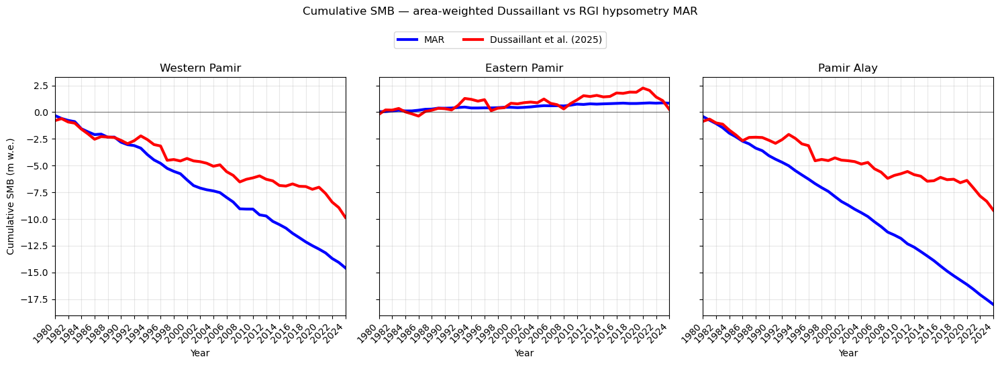

## Comparaison MAR Dussaillant Séries temprelles SMB Sans PONDERATION ICE pour MAR

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


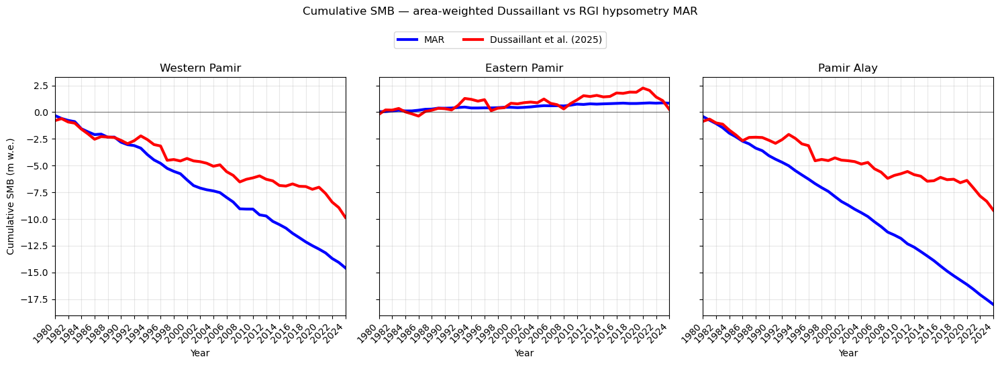

In [139]:
# ============================================================
# 1. PARAMÈTRES
# ============================================================

yr_start = '1979-10-01T12:00:00.000000000'
yr_stop  = '2024-09-30T12:00:00.000000000'

dz = 200


# ============================================================
# 2. DONNÉES DES 3 RÉGIONS
# ============================================================

regions = [
    {
        "name": "Western Pamir",
        "ds": ds_SMB_WP,
        "df": dus_df_WP.copy(),
        "hyps": hypsometry_rgi_WP.copy(),
    },
    {
        "name": "Eastern Pamir",
        "ds": ds_SMB_EP,
        "df": dus_df_EP.copy(),
        "hyps": hypsometry_rgi_EP.copy(),
    },
    {
        "name": "Pamir Alay",
        "ds": ds_SMB_PA,
        "df": dus_df_PA.copy(),
        "hyps": hypsometry_rgi_PA.copy(),
    }
]


# ============================================================
# 3. FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)


# ============================================================
# 4. BOUCLE SUR LES RÉGIONS
# ============================================================

for ax, region in zip(axes, regions):

    region_name = region["name"]
    da = region["ds"]
    df = region["df"]
    hyps_rgi = region["hyps"]


    # ========================================================
    # MAR : SMB annuel puis cumulatif
    # ========================================================

    da = (
        da
        .sel(
            time=slice(
                yr_start,
                yr_stop
            )
        )
        .resample(time="A-SEP")
        .sum()
    )

    cum_smb = da.cumsum(
        dim="time"
    )


    # ========================================================
    # Empilement spatial
    # ========================================================

    cum_smb_points = cum_smb.stack(
        points=("Y", "X")
    )

    elevation = SH_pamir.stack(
        points=("Y", "X")
    )

    ice = ICE_pamir.stack(
        points=("Y", "X")
    )


    # ========================================================
    # Garder uniquement les pixels glaciers
    # ========================================================
    # ICE est utilisé UNIQUEMENT comme masque.
    # Il ne sert PAS de poids dans le calcul du SMB.

    valid_glacier = (
        (ice > 0) &
        np.isfinite(elevation) &
        np.isfinite(ice)
    )

    cum_smb_points = cum_smb_points.where(
        valid_glacier,
        drop=True
    )

    elevation = elevation.where(
        valid_glacier,
        drop=True
    )

    ice = ice.where(
        valid_glacier,
        drop=True
    )


    # ========================================================
    # Hypsométrie RGI
    # ========================================================

    altitude_rgi = hyps_rgi[
        "altitude_m"
    ].values

    percentage_rgi = hyps_rgi[
        "percentage_rgi"
    ].values


    # ========================================================
    # Classes d'altitude de 200 m
    # ========================================================

    bins = np.arange(
        altitude_rgi.min() - dz / 2,
        altitude_rgi.max() + dz / 2 + dz,
        dz
    )

    z_center = (
        bins[:-1] +
        bins[1:]
    ) / 2


    # ========================================================
    # Attribuer chaque pixel MAR à une classe
    # ========================================================

    class_index = np.digitize(
        elevation.values,
        bins
    ) - 1


    # ========================================================
    # SMB MAR moyen par classe d'altitude
    # ========================================================
    #
    # PAS DE PONDÉRATION PAR ICE
    #
    # Chaque pixel valide contribue de manière égale.
    #
    # ========================================================

    smb_by_altitude = []

    for i in range(
        len(z_center)
    ):

        pixel_class = (
            class_index == i
        )

        if not np.any(
            pixel_class
        ):

            smb_by_altitude.append(
                np.full(
                    cum_smb_points.time.size,
                    np.nan
                )
            )

            continue


        # ----------------------------------------------------
        # Sélection des pixels
        # ----------------------------------------------------

        indices = np.where(
            pixel_class
        )[0]

        smb_class = cum_smb_points.isel(
            points=indices
        )


        # ----------------------------------------------------
        # Moyenne ARITHMÉTIQUE des pixels
        #
        # Aucun poids ICE
        # ----------------------------------------------------

        smb_mean_class = smb_class.mean(
            dim="points",
            skipna=True
        )

        smb_by_altitude.append(
            smb_mean_class.values
        )


    smb_by_altitude = np.array(
        smb_by_altitude
    )


    # ========================================================
    # Alignement de l'hypsométrie RGI
    # ========================================================

    percentage_rgi_aligned = np.full(
        len(z_center),
        np.nan
    )

    for i, z in enumerate(
        z_center
    ):

        idx = np.argmin(
            np.abs(
                altitude_rgi - z
            )
        )

        if np.abs(
            altitude_rgi[idx] - z
        ) < dz / 2:

            percentage_rgi_aligned[i] = (
                percentage_rgi[idx]
            )


    # ========================================================
    # SMB régional MAR
    # pondéré par l'hypsométrie RGI
    # ========================================================

    weighted_smb_mar = []

    for t in range(
        cum_smb_points.time.size
    ):

        smb_t = smb_by_altitude[
            :, t
        ]

        valid = (
            np.isfinite(smb_t) &
            np.isfinite(
                percentage_rgi_aligned
            )
        )

        weighted_mean = (
            np.sum(
                smb_t[valid] *
                percentage_rgi_aligned[valid]
            )
            /
            np.sum(
                percentage_rgi_aligned[valid]
            )
        )

        weighted_smb_mar.append(
            weighted_mean
        )


    weighted_smb_mar = np.array(
        weighted_smb_mar
    )


    # ========================================================
    # Années MAR
    # ========================================================

    years_mar = [
        str(
            pd.Timestamp(t).year
        )
        for t in cum_smb_points.time.values
    ]

    years_mar_num = np.array([
        int(y)
        for y in years_mar
    ])


    # ========================================================
    # DUSSAILLANT
    # ========================================================

    year_1 = pd.Timestamp(
        yr_start
    ).year

    year_2 = pd.Timestamp(
        yr_stop
    ).year + 1

    yrs = [
        str(y)
        for y in range(
            year_1,
            year_2
        )
    ]


    # ========================================================
    # SMB cumulatif de chaque glacier
    # ========================================================

    cum_smb_dus = df[
        yrs
    ].cumsum(
        axis=1
    )


    # ========================================================
    # Moyenne pondérée par la surface
    # ========================================================

    weighted_mean_dus = (
        cum_smb_dus
        .mul(
            df["area"],
            axis=0
        )
        .sum(
            axis=0
        )
        /
        df["area"].sum()
    )


    years_dus_num = np.array([
        int(y)
        for y in yrs
    ])


    # ========================================================
    # PLOT MAR
    # ========================================================

    ax.plot(
        years_mar_num,
        weighted_smb_mar,
        color="blue",
        lw=3,
        label="MAR"
    )


    # ========================================================
    # PLOT DUSSAILLANT
    # ========================================================

    ax.plot(
        years_dus_num,
        weighted_mean_dus.values,
        color="red",
        lw=3,
        label="Dussaillant et al. (2025)"
    )


    # ========================================================
    # SMB = 0
    # ========================================================

    ax.axhline(
        0,
        color="black",
        lw=0.8,
        alpha=0.5
    )


    # ========================================================
    # TITRE
    # ========================================================

    ax.set_title(
        region_name
    )


    # ========================================================
    # GRILLE
    # ========================================================

    ax.grid(
        alpha=0.3
    )


    # ========================================================
    # AXE X
    # ========================================================

    years_ticks = np.arange(
        1980,
        2025,
        2
    )

    ax.set_xticks(
        years_ticks
    )

    ax.set_xticklabels(
        [
            str(y)
            for y in years_ticks
        ],
        rotation=45,
        ha="right"
    )

    ax.set_xlim(
        1980,
        2024
    )


# ============================================================
# 5. LABELS COMMUNS
# ============================================================

axes[0].set_ylabel(
    "Cumulative SMB (m w.e.)"
)

for ax in axes:
    ax.set_xlabel(
        "Year"
    )


# ============================================================
# 6. LÉGENDE UNIQUE
# ============================================================

handles, labels = (
    axes[0].get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2
)


# ============================================================
# 7. TITRE GLOBAL
# ============================================================

fig.suptitle(
    "Cumulative SMB — area-weighted Dussaillant vs "
    "RGI hypsometry MAR",
    y=1.08
)


# ============================================================
# 8. MISE EN PAGE
# ============================================================

plt.tight_layout()

plt.show()


/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/tmp/ipykernel_2602569/596090820.py:150: RuntimeWarning: Mean of empty slice
  smb_mar_mean_altitude = np.nanmean(


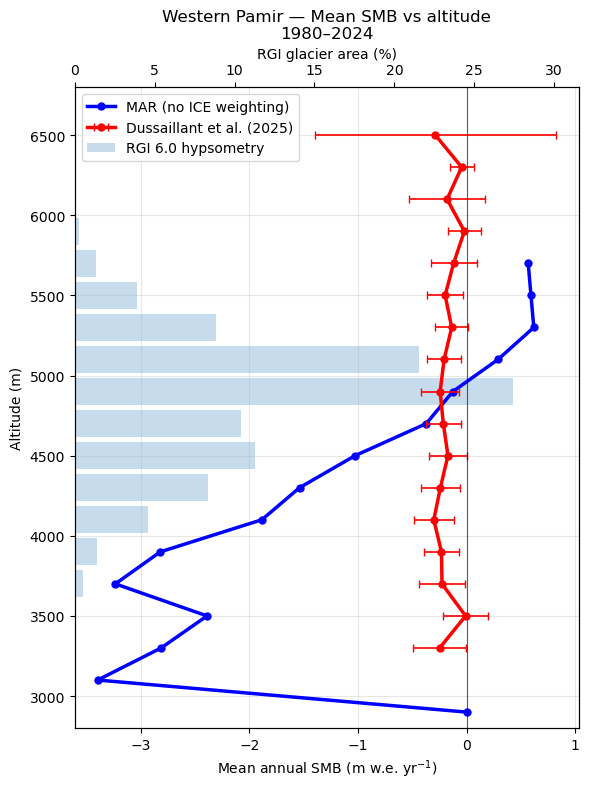

In [110]:
# ============================================================
# 0. INPUTS
# ============================================================

region_name = "Western Pamir"

yr_start = '1980-01-16T12:00:00.000000000'
yr_stop  = '2024-12-16T12:00:00.000000000'

da = ds_SMB_WP
df = dus_df_WP.copy()
hyps_rgi = hypsometry_rgi_WP.copy()

dz = 200


# ============================================================
# 1. DATASET MAR
# ============================================================

da = (
    da
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="A-SEP")
    .sum()
)


# ============================================================
# 2. EMPILEMENT SPATIAL
# ============================================================

smb_points = da.stack(points=("Y", "X"))

elevation = SH_pamir.stack(points=("Y", "X"))

ice = ICE_pamir.stack(points=("Y", "X"))


# ============================================================
# 3. GARDER UNIQUEMENT LES PIXELS GLACIERS
# ============================================================

valid_glacier = (
    (ice > 2) &
    np.isfinite(elevation) &
    np.isfinite(ice)
)

smb_points = smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)

ice = ice.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. HYPSOMÉTRIE RGI
# ============================================================

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values


# ============================================================
# 5. CLASSES D'ALTITUDE DE 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (
    bins[:-1] + bins[1:]
) / 2


# ============================================================
# 6. ATTRIBUER CHAQUE PIXEL MAR À UNE CLASSE D'ALTITUDE
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR PAR CLASSE D'ALTITUDE
#    SANS PONDÉRATION PAR ICE
# ============================================================

smb_mar_by_altitude = []

for i in range(len(z_center)):

    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_mar_by_altitude.append(
            np.full(
                smb_points.time.size,
                np.nan
            )
        )

        continue

    indices = np.where(pixel_class)[0]

    smb_class = smb_points.isel(
        points=indices
    )

    # --------------------------------------------------------
    # Moyenne arithmétique des pixels MAR
    # --------------------------------------------------------

    smb_mean_class = smb_class.mean(
        dim="points",
        skipna=True
    )

    smb_mar_by_altitude.append(
        smb_mean_class.values
    )


smb_mar_by_altitude = np.array(
    smb_mar_by_altitude
)


# ============================================================
# 8. MOYENNE TEMPORELLE DU SMB MAR
# ============================================================

smb_mar_mean_altitude = np.nanmean(
    smb_mar_by_altitude,
    axis=1
)


# ============================================================
# 9. ALIGNEMENT DE L'HYPSOMÉTRIE RGI
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(
        altitude_rgi[idx] - z
    ) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 10. DUSSAILLANT
# ============================================================

year_1 = pd.Timestamp(yr_start).year
year_2 = pd.Timestamp(yr_stop).year + 1

yrs = [
    str(y)
    for y in range(year_1, year_2)
]

# Garder uniquement les années disponibles
yrs = [
    y for y in yrs
    if y in df.columns
]

smb_dus = df[yrs]


# ============================================================
# 11. SMB MOYEN DE CHAQUE GLACIER SUR 1980–2024
# ============================================================

df["SMB_mean_1980_2024"] = (
    smb_dus.mean(
        axis=1,
        skipna=True
    )
)


# ============================================================
# 12. CLASSER LES GLACIERS DUSSAILLANT PAR Zmed
# ============================================================

class_index_dus = np.digitize(
    df["Zmed"].values,
    bins
) - 1


# ============================================================
# 13. SMB DUSSAILLANT PAR CLASSE D'ALTITUDE
#
#     MOYENNE :
#     pondérée par la surface des glaciers
#
#     ÉCART-TYPE :
#     entre les SMB moyens individuels
# ============================================================

smb_dus_mean_altitude = []
smb_dus_std_altitude = []

for i in range(len(z_center)):

    glacier_class = (
        class_index_dus == i
    )

    if not np.any(glacier_class):

        smb_dus_mean_altitude.append(
            np.nan
        )

        smb_dus_std_altitude.append(
            np.nan
        )

        continue

    df_class = df.loc[
        glacier_class
    ].copy()

    # --------------------------------------------------------
    # SMB moyen 1980–2024 de chaque glacier
    # --------------------------------------------------------

    smb_glacier = df_class[
        "SMB_mean_1980_2024"
    ]

    area_class = df_class[
        "area"
    ]

    # --------------------------------------------------------
    # Garder les glaciers avec SMB et surface valides
    # --------------------------------------------------------

    valid = (
        np.isfinite(smb_glacier) &
        np.isfinite(area_class) &
        (area_class > 0)
    )

    smb_glacier = smb_glacier[valid]
    area_class = area_class[valid]

    if len(smb_glacier) == 0:

        smb_dus_mean_altitude.append(
            np.nan
        )

        smb_dus_std_altitude.append(
            np.nan
        )

        continue


    # ========================================================
    # 13a. MOYENNE SMB DE LA CLASSE
    #      PONDÉRÉE PAR LA SURFACE
    # ========================================================

    smb_weighted = (
        (smb_glacier * area_class).sum()
        /
        area_class.sum()
    )

    smb_dus_mean_altitude.append(
        smb_weighted
    )


    # ========================================================
    # 13b. ÉCART-TYPE ENTRE LES GLACIERS
    # ========================================================

    if len(smb_glacier) > 1:

        smb_std = np.std(
            smb_glacier,
            ddof=1
        )

    else:

        smb_std = np.nan

    smb_dus_std_altitude.append(
        smb_std
    )


smb_dus_mean_altitude = np.array(
    smb_dus_mean_altitude
)

smb_dus_std_altitude = np.array(
    smb_dus_std_altitude
)


# ============================================================
# 14. PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 8)
)


# ============================================================
# 15. HYPSOMÉTRIE RGI EN ARRIÈRE-PLAN
# ============================================================

valid_rgi = np.isfinite(
    percentage_rgi_aligned
)

ax2 = ax.twiny()

ax2.barh(
    z_center[valid_rgi],
    percentage_rgi_aligned[valid_rgi],
    height=dz * 0.85,
    alpha=0.25,
    label="RGI 6.0 hypsometry"
)

ax2.set_xlabel(
    "RGI glacier area (%)"
)

ax2.set_xlim(
    0,
    np.nanmax(
        percentage_rgi_aligned
    ) * 1.15
)

# Mettre l'hypsométrie derrière les courbes
ax.set_zorder(2)
ax2.set_zorder(1)

ax.patch.set_visible(False)


# ============================================================
# 16. PROFIL MAR
# ============================================================

valid_mar = np.isfinite(
    smb_mar_mean_altitude
)

ax.plot(
    smb_mar_mean_altitude[valid_mar],
    z_center[valid_mar],
    color="blue",
    lw=2.5,
    marker="o",
    markersize=5,
    label="MAR (no ICE weighting)"
)


# ============================================================
# 17. PROFIL DUSSAILLANT + ÉCART-TYPE
# ============================================================

valid_dus = (
    np.isfinite(
        smb_dus_mean_altitude
    )
    &
    np.isfinite(
        smb_dus_std_altitude
    )
)

ax.errorbar(
    smb_dus_mean_altitude[valid_dus],
    z_center[valid_dus],
    xerr=smb_dus_std_altitude[valid_dus],
    fmt="o-",
    color="red",
    lw=2.5,
    markersize=5,
    capsize=3,
    elinewidth=1.2,
    label="Dussaillant et al. (2025)"
)


# ============================================================
# 18. SMB = 0
# ============================================================

ax.axvline(
    0,
    color="black",
    lw=0.8,
    alpha=0.6
)


# ============================================================
# 19. LABELS
# ============================================================

ax.set_xlabel(
    "Mean annual SMB (m w.e. yr$^{-1}$)"
)

ax.set_ylabel(
    "Altitude (m)"
)


# ============================================================
# 20. LIMITES ALTITUDE
# ============================================================

ax.set_ylim(
    bins.min(),
    bins.max()
)


# ============================================================
# 21. TITRE
# ============================================================

ax.set_title(
    f"{region_name} — Mean SMB vs altitude\n"
    f"{year_1}–{year_2 - 1}"
)


# ============================================================
# 22. GRILLE
# ============================================================

ax.grid(
    alpha=0.3
)


# ============================================================
# 23. LÉGENDE COMBINÉE
# ============================================================

lines1, labels1 = (
    ax.get_legend_handles_labels()
)

lines2, labels2 = (
    ax2.get_legend_handles_labels()
)

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)


# ============================================================
# 24. AFFICHAGE
# ============================================================

plt.tight_layout()
plt.show()

In [103]:
i = np.where(class_index == 0)[0][0]

lat = LATS_pamir.stack(points=("Y", "X")).isel(points=i)
lon = LONS_pamir.stack(points=("Y", "X")).isel(points=i)

print("LAT :", float(lat.values))
print("LON :", float(lon.values))

LAT : 37.2635612487793
LON : 69.848388671875


/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


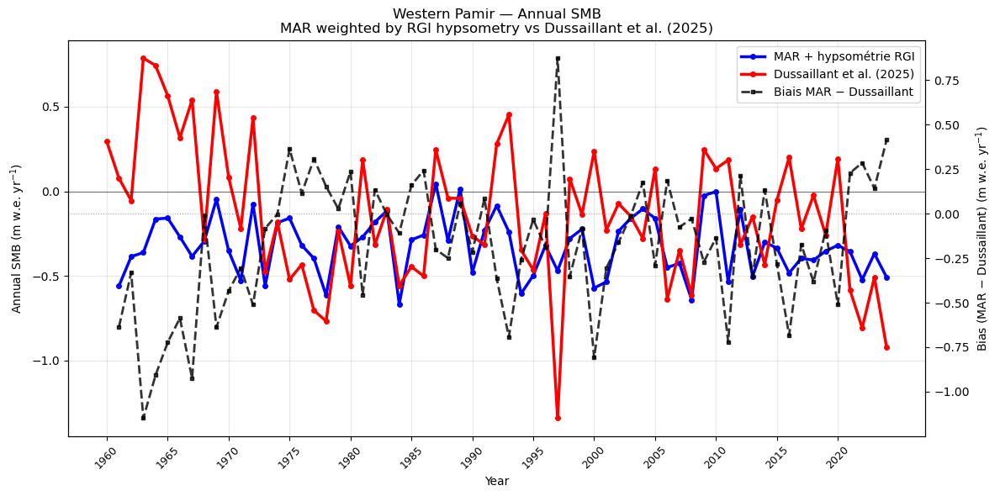

In [89]:
# ============================================================
# 1. MAR : SMB annuel
# ============================================================

yr_start = '1960-10-01T12:00:00.000000000'
yr_stop  = '2024-09-30T12:00:00.000000000'

da = (
    ds_SMB_WP
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="A-SEP")
    .sum()
)


# ============================================================
# 2. Empilement spatial
# ============================================================

smb_points = da.stack(points=("Y", "X"))

elevation = SH_pamir.stack(points=("Y", "X"))
ice = ICE_pamir.stack(points=("Y", "X"))


# ============================================================
# 3. Garder uniquement les pixels glaciers
#    ICE_pamir = masque uniquement, PAS un poids
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation)
)

smb_points = smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

hyps_rgi = hypsometry_rgi_WP.copy()

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values

dz = 200


# ============================================================
# 5. Classes d'altitude de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (bins[:-1] + bins[1:]) / 2


# ============================================================
# 6. Attribuer chaque pixel MAR à une classe d'altitude
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR moyen dans chaque classe d'altitude
# ============================================================

smb_by_altitude = []

for i in range(len(z_center)):

    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(smb_points.time.size, np.nan)
        )

    else:

        smb_class = smb_points.isel(
            points=np.where(pixel_class)[0]
        )

        smb_mean_class = smb_class.mean(
            dim="points",
            skipna=True
        )

        smb_by_altitude.append(
            smb_mean_class.values
        )

smb_by_altitude = np.array(smb_by_altitude)


# ============================================================
# 8. Aligner l'hypsométrie RGI avec les classes MAR
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(altitude_rgi[idx] - z) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB annuel régional MAR pondéré par RGI
# ============================================================

weighted_smb_mar = []

for t in range(smb_points.time.size):

    smb_t = smb_by_altitude[:, t]

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(percentage_rgi_aligned)
    )

    weighted_mean = (
        np.sum(
            smb_t[valid] *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb_mar.append(weighted_mean)

weighted_smb_mar = np.array(weighted_smb_mar)


# ============================================================
# 10. Années MAR
# ============================================================

years_mar = [
    str(pd.Timestamp(t).year)
    for t in smb_points.time.values
]


# ============================================================
# 11. DUSSAILLANT — WESTERN PAMIR
# ============================================================

df = dus_df_WP.copy()

yrs = [str(y) for y in range(1960, 2025)]

# SMB annuel de chaque glacier
smb_dus = df[yrs]

# Moyenne pondérée par la surface des glaciers
weighted_mean_dus = (
    smb_dus.mul(
        df["area"],
        axis=0
    ).sum(axis=0)
    /
    df["area"].sum()
)


# ============================================================
# 12. Comparaison MAR vs Dussaillant + biais annuel
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# ------------------------------------------------------------
# Conversion en années numériques
# ------------------------------------------------------------

years_mar_num = np.array(
    [int(y) for y in years_mar]
)

years_dus_num = np.array(
    [int(y) for y in yrs]
)


# ------------------------------------------------------------
# 1. MAR + hypsométrie RGI
# ------------------------------------------------------------

ax.plot(
    years_mar_num,
    weighted_smb_mar,
    color="blue",
    lw=2.5,
    marker="o",
    markersize=4,
    label="MAR + hypsométrie RGI"
)


# ------------------------------------------------------------
# 2. Dussaillant
# ------------------------------------------------------------

ax.plot(
    years_dus_num,
    weighted_mean_dus.values,
    color="red",
    lw=2.5,
    marker="o",
    markersize=4,
    label="Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Ligne SMB = 0
# ------------------------------------------------------------

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ------------------------------------------------------------
# 3. Calcul du biais annuel
#
# Biais = MAR - Dussaillant
# ------------------------------------------------------------

# Années communes
common_years = np.intersect1d(
    years_mar_num,
    years_dus_num
)

# Indices correspondants
idx_mar = np.isin(
    years_mar_num,
    common_years
)

idx_dus = np.isin(
    years_dus_num,
    common_years
)

# Séries sur les années communes
mar_common = weighted_smb_mar[idx_mar]

dus_common = weighted_mean_dus.values[idx_dus]

# Biais annuel
bias = mar_common - dus_common


# ------------------------------------------------------------
# 4. Deuxième axe Y
# ------------------------------------------------------------

ax2 = ax.twinx()

ax2.plot(
    common_years,
    bias,
    color="black",
    lw=2,
    linestyle="--",
    marker="s",
    markersize=3,
    alpha=0.8,
    label="Biais MAR − Dussaillant"
)

# Ligne biais = 0
ax2.axhline(
    0,
    color="gray",
    lw=0.8,
    linestyle=":",
    alpha=0.7
)


# ------------------------------------------------------------
# Labels des axes
# ------------------------------------------------------------

ax.set_xlabel("Year")

ax.set_ylabel(
    "Annual SMB (m w.e. yr$^{-1}$)"
)

ax2.set_ylabel(
    "Bias (MAR − Dussaillant) "
    "(m w.e. yr$^{-1}$)"
)


# ------------------------------------------------------------
# Ticks de l'axe X
# ------------------------------------------------------------

years_ticks = np.arange(
    1960,
    2025,
    5
)

ax.set_xticks(years_ticks)

ax.tick_params(
    axis="x",
    labelrotation=45,
    labelsize=9
)


# ------------------------------------------------------------
# Titre
# ------------------------------------------------------------

ax.set_title(
    "Western Pamir — Annual SMB\n"
    "MAR weighted by RGI hypsometry vs "
    "Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Grille
# ------------------------------------------------------------

ax.grid(
    alpha=0.3
)


# ------------------------------------------------------------
# Légende combinée des deux axes
# ------------------------------------------------------------

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)


plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


Moyenne du biais : -0.110 m w.e. yr⁻¹
Médiane du biais : -0.109 m w.e. yr⁻¹
Écart-type du biais : 0.321 m w.e. yr⁻¹


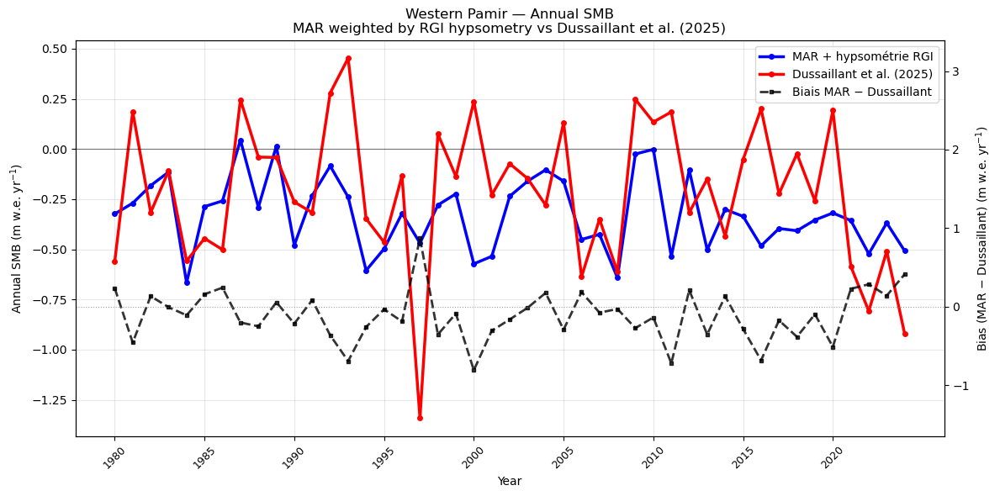

In [93]:
# ============================================================
# 1. MAR : SMB annuel
# ============================================================

yr_start = '1979-10-01T12:00:00.000000000'
yr_stop  = '2024-09-30T12:00:00.000000000'

da = (
    ds_SMB_WP
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="A-SEP")
    .sum()
)


# ============================================================
# 2. Empilement spatial
# ============================================================

smb_points = da.stack(points=("Y", "X"))

elevation = SH_pamir.stack(points=("Y", "X"))
ice = ICE_pamir.stack(points=("Y", "X"))


# ============================================================
# 3. Garder uniquement les pixels glaciers
#    ICE_pamir = masque uniquement, PAS un poids
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation)
)

smb_points = smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

hyps_rgi = hypsometry_rgi_WP.copy()

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values

dz = 200


# ============================================================
# 5. Classes d'altitude de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (bins[:-1] + bins[1:]) / 2


# ============================================================
# 6. Attribuer chaque pixel MAR à une classe d'altitude
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR moyen dans chaque classe d'altitude
# ============================================================

smb_by_altitude = []

for i in range(len(z_center)):

    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(smb_points.time.size, np.nan)
        )

    else:

        smb_class = smb_points.isel(
            points=np.where(pixel_class)[0]
        )

        smb_mean_class = smb_class.mean(
            dim="points",
            skipna=True
        )

        smb_by_altitude.append(
            smb_mean_class.values
        )

smb_by_altitude = np.array(smb_by_altitude)


# ============================================================
# 8. Aligner l'hypsométrie RGI avec les classes MAR
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(altitude_rgi[idx] - z) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB annuel régional MAR pondéré par RGI
# ============================================================

weighted_smb_mar = []

for t in range(smb_points.time.size):

    smb_t = smb_by_altitude[:, t]

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(percentage_rgi_aligned)
    )

    weighted_mean = (
        np.sum(
            smb_t[valid] *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb_mar.append(weighted_mean)

weighted_smb_mar = np.array(weighted_smb_mar)


# ============================================================
# 10. Années MAR
# ============================================================

years_mar = [
    str(pd.Timestamp(t).year)
    for t in smb_points.time.values
]


# ============================================================
# 11. DUSSAILLANT — WESTERN PAMIR
# ============================================================

df = dus_df_WP.copy()

yrs = [str(y) for y in range(1980, 2025)]

# SMB annuel de chaque glacier
smb_dus = df[yrs]

# Moyenne pondérée par la surface des glaciers
weighted_mean_dus = (
    smb_dus.mul(
        df["area"],
        axis=0
    ).sum(axis=0)
    /
    df["area"].sum()
)


# ============================================================
# 12. Comparaison MAR vs Dussaillant + biais annuel
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# ------------------------------------------------------------
# Conversion en années numériques
# ------------------------------------------------------------

years_mar_num = np.array([int(y) for y in years_mar])
years_dus_num = np.array([int(y) for y in yrs])


# ------------------------------------------------------------
# 1. MAR + hypsométrie RGI
# ------------------------------------------------------------

ax.plot(
    years_mar_num,
    weighted_smb_mar,
    color="blue",
    lw=2.5,
    marker="o",
    markersize=4,
    label="MAR + hypsométrie RGI"
)


# ------------------------------------------------------------
# 2. Dussaillant
# ------------------------------------------------------------

ax.plot(
    years_dus_num,
    weighted_mean_dus.values,
    color="red",
    lw=2.5,
    marker="o",
    markersize=4,
    label="Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Ligne SMB = 0
# ------------------------------------------------------------

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ------------------------------------------------------------
# 3. Calcul du biais annuel
# ------------------------------------------------------------

common_years = np.intersect1d(
    years_mar_num,
    years_dus_num
)

idx_mar = np.isin(
    years_mar_num,
    common_years
)

idx_dus = np.isin(
    years_dus_num,
    common_years
)

mar_common = weighted_smb_mar[idx_mar]
dus_common = weighted_mean_dus.values[idx_dus]

# Biais = MAR - Dussaillant
bias = mar_common - dus_common


# ------------------------------------------------------------
# 4. Deuxième axe Y
# ------------------------------------------------------------

ax2 = ax.twinx()

ax2.plot(
    common_years,
    bias,
    color="black",
    lw=2,
    linestyle="--",
    marker="s",
    markersize=3,
    alpha=0.8,
    label="Biais MAR − Dussaillant"
)

ax2.axhline(
    0,
    color="gray",
    lw=0.8,
    linestyle=":",
    alpha=0.7
)


# ------------------------------------------------------------
# 5. Décaler visuellement l'échelle du biais vers le bas
# ------------------------------------------------------------

bias_min = np.nanmin(bias)
bias_max = np.nanmax(bias)

# Marge autour du biais
bias_range = bias_max - bias_min

if bias_range == 0:
    bias_range = 1

# On décale la fenêtre du deuxième axe vers le bas
ax2.set_ylim(
    bias_min - 0.5 * bias_range,
    bias_max + 1.5 * bias_range
)


# ------------------------------------------------------------
# Labels des axes
# ------------------------------------------------------------

ax.set_xlabel("Year")

ax.set_ylabel(
    "Annual SMB (m w.e. yr$^{-1}$)"
)

ax2.set_ylabel(
    "Bias (MAR − Dussaillant) "
    "(m w.e. yr$^{-1}$)"
)


# ------------------------------------------------------------
# Ticks de l'axe X
# ------------------------------------------------------------

years_ticks = np.arange(
    1980,
    2025,
    5
)

ax.set_xticks(years_ticks)

ax.tick_params(
    axis="x",
    labelrotation=45,
    labelsize=9
)


# ------------------------------------------------------------
# Titre
# ------------------------------------------------------------

ax.set_title(
    "Western Pamir — Annual SMB\n"
    "MAR weighted by RGI hypsometry vs "
    "Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Grille
# ------------------------------------------------------------

ax.grid(
    alpha=0.3
)


# ------------------------------------------------------------
# Légende combinée
# ------------------------------------------------------------

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)

plt.tight_layout()

moyenne_biais = np.nanmean(bias)
mediane_biais = np.nanmedian(bias)
std_dev_biais = np.nanstd(bias)

print(f"Moyenne du biais : {moyenne_biais:.3f} m w.e. yr⁻¹")
print(f"Médiane du biais : {mediane_biais:.3f} m w.e. yr⁻¹")
print(f"Écart-type du biais : {std_dev_biais:.3f} m w.e. yr⁻¹")

plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(



Western Pamir — MOYENNES SMB PAR TRANCHES DE 5 ANS
   Period    MAR  Dussaillant   Bias
1980–1984 -0.315       -0.271 -0.045
1985–1989 -0.082       -0.157  0.075
1990–1994 -0.307       -0.039 -0.268
1995–1999 -0.345       -0.400  0.055
2000–2004 -0.312       -0.098 -0.214
2005–2009 -0.338       -0.244 -0.094
2010–2014 -0.261       -0.116 -0.145
2015–2019 -0.413       -0.071 -0.342
2020–2024 -0.440       -0.526  0.086
Biais MAR − Dussaillant (1980–2024)
Nombre de périodes : 9
Moyenne   : -0.099 m w.e. yr⁻¹
Médiane   : -0.094 m w.e. yr⁻¹
Écart-type : 0.156 m w.e. yr⁻¹


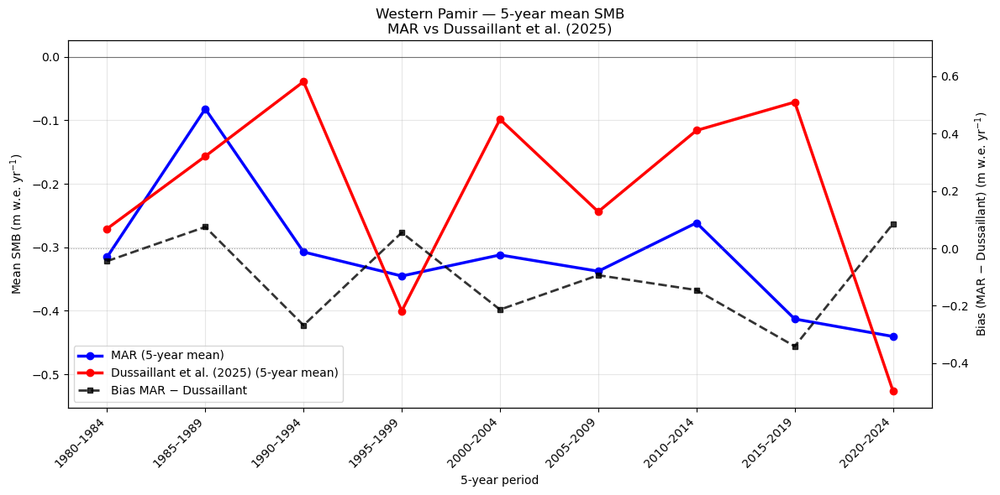

In [91]:
# ============================================================
# COMPARAISON SMB MAR vs DUSSAILLANT
# WESTERN PAMIR
# MOYENNES PAR TRANCHES DE 5 ANS
# ============================================================

# ============================================================
# 0. INPUTS
# ============================================================

region_name = "Western Pamir"

yr_start = '1980-01-16T12:00:00.000000000'
yr_stop  = '2024-12-16T12:00:00.000000000'

da = ds_SMB_WP
df = dus_df_WP.copy()
hyps_rgi = hypsometry_rgi_WP.copy()


# ============================================================
# 1. DATASET MAR
# ============================================================

da = (
    da
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="A-SEP")
    .sum()
)


# ============================================================
# 2. EMPILEMENT SPATIAL
# ============================================================

smb_points = da.stack(
    points=("Y", "X")
)


elevation = (
    SH_pamir
    .where(
        mask_smb == region_id[region_name]
    )
    .stack(
        points=("Y", "X")
    )
)


ice = (
    ICE_pamir
    .where(
        mask_smb == region_id[region_name]
    )
    .stack(
        points=("Y", "X")
    )
)


# ============================================================
# 3. GARDER UNIQUEMENT LES PIXELS GLACIERS
# ============================================================

valid_glacier = (
    (ice > 0)
    &
    np.isfinite(elevation)
    &
    np.isfinite(ice)
)


smb_points = smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)

ice = ice.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. HYPSONOMÉTRIE RGI
# ============================================================

altitude_rgi = (
    hyps_rgi["altitude_m"].values
)

percentage_rgi = (
    hyps_rgi["percentage_rgi"].values
)

dz = 200


# ============================================================
# 5. CLASSES D'ALTITUDE DE 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (
    bins[:-1] + bins[1:]
) / 2


# ============================================================
# 6. ATTRIBUTION DES PIXELS AUX CLASSES D'ALTITUDE
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR PAR CLASSE D'ALTITUDE
#    PONDÉRÉ PAR ICE
# ============================================================

smb_by_altitude = []


for i in range(len(z_center)):

    pixel_class = (
        class_index == i
    )

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(
                smb_points.time.size,
                np.nan
            )
        )

        continue


    indices = np.where(
        pixel_class
    )[0]


    smb_class = smb_points.isel(
        points=indices
    )

    ice_class = ice.isel(
        points=indices
    )


    # --------------------------------------------------------
    # Moyenne pondérée par ICE
    # --------------------------------------------------------

    smb_weighted_class = (
        (smb_class * ice_class)
        .sum(
            dim="points",
            skipna=True
        )
        /
        ice_class
        .sum(
            dim="points",
            skipna=True
        )
    )


    smb_by_altitude.append(
        smb_weighted_class.values
    )


smb_by_altitude = np.array(
    smb_by_altitude
)


# ============================================================
# 8. ALIGNEMENT HYPSONOMÉTRIE RGI / MAR
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)


for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(
            altitude_rgi - z
        )
    )

    if np.abs(
        altitude_rgi[idx] - z
    ) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB ANNUEL RÉGIONAL MAR
# ============================================================

weighted_smb_mar = []


for t in range(
    smb_points.time.size
):

    smb_t = (
        smb_by_altitude[:, t]
    )


    valid = (
        np.isfinite(smb_t)
        &
        np.isfinite(
            percentage_rgi_aligned
        )
    )


    weighted_mean = (
        np.sum(
            smb_t[valid]
            *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )


    weighted_smb_mar.append(
        weighted_mean
    )


weighted_smb_mar = np.array(
    weighted_smb_mar
)


# ============================================================
# 10. ANNÉES MAR
# ============================================================

years_mar = np.array([
    pd.Timestamp(t).year
    for t in smb_points.time.values
])


# ============================================================
# 11. DUSSAILLANT — SMB ANNUEL RÉGIONAL
# ============================================================

year_1 = pd.Timestamp(
    yr_start
).year

year_2 = pd.Timestamp(
    yr_stop
).year


# Liste des années disponibles
years_dus = np.arange(
    year_1,
    year_2 + 1
)


yrs = [
    str(y)
    for y in years_dus
]


# ------------------------------------------------------------
# SMB annuel de chaque glacier
# ------------------------------------------------------------

smb_dus = df[yrs]


# ------------------------------------------------------------
# Moyenne pondérée par la surface
# ------------------------------------------------------------

weighted_mean_dus = (
    smb_dus.mul(
        df["area"],
        axis=0
    )
    .sum(
        axis=0
    )
    /
    df["area"].sum()
)


# Série Dussaillant annuelle
dus_annual = pd.Series(
    weighted_mean_dus.values,
    index=years_dus
)


# ============================================================
# 12. SÉRIE MAR ANNUELLE
# ============================================================

mar_annual = pd.Series(
    weighted_smb_mar,
    index=years_mar
)


# ============================================================
# 13. MOYENNE MAR PAR TRANCHES DE 5 ANS
# ============================================================

mar_5yr = []


for start in range(
    year_1,
    year_2 + 1,
    5
):

    end = min(
        start + 4,
        year_2
    )


    # --------------------------------------------------------
    # Années de la période
    # --------------------------------------------------------

    period_years = np.arange(
        start,
        end + 1
    )


    # --------------------------------------------------------
    # Années effectivement disponibles dans MAR
    # --------------------------------------------------------

    available_years = [
        y
        for y in period_years
        if y in mar_annual.index
    ]


    if len(available_years) == 0:

        mean_mar = np.nan

    else:

        mean_mar = (
            mar_annual
            .loc[available_years]
            .mean()
        )


    mar_5yr.append({
        "start": start,
        "end": end,
        "MAR": mean_mar
    })


mar_5yr = pd.DataFrame(
    mar_5yr
)


# ============================================================
# 14. MOYENNE DUSSAILLANT PAR TRANCHES DE 5 ANS
# ============================================================

dus_5yr = []


for start in range(
    year_1,
    year_2 + 1,
    5
):

    end = min(
        start + 4,
        year_2
    )


    # --------------------------------------------------------
    # Années de la période
    # --------------------------------------------------------

    period_years = np.arange(
        start,
        end + 1
    )


    # --------------------------------------------------------
    # Années effectivement disponibles
    # --------------------------------------------------------

    available_years = [
        y
        for y in period_years
        if y in dus_annual.index
    ]


    if len(available_years) == 0:

        mean_dus = np.nan

    else:

        mean_dus = (
            dus_annual
            .loc[available_years]
            .mean()
        )


    dus_5yr.append({
        "start": start,
        "end": end,
        "Dussaillant": mean_dus
    })


dus_5yr = pd.DataFrame(
    dus_5yr
)


# ============================================================
# 15. TABLEAU FINAL DES MOYENNES 5 ANS
# ============================================================

comparison_5yr = pd.merge(
    mar_5yr,
    dus_5yr,
    on=[
        "start",
        "end"
    ]
)


# ============================================================
# 16. CALCUL DU BIAIS 5 ANS
# ============================================================

comparison_5yr["Bias"] = (
    comparison_5yr["MAR"]
    -
    comparison_5yr["Dussaillant"]
)


# ============================================================
# 17. LABEL DES PÉRIODES
# ============================================================

comparison_5yr["Period"] = (
    comparison_5yr["start"].astype(str)
    +
    "–"
    +
    comparison_5yr["end"].astype(str)
)


# ============================================================
# 18. AFFICHER LE TABLEAU
# ============================================================

print()
print(
    "============================================================"
)
print(
    f"{region_name} — MOYENNES SMB PAR TRANCHES DE 5 ANS"
)
print(
    "============================================================"
)

print(
    comparison_5yr[
        [
            "Period",
            "MAR",
            "Dussaillant",
            "Bias"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

print(
    "============================================================"
)


# ============================================================
# 19. STATISTIQUES DU BIAIS 5 ANS
# ============================================================

bias_valid = (
    comparison_5yr["Bias"]
    .dropna()
    .values
)


if len(bias_valid) > 0:

    bias_mean = np.mean(
        bias_valid
    )

    bias_median = np.median(
        bias_valid
    )

    bias_std = (
        np.std(
            bias_valid,
            ddof=1
        )
        if len(bias_valid) > 1
        else np.nan
    )


    print(
        f"Biais MAR − Dussaillant "
        f"({year_1}–{year_2})"
    )

    print(
        f"Nombre de périodes : "
        f"{len(bias_valid)}"
    )

    print(
        f"Moyenne   : "
        f"{bias_mean:.3f} m w.e. yr⁻¹"
    )

    print(
        f"Médiane   : "
        f"{bias_median:.3f} m w.e. yr⁻¹"
    )

    print(
        f"Écart-type : "
        f"{bias_std:.3f} m w.e. yr⁻¹"
    )

    print(
        "============================================================"
    )


# ============================================================
# 20. GRAPHIQUE — UNIQUEMENT LES MOYENNES 5 ANS
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 6)
)


# ------------------------------------------------------------
# X = une valeur par période de 5 ans
# ------------------------------------------------------------

x = comparison_5yr[
    "start"
].values


# ============================================================
# 21. MAR — MOYENNE 5 ANS
# ============================================================

ax.plot(
    x,
    comparison_5yr["MAR"].values,
    color="blue",
    lw=2.5,
    marker="o",
    markersize=6,
    label="MAR (5-year mean)"
)


# ============================================================
# 22. DUSSAILLANT — MOYENNE 5 ANS
# ============================================================

ax.plot(
    x,
    comparison_5yr["Dussaillant"].values,
    color="red",
    lw=2.5,
    marker="o",
    markersize=6,
    label="Dussaillant et al. (2025) (5-year mean)"
)


# ============================================================
# 23. SMB = 0
# ============================================================

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ============================================================
# 24. DEUXIÈME AXE — BIAIS
# ============================================================

ax2 = ax.twinx()


ax2.plot(
    x,
    comparison_5yr["Bias"].values,
    color="black",
    lw=2,
    linestyle="--",
    marker="s",
    markersize=5,
    alpha=0.8,
    label="Bias MAR − Dussaillant"
)


# ------------------------------------------------------------
# Biais = 0
# ------------------------------------------------------------

ax2.axhline(
    0,
    color="gray",
    lw=0.8,
    linestyle=":",
    alpha=0.7
)


# ============================================================
# 25. LIMITES AXE DU BIAIS
# ============================================================

bias = (
    comparison_5yr["Bias"]
    .dropna()
    .values
)


if len(bias) > 0:

    bias_min = np.min(
        bias
    )

    bias_max = np.max(
        bias
    )

    bias_range = (
        bias_max - bias_min
    )


    if bias_range == 0:
        bias_range = 1


    ax2.set_ylim(
        bias_min - 0.5 * bias_range,
        bias_max + 1.5 * bias_range
    )


# ============================================================
# 26. LABELS
# ============================================================

ax.set_xlabel(
    "5-year period"
)

ax.set_ylabel(
    "Mean SMB (m w.e. yr$^{-1}$)"
)

ax2.set_ylabel(
    "Bias (MAR − Dussaillant) "
    "(m w.e. yr$^{-1}$)"
)


# ============================================================
# 27. LABELS AXE X
# ============================================================

ax.set_xticks(
    x
)

ax.set_xticklabels(
    comparison_5yr["Period"],
    rotation=45,
    ha="right"
)


# ============================================================
# 28. TITRE
# ============================================================

ax.set_title(
    f"{region_name} — 5-year mean SMB\n"
    "MAR vs Dussaillant et al. (2025)"
)


# ============================================================
# 29. GRILLE
# ============================================================

ax.grid(
    alpha=0.3
)


# ============================================================
# 30. LÉGENDE COMBINÉE
# ============================================================

lines1, labels1 = (
    ax.get_legend_handles_labels()
)

lines2, labels2 = (
    ax2.get_legend_handles_labels()
)


ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)


# ============================================================
# 31. AFFICHAGE
# ============================================================

plt.tight_layout()

plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


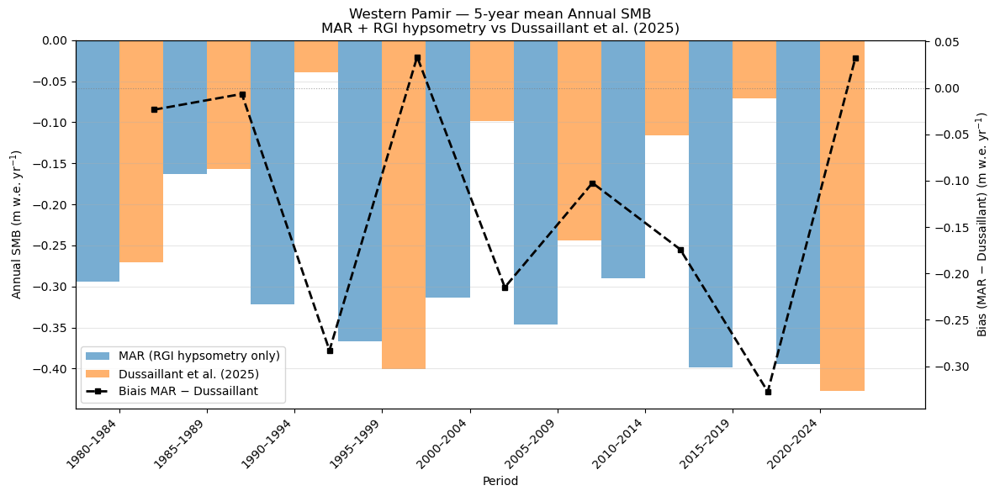

In [95]:
# ============================================================
# 1. MAR : SMB annuel
# ============================================================

yr_start = '1980-01-16T12:00:00.000000000'
yr_stop  = '2024-12-16T12:00:00.000000000'

da = (
    ds_SMB_WP
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="1Y")
    .sum()
)


# ============================================================
# 2. Empilement spatial
# ============================================================

smb_points = da.stack(points=("Y", "X"))

elevation = SH_pamir.stack(points=("Y", "X"))

ice = ICE_pamir.stack(points=("Y", "X"))


# ============================================================
# 3. Garder uniquement les pixels glaciers
#    ICE_pamir sert uniquement à identifier les pixels glaciaires
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation) &
    np.isfinite(ice)
)

smb_points = smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)

ice = ice.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

hyps_rgi = hypsometry_rgi_WP.copy()

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values

dz = 200


# ============================================================
# 5. Classes d'altitude de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (
    bins[:-1] + bins[1:]
) / 2


# ============================================================
# 6. Attribuer chaque pixel MAR à une classe d'altitude
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR moyen dans chaque classe d'altitude
#    SANS PONDÉRATION PAR ICE
# ============================================================

smb_by_altitude = []

for i in range(len(z_center)):

    # Pixels appartenant à la classe
    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(
                smb_points.time.size,
                np.nan
            )
        )

        continue


    # --------------------------------------------------------
    # Sélection des pixels
    # --------------------------------------------------------

    indices = np.where(pixel_class)[0]

    smb_class = smb_points.isel(
        points=indices
    )


    # --------------------------------------------------------
    # Moyenne arithmétique des pixels
    # --------------------------------------------------------
    #
    # Chaque pixel MAR a le même poids.
    #
    # SMB_classe =
    #
    #       SUM(SMB_i)
    #       ------------
    #       N_pixels
    #
    # --------------------------------------------------------

    smb_mean_class = smb_class.mean(
        dim="points",
        skipna=True
    )

    smb_by_altitude.append(
        smb_mean_class.values
    )


smb_by_altitude = np.array(
    smb_by_altitude
)


# ============================================================
# 8. Aligner l'hypsométrie RGI avec les classes MAR
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(
        altitude_rgi[idx] - z
    ) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB annuel régional MAR
#    pondéré UNIQUEMENT par l'hypsométrie RGI
# ============================================================

weighted_smb_mar = []

for t in range(
    smb_points.time.size
):

    smb_t = smb_by_altitude[:, t]

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(
            percentage_rgi_aligned
        )
    )

    weighted_mean = (
        np.sum(
            smb_t[valid]
            *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb_mar.append(
        weighted_mean
    )


weighted_smb_mar = np.array(
    weighted_smb_mar
)


# ============================================================
# 10. Années MAR
# ============================================================

years_mar = np.array([
    pd.Timestamp(t).year
    for t in smb_points.time.values
])


# ============================================================
# 11. DUSSAILLANT — WESTERN PAMIR
# ============================================================

df = dus_df_WP.copy()

yrs = [
    str(y)
    for y in range(1980, 2024)
]


# SMB annuel de chaque glacier
smb_dus = df[yrs]


# Moyenne pondérée par la surface des glaciers
weighted_mean_dus = (
    smb_dus.mul(
        df["area"],
        axis=0
    ).sum(axis=0)
    /
    df["area"].sum()
)


# ============================================================
# 12. MOYENNES PAR PÉRIODE DE 5 ANS
# ============================================================

years_mar_num = np.array([
    int(y) for y in years_mar
])

years_dus_num = np.array([
    int(y) for y in yrs
])


# ------------------------------------------------------------
# DataFrames annuels
# ------------------------------------------------------------

mar_df = pd.DataFrame({
    "year": years_mar_num,
    "MAR": weighted_smb_mar
})

dus_df = pd.DataFrame({
    "year": years_dus_num,
    "Dussaillant": weighted_mean_dus.values
})


# ------------------------------------------------------------
# Fusionner sur les années communes
# ------------------------------------------------------------

comparison = pd.merge(
    mar_df,
    dus_df,
    on="year",
    how="inner"
)


# ------------------------------------------------------------
# Biais annuel
# ------------------------------------------------------------

comparison["bias"] = (
    comparison["MAR"]
    - comparison["Dussaillant"]
)


# ============================================================
# 13. MOYENNE PAR TRANCHES DE 5 ANS
# ============================================================

comparison["period_5y"] = (
    (comparison["year"] // 5) * 5
)


comparison_5y = (
    comparison
    .groupby("period_5y")
    .agg({
        "MAR": "mean",
        "Dussaillant": "mean",
        "bias": "mean"
    })
    .reset_index()
)


# ------------------------------------------------------------
# Centre de chaque période
# ------------------------------------------------------------

comparison_5y["year_center"] = (
    comparison_5y["period_5y"] + 2
)


# ============================================================
# PLOT — MOYENNES SUR 5 ANS
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

x = comparison_5y["period_5y"].values


# ============================================================
# 1. MAR
# ============================================================

ax.bar(
    x - 1.25,
    comparison_5y["MAR"],
    width=2.5,
    alpha=0.6,
    label="MAR (RGI hypsometry only)"
)


# ============================================================
# 2. Dussaillant
# ============================================================

ax.bar(
    x + 1.25,
    comparison_5y["Dussaillant"],
    width=2.5,
    alpha=0.6,
    label="Dussaillant et al. (2025)"
)


# ============================================================
# 3. Ligne SMB = 0
# ============================================================

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ============================================================
# 4. Deuxième axe Y : biais
# ============================================================

ax2 = ax.twinx()

ax2.plot(
    comparison_5y["year_center"],
    comparison_5y["bias"],
    color="black",
    lw=2,
    linestyle="--",
    marker="s",
    markersize=5,
    label="Biais MAR − Dussaillant"
)

ax2.axhline(
    0,
    color="gray",
    lw=0.8,
    linestyle=":",
    alpha=0.7
)


# ============================================================
# 5. Labels
# ============================================================

ax.set_xlabel("Period")

ax.set_ylabel(
    "Annual SMB (m w.e. yr$^{-1}$)"
)

ax2.set_ylabel(
    "Bias (MAR − Dussaillant) "
    "(m w.e. yr$^{-1}$)"
)


# ============================================================
# 6. Axe X
# ============================================================

ax.set_xticks(x)

ax.set_xticklabels(
    [
        f"{int(y)}–{int(y)+4}"
        for y in comparison_5y["period_5y"]
    ],
    rotation=45,
    ha="right"
)


# ============================================================
# 7. Limites X
# ============================================================

ax.set_xlim(
    x.min() - 2.5,
    x.max() + 6
)


# ============================================================
# 8. Titre
# ============================================================

ax.set_title(
    "Western Pamir — 5-year mean Annual SMB\n"
    "MAR + RGI hypsometry vs Dussaillant et al. (2025)"
)


# ============================================================
# 9. Grille
# ============================================================

ax.grid(
    axis="y",
    alpha=0.3
)


# ============================================================
# 10. Légende combinée
# ============================================================

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)


plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


Moyenne du biais : 0.014 m w.e. yr⁻¹
Médiane du biais : 0.003 m w.e. yr⁻¹
Écart-type du biais : 0.323 m w.e. yr⁻¹


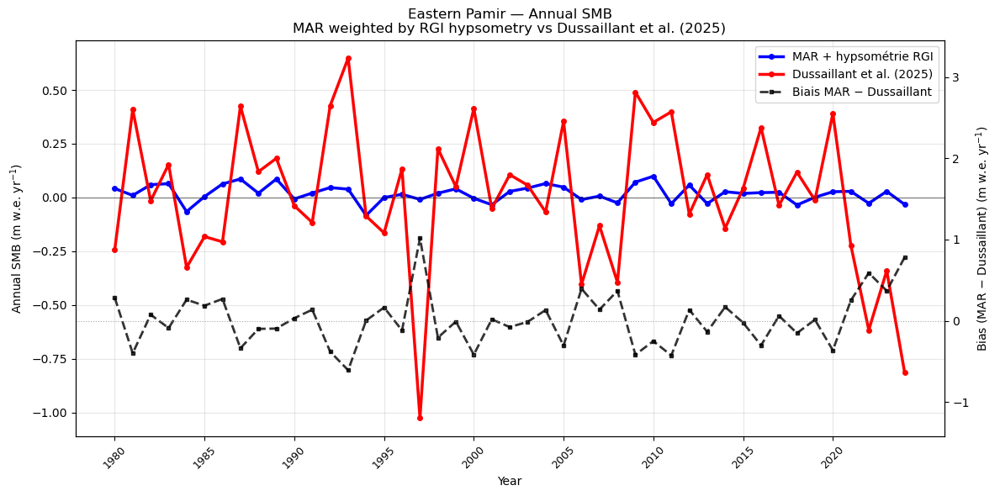

In [96]:
# ============================================================
# 1. MAR : SMB annuel
# ============================================================

yr_start = '1979-10-01T12:00:00.000000000'
yr_stop  = '2024-09-30T12:00:00.000000000'

da = (
    ds_SMB_EP
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="A-SEP")
    .sum()
)


# ============================================================
# 2. Empilement spatial
# ============================================================

smb_points = da.stack(points=("Y", "X"))

elevation = SH_pamir.stack(points=("Y", "X"))
ice = ICE_pamir.stack(points=("Y", "X"))


# ============================================================
# 3. Garder uniquement les pixels glaciers
#    ICE_pamir = masque uniquement, PAS un poids
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation)
)

smb_points = smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

hyps_rgi = hypsometry_rgi_EP.copy()

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values

dz = 200


# ============================================================
# 5. Classes d'altitude de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (bins[:-1] + bins[1:]) / 2


# ============================================================
# 6. Attribuer chaque pixel MAR à une classe d'altitude
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR moyen dans chaque classe d'altitude
# ============================================================

smb_by_altitude = []

for i in range(len(z_center)):

    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(smb_points.time.size, np.nan)
        )

    else:

        smb_class = smb_points.isel(
            points=np.where(pixel_class)[0]
        )

        smb_mean_class = smb_class.mean(
            dim="points",
            skipna=True
        )

        smb_by_altitude.append(
            smb_mean_class.values
        )

smb_by_altitude = np.array(smb_by_altitude)


# ============================================================
# 8. Aligner l'hypsométrie RGI avec les classes MAR
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(altitude_rgi[idx] - z) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB annuel régional MAR pondéré par RGI
# ============================================================

weighted_smb_mar = []

for t in range(smb_points.time.size):

    smb_t = smb_by_altitude[:, t]

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(percentage_rgi_aligned)
    )

    weighted_mean = (
        np.sum(
            smb_t[valid] *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb_mar.append(weighted_mean)

weighted_smb_mar = np.array(weighted_smb_mar)


# ============================================================
# 10. Années MAR
# ============================================================

years_mar = [
    str(pd.Timestamp(t).year)
    for t in smb_points.time.values
]


# ============================================================
# 11. DUSSAILLANT — Eastern PAMIR
# ============================================================

df = dus_df_EP.copy()

yrs = [str(y) for y in range(1980, 2025)]

# SMB annuel de chaque glacier
smb_dus = df[yrs]

# Moyenne pondérée par la surface des glaciers
weighted_mean_dus = (
    smb_dus.mul(
        df["area"],
        axis=0
    ).sum(axis=0)
    /
    df["area"].sum()
)


# ============================================================
# 12. Comparaison MAR vs Dussaillant + biais annuel
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# ------------------------------------------------------------
# Conversion en années numériques
# ------------------------------------------------------------

years_mar_num = np.array([int(y) for y in years_mar])
years_dus_num = np.array([int(y) for y in yrs])


# ------------------------------------------------------------
# 1. MAR + hypsométrie RGI
# ------------------------------------------------------------

ax.plot(
    years_mar_num,
    weighted_smb_mar,
    color="blue",
    lw=2.5,
    marker="o",
    markersize=4,
    label="MAR + hypsométrie RGI"
)


# ------------------------------------------------------------
# 2. Dussaillant
# ------------------------------------------------------------

ax.plot(
    years_dus_num,
    weighted_mean_dus.values,
    color="red",
    lw=2.5,
    marker="o",
    markersize=4,
    label="Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Ligne SMB = 0
# ------------------------------------------------------------

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ------------------------------------------------------------
# 3. Calcul du biais annuel
# ------------------------------------------------------------

common_years = np.intersect1d(
    years_mar_num,
    years_dus_num
)

idx_mar = np.isin(
    years_mar_num,
    common_years
)

idx_dus = np.isin(
    years_dus_num,
    common_years
)

mar_common = weighted_smb_mar[idx_mar]
dus_common = weighted_mean_dus.values[idx_dus]

# Biais = MAR - Dussaillant
bias = mar_common - dus_common


# ------------------------------------------------------------
# 4. Deuxième axe Y
# ------------------------------------------------------------

ax2 = ax.twinx()

ax2.plot(
    common_years,
    bias,
    color="black",
    lw=2,
    linestyle="--",
    marker="s",
    markersize=3,
    alpha=0.8,
    label="Biais MAR − Dussaillant"
)

ax2.axhline(
    0,
    color="gray",
    lw=0.8,
    linestyle=":",
    alpha=0.7
)


# ------------------------------------------------------------
# 5. Décaler visuellement l'échelle du biais vers le bas
# ------------------------------------------------------------

bias_min = np.nanmin(bias)
bias_max = np.nanmax(bias)

# Marge autour du biais
bias_range = bias_max - bias_min

if bias_range == 0:
    bias_range = 1

# On décale la fenêtre du deuxième axe vers le bas
ax2.set_ylim(
    bias_min - 0.5 * bias_range,
    bias_max + 1.5 * bias_range
)


# ------------------------------------------------------------
# Labels des axes
# ------------------------------------------------------------

ax.set_xlabel("Year")

ax.set_ylabel(
    "Annual SMB (m w.e. yr$^{-1}$)"
)

ax2.set_ylabel(
    "Bias (MAR − Dussaillant) "
    "(m w.e. yr$^{-1}$)"
)


# ------------------------------------------------------------
# Ticks de l'axe X
# ------------------------------------------------------------

years_ticks = np.arange(
    1980,
    2025,
    5
)

ax.set_xticks(years_ticks)

ax.tick_params(
    axis="x",
    labelrotation=45,
    labelsize=9
)


# ------------------------------------------------------------
# Titre
# ------------------------------------------------------------

ax.set_title(
    "Eastern Pamir — Annual SMB\n"
    "MAR weighted by RGI hypsometry vs "
    "Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Grille
# ------------------------------------------------------------

ax.grid(
    alpha=0.3
)


# ------------------------------------------------------------
# Légende combinée
# ------------------------------------------------------------

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)

plt.tight_layout()

moyenne_biais = np.nanmean(bias)
mediane_biais = np.nanmedian(bias)
std_dev_biais = np.nanstd(bias)

print(f"Moyenne du biais : {moyenne_biais:.3f} m w.e. yr⁻¹")
print(f"Médiane du biais : {mediane_biais:.3f} m w.e. yr⁻¹")
print(f"Écart-type du biais : {std_dev_biais:.3f} m w.e. yr⁻¹")

plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


Moyenne du biais : -0.202 m w.e. yr⁻¹
Médiane du biais : -0.226 m w.e. yr⁻¹
Écart-type du biais : 0.354 m w.e. yr⁻¹


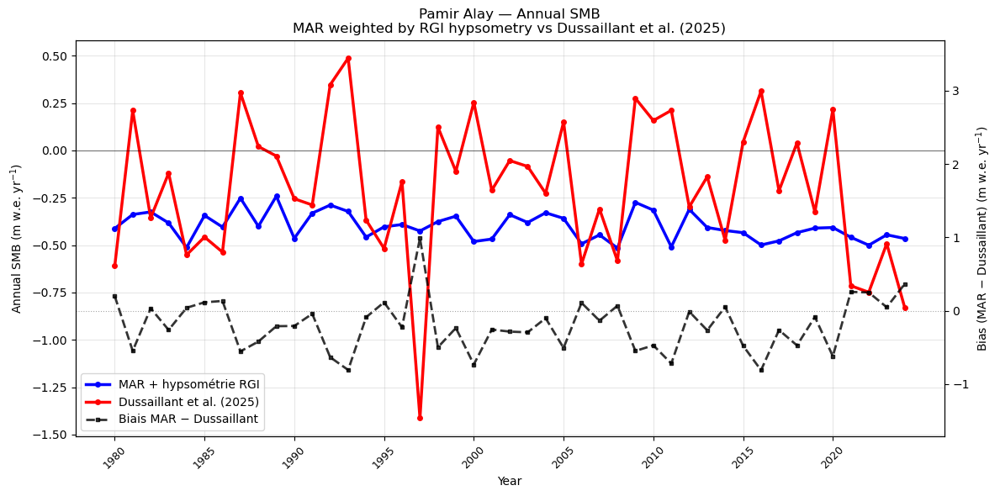

In [97]:
# ============================================================
# 1. MAR : SMB annuel
# ============================================================

yr_start = '1979-10-01T12:00:00.000000000'
yr_stop  = '2024-09-30T12:00:00.000000000'

da = (
    ds_SMB_PA
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="A-SEP")
    .sum()
)


# ============================================================
# 2. Empilement spatial
# ============================================================

smb_points = da.stack(points=("Y", "X"))

elevation = SH_pamir.stack(points=("Y", "X"))
ice = ICE_pamir.stack(points=("Y", "X"))


# ============================================================
# 3. Garder uniquement les pixels glaciers
#    ICE_pamir = masque uniquement, PAS un poids
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation)
)

smb_points = smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

hyps_rgi = hypsometry_rgi_PA.copy()

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values

dz = 200


# ============================================================
# 5. Classes d'altitude de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (bins[:-1] + bins[1:]) / 2


# ============================================================
# 6. Attribuer chaque pixel MAR à une classe d'altitude
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR moyen dans chaque classe d'altitude
# ============================================================

smb_by_altitude = []

for i in range(len(z_center)):

    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(smb_points.time.size, np.nan)
        )

    else:

        smb_class = smb_points.isel(
            points=np.where(pixel_class)[0]
        )

        smb_mean_class = smb_class.mean(
            dim="points",
            skipna=True
        )

        smb_by_altitude.append(
            smb_mean_class.values
        )

smb_by_altitude = np.array(smb_by_altitude)


# ============================================================
# 8. Aligner l'hypsométrie RGI avec les classes MAR
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(altitude_rgi[idx] - z) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB annuel régional MAR pondéré par RGI
# ============================================================

weighted_smb_mar = []

for t in range(smb_points.time.size):

    smb_t = smb_by_altitude[:, t]

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(percentage_rgi_aligned)
    )

    weighted_mean = (
        np.sum(
            smb_t[valid] *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb_mar.append(weighted_mean)

weighted_smb_mar = np.array(weighted_smb_mar)


# ============================================================
# 10. Années MAR
# ============================================================

years_mar = [
    str(pd.Timestamp(t).year)
    for t in smb_points.time.values
]


# ============================================================
# 11. DUSSAILLANT — PAMIR Alay
# ============================================================

df = dus_df_PA.copy()

yrs = [str(y) for y in range(1980, 2025)]

# SMB annuel de chaque glacier
smb_dus = df[yrs]

# Moyenne pondérée par la surface des glaciers
weighted_mean_dus = (
    smb_dus.mul(
        df["area"],
        axis=0
    ).sum(axis=0)
    /
    df["area"].sum()
)


# ============================================================
# 12. Comparaison MAR vs Dussaillant + biais annuel
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# ------------------------------------------------------------
# Conversion en années numériques
# ------------------------------------------------------------

years_mar_num = np.array([int(y) for y in years_mar])
years_dus_num = np.array([int(y) for y in yrs])


# ------------------------------------------------------------
# 1. MAR + hypsométrie RGI
# ------------------------------------------------------------

ax.plot(
    years_mar_num,
    weighted_smb_mar,
    color="blue",
    lw=2.5,
    marker="o",
    markersize=4,
    label="MAR + hypsométrie RGI"
)


# ------------------------------------------------------------
# 2. Dussaillant
# ------------------------------------------------------------

ax.plot(
    years_dus_num,
    weighted_mean_dus.values,
    color="red",
    lw=2.5,
    marker="o",
    markersize=4,
    label="Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Ligne SMB = 0
# ------------------------------------------------------------

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ------------------------------------------------------------
# 3. Calcul du biais annuel
# ------------------------------------------------------------

common_years = np.intersect1d(
    years_mar_num,
    years_dus_num
)

idx_mar = np.isin(
    years_mar_num,
    common_years
)

idx_dus = np.isin(
    years_dus_num,
    common_years
)

mar_common = weighted_smb_mar[idx_mar]
dus_common = weighted_mean_dus.values[idx_dus]

# Biais = MAR - Dussaillant
bias = mar_common - dus_common


# ------------------------------------------------------------
# 4. Deuxième axe Y
# ------------------------------------------------------------

ax2 = ax.twinx()

ax2.plot(
    common_years,
    bias,
    color="black",
    lw=2,
    linestyle="--",
    marker="s",
    markersize=3,
    alpha=0.8,
    label="Biais MAR − Dussaillant"
)

ax2.axhline(
    0,
    color="gray",
    lw=0.8,
    linestyle=":",
    alpha=0.7
)


# ------------------------------------------------------------
# 5. Décaler visuellement l'échelle du biais vers le bas
# ------------------------------------------------------------

bias_min = np.nanmin(bias)
bias_max = np.nanmax(bias)

# Marge autour du biais
bias_range = bias_max - bias_min

if bias_range == 0:
    bias_range = 1

# On décale la fenêtre du deuxième axe vers le bas
ax2.set_ylim(
    bias_min - 0.5 * bias_range,
    bias_max + 1.5 * bias_range
)


# ------------------------------------------------------------
# Labels des axes
# ------------------------------------------------------------

ax.set_xlabel("Year")

ax.set_ylabel(
    "Annual SMB (m w.e. yr$^{-1}$)"
)

ax2.set_ylabel(
    "Bias (MAR − Dussaillant) "
    "(m w.e. yr$^{-1}$)"
)


# ------------------------------------------------------------
# Ticks de l'axe X
# ------------------------------------------------------------

years_ticks = np.arange(
    1980,
    2025,
    5
)

ax.set_xticks(years_ticks)

ax.tick_params(
    axis="x",
    labelrotation=45,
    labelsize=9
)


# ------------------------------------------------------------
# Titre
# ------------------------------------------------------------

ax.set_title(
    "Pamir Alay — Annual SMB\n"
    "MAR weighted by RGI hypsometry vs "
    "Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Grille
# ------------------------------------------------------------

ax.grid(
    alpha=0.3
)


# ------------------------------------------------------------
# Légende combinée
# ------------------------------------------------------------

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)

plt.tight_layout()

moyenne_biais = np.nanmean(bias)
mediane_biais = np.nanmedian(bias)
std_dev_biais = np.nanstd(bias)

print(f"Moyenne du biais : {moyenne_biais:.3f} m w.e. yr⁻¹")
print(f"Médiane du biais : {mediane_biais:.3f} m w.e. yr⁻¹")
print(f"Écart-type du biais : {std_dev_biais:.3f} m w.e. yr⁻¹")

plt.show()

## Comparaison MAR Dussaillant Séries temporelles SMB AVEC PONDERATION ICE pour MAR

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


Biais MAR - Dussaillant (1980–2024)
Nombre d'années : 45
Moyenne    : -0.039 m w.e. yr⁻¹
Médiane    : -0.035 m w.e. yr⁻¹
Écart-type : 0.325 m w.e. yr⁻¹


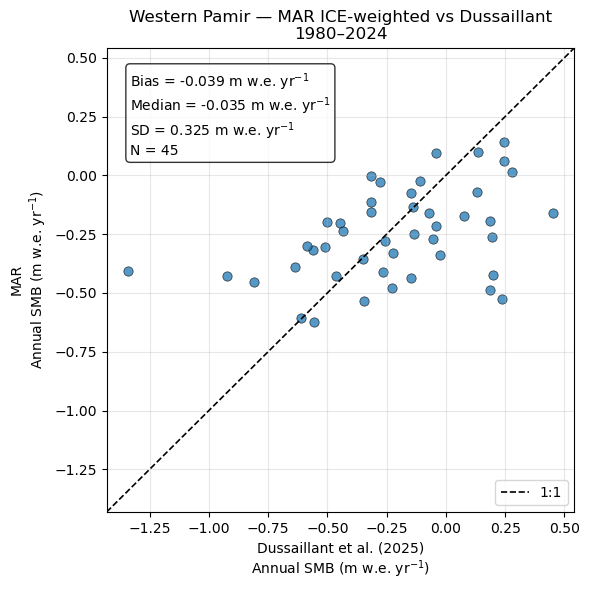

In [94]:
# ============================================================
# 0. INPUTS
# ============================================================

region_name = "Western Pamir"

yr_start = '1980-01-16T12:00:00.000000000'
yr_stop  = '2024-12-16T12:00:00.000000000'

da = ds_SMB_WP
df = dus_df_WP.copy()
hyps_rgi = hypsometry_rgi_WP.copy()

dz = 200


# ============================================================
# 1. DATASET MAR
# ============================================================

da = (
    da
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="A-SEP")
    .sum()
)


# ============================================================
# 2. EMPILEMENT SPATIAL
# ============================================================

smb_points = da.stack(
    points=("Y", "X")
)

elevation = SH_pamir.stack(
    points=("Y", "X")
)

ice = ICE_pamir.stack(
    points=("Y", "X")
)


# ============================================================
# 3. GARDER UNIQUEMENT LES PIXELS GLACIERS
#    ICE_pamir sert de POIDS
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation) &
    np.isfinite(ice)
)

smb_points = smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)

ice = ice.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. HYPSOMÉTRIE RGI
# ============================================================

altitude_rgi = (
    hyps_rgi["altitude_m"].values
)

percentage_rgi = (
    hyps_rgi["percentage_rgi"].values
)


# ============================================================
# 5. CLASSES D'ALTITUDE DE 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (
    bins[:-1] + bins[1:]
) / 2


# ============================================================
# 6. ATTRIBUER CHAQUE PIXEL MAR À UNE CLASSE D'ALTITUDE
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR PAR CLASSE D'ALTITUDE
#    PONDÉRÉ PAR ICE
# ============================================================

smb_mar_by_altitude = []

for i in range(len(z_center)):

    pixel_class = (
        class_index == i
    )

    if not np.any(pixel_class):

        smb_mar_by_altitude.append(
            np.full(
                smb_points.time.size,
                np.nan
            )
        )

        continue


    # --------------------------------------------------------
    # Sélection des pixels
    # --------------------------------------------------------

    indices = np.where(
        pixel_class
    )[0]

    smb_class = smb_points.isel(
        points=indices
    )

    ice_class = ice.isel(
        points=indices
    )


    # --------------------------------------------------------
    # Moyenne pondérée par ICE
    # --------------------------------------------------------

    smb_weighted_class = (
        (smb_class * ice_class).sum(
            dim="points",
            skipna=True
        )
        /
        ice_class.sum(
            dim="points",
            skipna=True
        )
    )


    smb_mar_by_altitude.append(
        smb_weighted_class.values
    )


smb_mar_by_altitude = np.array(
    smb_mar_by_altitude
)


# ============================================================
# 8. ALIGNEMENT DE L'HYPSOMÉTRIE RGI
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(
            altitude_rgi - z
        )
    )

    if np.abs(
        altitude_rgi[idx] - z
    ) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB ANNUEL RÉGIONAL MAR
#    PONDÉRÉ PAR L'HYPSOMÉTRIE RGI
# ============================================================

weighted_smb_mar = []

for t in range(
    smb_points.time.size
):

    smb_t = (
        smb_mar_by_altitude[:, t]
    )

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(
            percentage_rgi_aligned
        )
    )

    weighted_mean = (
        np.sum(
            smb_t[valid]
            *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb_mar.append(
        weighted_mean
    )


weighted_smb_mar = np.array(
    weighted_smb_mar
)


# ============================================================
# 10. ANNÉES MAR
# ============================================================

years_mar = np.array([
    pd.Timestamp(t).year
    for t in smb_points.time.values
])


# ============================================================
# 11. DUSSAILLANT
# ============================================================

year_1 = pd.Timestamp(
    yr_start
).year

year_2 = pd.Timestamp(
    yr_stop
).year + 1


yrs = [
    str(y)
    for y in range(
        year_1,
        year_2
    )
]


# ------------------------------------------------------------
# Garder uniquement les années disponibles dans df
# ------------------------------------------------------------

yrs = [
    y for y in yrs
    if y in df.columns
]


# ============================================================
# 12. SMB ANNUEL DE CHAQUE GLACIER
# ============================================================

smb_dus = df[yrs]


# ============================================================
# 13. SMB DUSSAILLANT RÉGIONAL
#     PONDÉRÉ PAR LA SURFACE
# ============================================================

weighted_mean_dus = (
    smb_dus
    .mul(
        df["area"],
        axis=0
    )
    .sum(
        axis=0
    )
    /
    df["area"].sum()
)


# ============================================================
# 14. ANNÉES DUSSAILLANT
# ============================================================

years_dus_num = np.array([
    int(y)
    for y in yrs
])


# ============================================================
# 15. ANNÉES COMMUNES
# ============================================================

common_years = np.intersect1d(
    years_mar,
    years_dus_num
)


# ============================================================
# 16. EXTRAIRE LES VALEURS CORRESPONDANTES
# ============================================================

idx_mar = np.isin(
    years_mar,
    common_years
)

idx_dus = np.isin(
    years_dus_num,
    common_years
)


mar_common = (
    weighted_smb_mar[idx_mar]
)

dus_common = (
    weighted_mean_dus.values[idx_dus]
)


# ============================================================
# 17. RETIRER LES NaN
# ============================================================

valid = (
    np.isfinite(mar_common) &
    np.isfinite(dus_common)
)

mar_valid = (
    mar_common[valid]
)

dus_valid = (
    dus_common[valid]
)

years_valid = (
    common_years[valid]
)


# ============================================================
# 18. CALCUL DU BIAIS
# ============================================================

# Biais = MAR - Dussaillant

bias = (
    mar_valid -
    dus_valid
)


# ============================================================
# 19. STATISTIQUES DU BIAIS
# ============================================================

bias_mean = np.mean(
    bias
)

bias_median = np.median(
    bias
)

bias_std = np.std(
    bias,
    ddof=1
)


print(
    "============================================================"
)

print(
    f"Biais MAR - Dussaillant "
    f"({years_valid.min()}–{years_valid.max()})"
)

print(
    f"Nombre d'années : {len(bias)}"
)

print(
    f"Moyenne    : "
    f"{bias_mean:.3f} m w.e. yr⁻¹"
)

print(
    f"Médiane    : "
    f"{bias_median:.3f} m w.e. yr⁻¹"
)

print(
    f"Écart-type : "
    f"{bias_std:.3f} m w.e. yr⁻¹"
)

print(
    "============================================================"
)


# ============================================================
# 20. FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 6)
)


# ============================================================
# 21. SCATTER MAR vs DUSSAILLANT
# ============================================================

ax.scatter(
    dus_valid,
    mar_valid,
    s=45,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.5
)


# ============================================================
# 22. DROITE 1:1
# ============================================================

min_val = min(
    np.nanmin(dus_valid),
    np.nanmin(mar_valid)
)

max_val = max(
    np.nanmax(dus_valid),
    np.nanmax(mar_valid)
)


margin = 0.05 * (
    max_val - min_val
)

line_min = (
    min_val - margin
)

line_max = (
    max_val + margin
)


ax.plot(
    [line_min, line_max],
    [line_min, line_max],
    color="black",
    linestyle="--",
    lw=1.2,
    label="1:1"
)


# ============================================================
# 23. LABELS
# ============================================================

ax.set_xlabel(
    "Dussaillant et al. (2025)\n"
    "Annual SMB (m w.e. yr$^{-1}$)"
)

ax.set_ylabel(
    "MAR\n"
    "Annual SMB (m w.e. yr$^{-1}$)"
)


# ============================================================
# 24. MÊMES LIMITES X ET Y
# ============================================================

ax.set_xlim(
    line_min,
    line_max
)

ax.set_ylim(
    line_min,
    line_max
)


# ============================================================
# 25. STATISTIQUES SUR LE GRAPH
# ============================================================

ax.text(
    0.05,
    0.95,

    f"Bias = "
    f"{bias_mean:.3f} m w.e. yr$^{{-1}}$\n"

    f"Median = "
    f"{bias_median:.3f} m w.e. yr$^{{-1}}$\n"

    f"SD = "
    f"{bias_std:.3f} m w.e. yr$^{{-1}}$\n"

    f"N = {len(bias)}",

    transform=ax.transAxes,

    verticalalignment="top",

    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.8
    )
)


# ============================================================
# 26. TITRE
# ============================================================

ax.set_title(
    f"{region_name} — MAR ICE-weighted vs Dussaillant\n"
    f"{years_valid.min()}–{years_valid.max()}"
)


# ============================================================
# 27. GRILLE
# ============================================================

ax.grid(
    alpha=0.3
)


# ============================================================
# 28. LÉGENDE
# ============================================================

ax.legend(
    loc="lower right"
)


# ============================================================
# 29. AFFICHAGE
# ============================================================

plt.tight_layout()
plt.show()


/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


Biais MAR - Dussaillant (1980–2024)
Nombre d'années : 45
Moyenne   : -0.039 m w.e. yr⁻¹
Médiane   : -0.035 m w.e. yr⁻¹
Écart-type : 0.325 m w.e. yr⁻¹


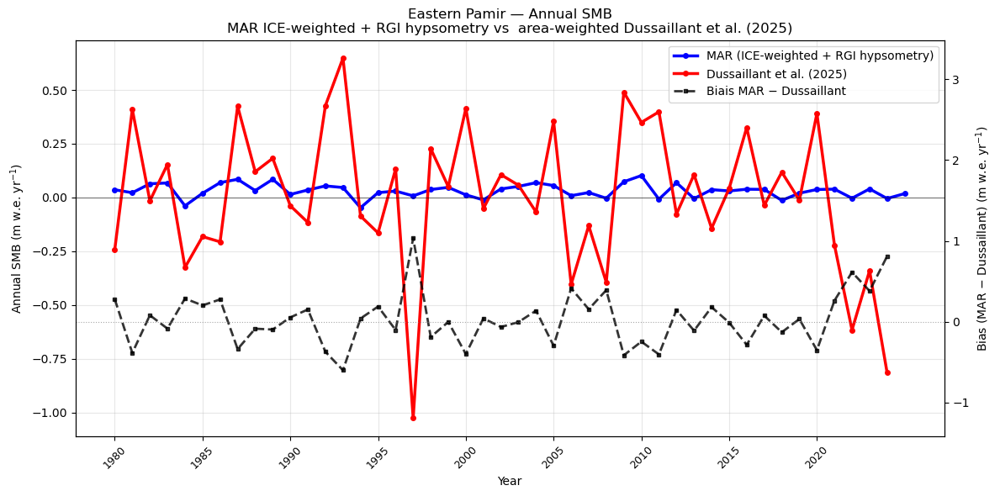

In [88]:
# ============================================================
# 0. INPUTS
# ============================================================

region_name = "Eastern Pamir"

yr_start = '1980-01-16T12:00:00.000000000'
yr_stop  = '2024-12-16T12:00:00.000000000'

da =  ds_SMB_EP
df = dus_df_EP.copy()
hyps_rgi = hypsometry_rgi_EP.copy()

# ============================================================
# 1. Dataset MAR
# ============================================================

da = (
    da
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="A-SEP")
    .sum()
)

# ============================================================
# 2. Empilement spatial
# ============================================================

smb_points = da.stack(points=("Y", "X"))

elevation = SH_pamir.stack(points=("Y", "X"))

ice = ICE_pamir.stack(points=("Y", "X"))


# ============================================================
# 3. Garder uniquement les pixels glaciers
#    ICE_pamir sert maintenant de POIDS
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation) &
    np.isfinite(ice)
)

smb_points = smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)

ice = ice.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

#hyps_rgi = hypsometry_rgi_WP.copy()

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values

dz = 200


# ============================================================
# 5. Classes d'altitude de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (
    bins[:-1] + bins[1:]
) / 2


# ============================================================
# 6. Attribuer chaque pixel MAR à une classe d'altitude
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR moyen dans chaque classe d'altitude
#    PONDÉRÉ PAR ICE
# ============================================================

smb_by_altitude = []

for i in range(len(z_center)):

    # Pixels appartenant à la classe
    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(
                smb_points.time.size,
                np.nan
            )
        )

        continue


    # --------------------------------------------------------
    # Sélection des pixels
    # --------------------------------------------------------

    indices = np.where(pixel_class)[0]

    smb_class = smb_points.isel(
        points=indices
    )

    ice_class = ice.isel(
        points=indices
    )


    # --------------------------------------------------------
    # Moyenne pondérée par la fraction de glace
    # --------------------------------------------------------
    #
    # ICE_pamir est la fraction de la cellule occupée
    # par la glace.
    #
    # Les cellules avec davantage de glace ont donc
    # davantage de poids dans le SMB de la classe.
    #
    # SMB_classe =
    #
    #       SUM(SMB_i × ICE_i)
    #       ------------------
    #          SUM(ICE_i)
    #
    # --------------------------------------------------------

    smb_weighted_class = (
        (smb_class * ice_class).sum(
            dim="points",
            skipna=True
        )
        /
        ice_class.sum(
            dim="points",
            skipna=True
        )
    )

    smb_by_altitude.append(
        smb_weighted_class.values
    )


smb_by_altitude = np.array(
    smb_by_altitude
)


# ============================================================
# 8. Aligner l'hypsométrie RGI avec les classes MAR
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(
        altitude_rgi[idx] - z
    ) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB annuel régional MAR
#    pondéré par l'hypsométrie RGI
# ============================================================

weighted_smb_mar = []

for t in range(
    smb_points.time.size
):

    smb_t = smb_by_altitude[:, t]

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(
            percentage_rgi_aligned
        )
    )

    weighted_mean = (
        np.sum(
            smb_t[valid]
            *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb_mar.append(
        weighted_mean
    )


weighted_smb_mar = np.array(
    weighted_smb_mar
)


# ============================================================
# 10. Années MAR
# ============================================================

years_mar = np.array([
    pd.Timestamp(t).year
    for t in smb_points.time.values
])


# ============================================================
# 11. DUSSAILLANT 
# ============================================================

#df = dus_df_WP.copy()


year_1 = pd.Timestamp(yr_start).year
year_2 = pd.Timestamp(yr_stop).year +1

yrs = [
    str(y)
    for y in range(year_1, year_2)
]


# SMB annuel de chaque glacier
smb_dus = df[yrs]


# Moyenne pondérée par la surface des glaciers
weighted_mean_dus = (
    smb_dus.mul(
        df["area"],
        axis=0
    ).sum(axis=0)
    /
    df["area"].sum()
)


# ============================================================
# 12. Comparaison MAR vs Dussaillant + biais annuel
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 6)
)


# ============================================================
# 13. STATISTIQUES DU BIAIS
# ============================================================

# Retirer les NaN éventuels
bias_valid = bias[np.isfinite(bias)]

# Moyenne
bias_mean = np.mean(bias_valid)

# Médiane
bias_median = np.median(bias_valid)

# Écart-type
bias_std = np.std(
    bias_valid,
    ddof=1
)

print(
    "============================================================"
)

print(
    f"Biais MAR - Dussaillant ({common_years.min()}–{common_years.max()})"
)

print(
    f"Nombre d'années : {len(bias_valid)}"
)

print(
    f"Moyenne   : {bias_mean:.3f} m w.e. yr⁻¹"
)

print(
    f"Médiane   : {bias_median:.3f} m w.e. yr⁻¹"
)

print(
    f"Écart-type : {bias_std:.3f} m w.e. yr⁻¹"
)

print(
    "============================================================"
)

# ============================================================
# Conversion années Dussaillant
# ============================================================

years_dus_num = np.array([
    int(y) for y in yrs
])


# ============================================================
# 1. MAR + ICE + hypsométrie RGI
# ============================================================

ax.plot(
    years_mar,
    weighted_smb_mar,
    color="blue",
    lw=2.5,
    marker="o",
    markersize=4,
    label="MAR (ICE-weighted + RGI hypsometry)"
)


# ============================================================
# 2. Dussaillant
# ============================================================

ax.plot(
    years_dus_num,
    weighted_mean_dus.values,
    color="red",
    lw=2.5,
    marker="o",
    markersize=4,
    label="Dussaillant et al. (2025)"
)


# ============================================================
# Ligne SMB = 0
# ============================================================

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ============================================================
# 3. Calcul du biais annuel
# ============================================================

common_years = np.intersect1d(
    years_mar,
    years_dus_num
)

idx_mar = np.isin(
    years_mar,
    common_years
)

idx_dus = np.isin(
    years_dus_num,
    common_years
)

mar_common = weighted_smb_mar[idx_mar]

dus_common = weighted_mean_dus.values[idx_dus]


# Biais = MAR - Dussaillant
bias = (
    mar_common -
    dus_common
)


# ============================================================
# 4. Deuxième axe Y
# ============================================================

ax2 = ax.twinx()

ax2.plot(
    common_years,
    bias,
    color="black",
    lw=2,
    linestyle="--",
    marker="s",
    markersize=3,
    alpha=0.8,
    label="Biais MAR − Dussaillant"
)


# Ligne biais = 0
ax2.axhline(
    0,
    color="gray",
    lw=0.8,
    linestyle=":",
    alpha=0.7
)


# ============================================================
# 5. Décalage de l'échelle du biais
# ============================================================

bias_min = np.nanmin(bias)
bias_max = np.nanmax(bias)

bias_range = bias_max - bias_min

if bias_range == 0:
    bias_range = 1

ax2.set_ylim(
    bias_min - 0.5 * bias_range,
    bias_max + 1.5 * bias_range
)


# ============================================================
# 6. Labels
# ============================================================

ax.set_xlabel(
    "Year"
)

ax.set_ylabel(
    "Annual SMB (m w.e. yr$^{-1}$)"
)

ax2.set_ylabel(
    "Bias (MAR − Dussaillant) "
    "(m w.e. yr$^{-1}$)"
)


# ============================================================
# 7. Axe X
# ============================================================

years_ticks = np.arange(
    1980,
    2025,
    5
)

ax.set_xticks(
    years_ticks
)

ax.tick_params(
    axis="x",
    labelrotation=45,
    labelsize=9
)


# ============================================================
# 8. Titre
# ============================================================

ax.set_title(
    f"{region_name} — Annual SMB\n"
    "MAR ICE-weighted + RGI hypsometry vs "
    " area-weighted Dussaillant et al. (2025)"
)

# ============================================================
# 9. Grille
# ============================================================

ax.grid(
    alpha=0.3
)

# ============================================================
# 10. Légende combinée
# ============================================================

lines1, labels1 = (
    ax.get_legend_handles_labels()
)

lines2, labels2 = (
    ax2.get_legend_handles_labels()
)

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)


plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


Biais MAR - Dussaillant (1980–2024)
Nombre d'années : 45
Moyenne   : 0.027 m w.e. yr⁻¹
Médiane   : 0.032 m w.e. yr⁻¹
Écart-type : 0.330 m w.e. yr⁻¹


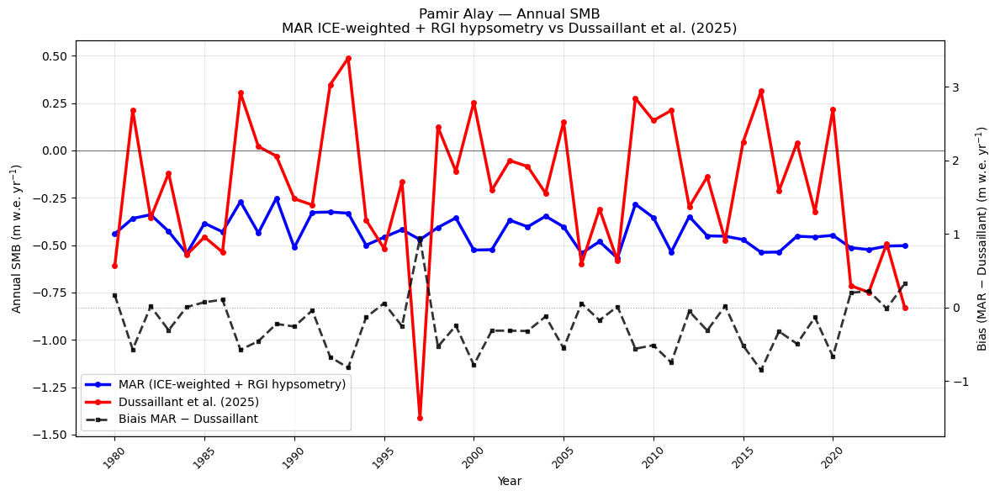

In [89]:
# ============================================================
# 0. INPUTS
# ============================================================

region_name = "Pamir Alay"

yr_start = '1980-01-16T12:00:00.000000000'
yr_stop  = '2024-12-16T12:00:00.000000000'

da =  ds_SMB_PA
df = dus_df_PA.copy()
hyps_rgi = hypsometry_rgi_PA.copy()

# ============================================================
# 1. Dataset MAR
# ============================================================

da = (
    da
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="1Y")
    .sum()
)

# ============================================================
# 2. Empilement spatial
# ============================================================

smb_points = da.stack(points=("Y", "X"))

elevation = SH_pamir.stack(points=("Y", "X"))

ice = ICE_pamir.stack(points=("Y", "X"))


# ============================================================
# 3. Garder uniquement les pixels glaciers
#    ICE_pamir sert maintenant de POIDS
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation) &
    np.isfinite(ice)
)

smb_points = smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)

ice = ice.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

#hyps_rgi = hypsometry_rgi_WP.copy()

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values

dz = 200


# ============================================================
# 5. Classes d'altitude de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (
    bins[:-1] + bins[1:]
) / 2


# ============================================================
# 6. Attribuer chaque pixel MAR à une classe d'altitude
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR moyen dans chaque classe d'altitude
#    PONDÉRÉ PAR ICE
# ============================================================

smb_by_altitude = []

for i in range(len(z_center)):

    # Pixels appartenant à la classe
    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(
                smb_points.time.size,
                np.nan
            )
        )

        continue


    # --------------------------------------------------------
    # Sélection des pixels
    # --------------------------------------------------------

    indices = np.where(pixel_class)[0]

    smb_class = smb_points.isel(
        points=indices
    )

    ice_class = ice.isel(
        points=indices
    )


    # --------------------------------------------------------
    # Moyenne pondérée par la fraction de glace
    # --------------------------------------------------------
    #
    # ICE_pamir est la fraction de la cellule occupée
    # par la glace.
    #
    # Les cellules avec davantage de glace ont donc
    # davantage de poids dans le SMB de la classe.
    #
    # SMB_classe =
    #
    #       SUM(SMB_i × ICE_i)
    #       ------------------
    #          SUM(ICE_i)
    #
    # --------------------------------------------------------

    smb_weighted_class = (
        (smb_class * ice_class).sum(
            dim="points",
            skipna=True
        )
        /
        ice_class.sum(
            dim="points",
            skipna=True
        )
    )

    smb_by_altitude.append(
        smb_weighted_class.values
    )


smb_by_altitude = np.array(
    smb_by_altitude
)


# ============================================================
# 8. Aligner l'hypsométrie RGI avec les classes MAR
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(
        altitude_rgi[idx] - z
    ) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB annuel régional MAR
#    pondéré par l'hypsométrie RGI
# ============================================================

weighted_smb_mar = []

for t in range(
    smb_points.time.size
):

    smb_t = smb_by_altitude[:, t]

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(
            percentage_rgi_aligned
        )
    )

    weighted_mean = (
        np.sum(
            smb_t[valid]
            *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb_mar.append(
        weighted_mean
    )


weighted_smb_mar = np.array(
    weighted_smb_mar
)


# ============================================================
# 10. Années MAR
# ============================================================

years_mar = np.array([
    pd.Timestamp(t).year
    for t in smb_points.time.values
])


# ============================================================
# 11. DUSSAILLANT 
# ============================================================

#df = dus_df_WP.copy()


year_1 = pd.Timestamp(yr_start).year
year_2 = pd.Timestamp(yr_stop).year +1

yrs = [
    str(y)
    for y in range(year_1, year_2)
]


# SMB annuel de chaque glacier
smb_dus = df[yrs]


# Moyenne pondérée par la surface des glaciers
weighted_mean_dus = (
    smb_dus.mul(
        df["area"],
        axis=0
    ).sum(axis=0)
    /
    df["area"].sum()
)


# ============================================================
# 12. Comparaison MAR vs Dussaillant + biais annuel
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 6)
)


# ============================================================
# 13. STATISTIQUES DU BIAIS
# ============================================================

# Retirer les NaN éventuels
bias_valid = bias[np.isfinite(bias)]

# Moyenne
bias_mean = np.mean(bias_valid)

# Médiane
bias_median = np.median(bias_valid)

# Écart-type
bias_std = np.std(
    bias_valid,
    ddof=1
)

print(
    "============================================================"
)

print(
    f"Biais MAR - Dussaillant ({common_years.min()}–{common_years.max()})"
)

print(
    f"Nombre d'années : {len(bias_valid)}"
)

print(
    f"Moyenne   : {bias_mean:.3f} m w.e. yr⁻¹"
)

print(
    f"Médiane   : {bias_median:.3f} m w.e. yr⁻¹"
)

print(
    f"Écart-type : {bias_std:.3f} m w.e. yr⁻¹"
)

print(
    "============================================================"
)

# ============================================================
# Conversion années Dussaillant
# ============================================================

years_dus_num = np.array([
    int(y) for y in yrs
])


# ============================================================
# 1. MAR + ICE + hypsométrie RGI
# ============================================================

ax.plot(
    years_mar,
    weighted_smb_mar,
    color="blue",
    lw=2.5,
    marker="o",
    markersize=4,
    label="MAR (ICE-weighted + RGI hypsometry)"
)


# ============================================================
# 2. Dussaillant
# ============================================================

ax.plot(
    years_dus_num,
    weighted_mean_dus.values,
    color="red",
    lw=2.5,
    marker="o",
    markersize=4,
    label="Dussaillant et al. (2025)"
)


# ============================================================
# Ligne SMB = 0
# ============================================================

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ============================================================
# 3. Calcul du biais annuel
# ============================================================

common_years = np.intersect1d(
    years_mar,
    years_dus_num
)

idx_mar = np.isin(
    years_mar,
    common_years
)

idx_dus = np.isin(
    years_dus_num,
    common_years
)

mar_common = weighted_smb_mar[idx_mar]

dus_common = weighted_mean_dus.values[idx_dus]


# Biais = MAR - Dussaillant
bias = (
    mar_common -
    dus_common
)


# ============================================================
# 4. Deuxième axe Y
# ============================================================

ax2 = ax.twinx()

ax2.plot(
    common_years,
    bias,
    color="black",
    lw=2,
    linestyle="--",
    marker="s",
    markersize=3,
    alpha=0.8,
    label="Biais MAR − Dussaillant"
)


# Ligne biais = 0
ax2.axhline(
    0,
    color="gray",
    lw=0.8,
    linestyle=":",
    alpha=0.7
)


# ============================================================
# 5. Décalage de l'échelle du biais
# ============================================================

bias_min = np.nanmin(bias)
bias_max = np.nanmax(bias)

bias_range = bias_max - bias_min

if bias_range == 0:
    bias_range = 1

ax2.set_ylim(
    bias_min - 0.5 * bias_range,
    bias_max + 1.5 * bias_range
)


# ============================================================
# 6. Labels
# ============================================================

ax.set_xlabel(
    "Year"
)

ax.set_ylabel(
    "Annual SMB (m w.e. yr$^{-1}$)"
)

ax2.set_ylabel(
    "Bias (MAR − Dussaillant) "
    "(m w.e. yr$^{-1}$)"
)


# ============================================================
# 7. Axe X
# ============================================================

years_ticks = np.arange(
    1980,
    2025,
    5
)

ax.set_xticks(
    years_ticks
)

ax.tick_params(
    axis="x",
    labelrotation=45,
    labelsize=9
)


# ============================================================
# 8. Titre
# ============================================================

ax.set_title(
    f"{region_name} — Annual SMB\n"
    "MAR ICE-weighted + RGI hypsometry vs "
    "Dussaillant et al. (2025)"
)

# ============================================================
# 9. Grille
# ============================================================

ax.grid(
    alpha=0.3
)

# ============================================================
# 10. Légende combinée
# ============================================================

lines1, labels1 = (
    ax.get_legend_handles_labels()
)

lines2, labels2 = (
    ax2.get_legend_handles_labels()
)

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)


plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


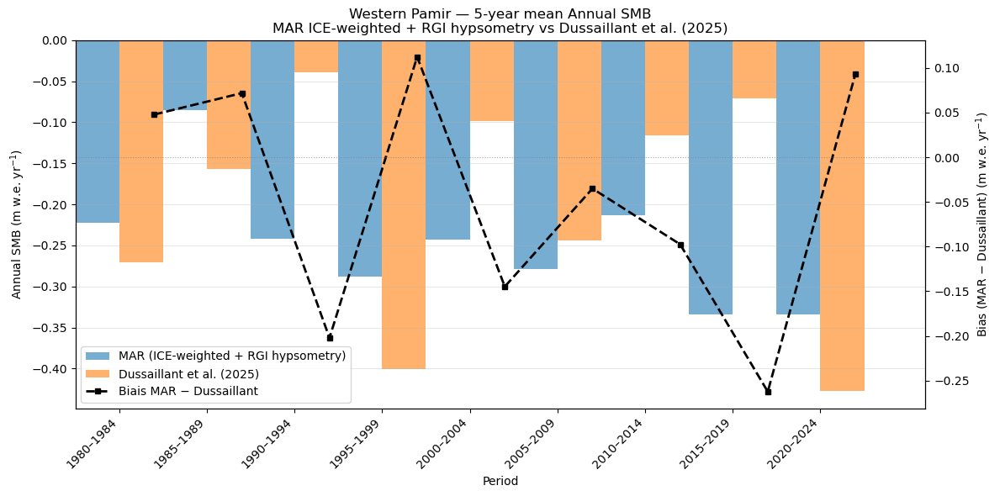

In [90]:
# ============================================================
# 1. MAR : SMB annuel
# ============================================================

yr_start = '1980-01-16T12:00:00.000000000'
yr_stop  = '2024-12-16T12:00:00.000000000'

da = (
    ds_SMB_WP
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="1Y")
    .sum()
)


# ============================================================
# 2. Empilement spatial
# ============================================================

smb_points = da.stack(points=("Y", "X"))

elevation = SH_pamir.stack(points=("Y", "X"))

ice = ICE_pamir.stack(points=("Y", "X"))


# ============================================================
# 3. Garder uniquement les pixels glaciers
#    ICE_pamir sert maintenant de POIDS
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation) &
    np.isfinite(ice)
)

smb_points = smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)

ice = ice.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

hyps_rgi = hypsometry_rgi_WP.copy()

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values

dz = 200


# ============================================================
# 5. Classes d'altitude de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (
    bins[:-1] + bins[1:]
) / 2


# ============================================================
# 6. Attribuer chaque pixel MAR à une classe d'altitude
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR moyen dans chaque classe d'altitude
#    PONDÉRÉ PAR ICE
# ============================================================

smb_by_altitude = []

for i in range(len(z_center)):

    # Pixels appartenant à la classe
    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(
                smb_points.time.size,
                np.nan
            )
        )

        continue


    # --------------------------------------------------------
    # Sélection des pixels
    # --------------------------------------------------------

    indices = np.where(pixel_class)[0]

    smb_class = smb_points.isel(
        points=indices
    )

    ice_class = ice.isel(
        points=indices
    )


    # --------------------------------------------------------
    # Moyenne pondérée par la fraction de glace
    # --------------------------------------------------------
    #
    # ICE_pamir est la fraction de la cellule occupée
    # par la glace.
    #
    # Les cellules avec davantage de glace ont donc
    # davantage de poids dans le SMB de la classe.
    #
    # SMB_classe =
    #
    #       SUM(SMB_i × ICE_i)
    #       ------------------
    #          SUM(ICE_i)
    #
    # --------------------------------------------------------

    smb_weighted_class = (
        (smb_class * ice_class).sum(
            dim="points",
            skipna=True
        )
        /
        ice_class.sum(
            dim="points",
            skipna=True
        )
    )

    smb_by_altitude.append(
        smb_weighted_class.values
    )


smb_by_altitude = np.array(
    smb_by_altitude
)


# ============================================================
# 8. Aligner l'hypsométrie RGI avec les classes MAR
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(
        altitude_rgi[idx] - z
    ) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB annuel régional MAR
#    pondéré par l'hypsométrie RGI
# ============================================================

weighted_smb_mar = []

for t in range(
    smb_points.time.size
):

    smb_t = smb_by_altitude[:, t]

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(
            percentage_rgi_aligned
        )
    )

    weighted_mean = (
        np.sum(
            smb_t[valid]
            *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb_mar.append(
        weighted_mean
    )


weighted_smb_mar = np.array(
    weighted_smb_mar
)


# ============================================================
# 10. Années MAR
# ============================================================

years_mar = np.array([
    pd.Timestamp(t).year
    for t in smb_points.time.values
])


# ============================================================
# 11. DUSSAILLANT — WESTERN PAMIR
# ============================================================

df = dus_df_WP.copy()

yrs = [
    str(y)
    for y in range(1980, 2024)
]


# SMB annuel de chaque glacier
smb_dus = df[yrs]


# Moyenne pondérée par la surface des glaciers
weighted_mean_dus = (
    smb_dus.mul(
        df["area"],
        axis=0
    ).sum(axis=0)
    /
    df["area"].sum()
)

# ============================================================
# 12. MOYENNES PAR PÉRIODE DE 5 ANS
# ============================================================

# ------------------------------------------------------------
# Conversion des années en numériques
# ------------------------------------------------------------

years_mar_num = np.array([
    int(y) for y in years_mar
])

years_dus_num = np.array([
    int(y) for y in yrs
])


# ------------------------------------------------------------
# Construire des DataFrames annuels
# ------------------------------------------------------------

mar_df = pd.DataFrame({
    "year": years_mar_num,
    "MAR": weighted_smb_mar
})

dus_df = pd.DataFrame({
    "year": years_dus_num,
    "Dussaillant": weighted_mean_dus.values
})


# ------------------------------------------------------------
# Fusionner sur les années communes
# ------------------------------------------------------------

comparison = pd.merge(
    mar_df,
    dus_df,
    on="year",
    how="inner"
)


# ------------------------------------------------------------
# Biais annuel
# ------------------------------------------------------------

comparison["bias"] = (
    comparison["MAR"]
    - comparison["Dussaillant"]
)


# ============================================================
# 13. MOYENNE PAR TRANCHES DE 5 ANS
# ============================================================

# Définition des périodes
# 1980-1984
# 1985-1989
# ...
# 2020-2024

comparison["period_5y"] = (
    (comparison["year"] // 5) * 5
)


# ------------------------------------------------------------
# Moyenne des données sur chaque période de 5 ans
# ------------------------------------------------------------

comparison_5y = (
    comparison
    .groupby("period_5y")
    .agg({
        "MAR": "mean",
        "Dussaillant": "mean",
        "bias": "mean"
    })
    .reset_index()
)


# ------------------------------------------------------------
# Centre de chaque période
# ------------------------------------------------------------

comparison_5y["year_center"] = (
    comparison_5y["period_5y"] + 2
)

# ============================================================
# PLOT — MOYENNES SUR 5 ANS EN HISTOGRAMME
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

x = comparison_5y["period_5y"].values


# ============================================================
# 1. MAR
# ============================================================

ax.bar(
    x - 1.25,
    comparison_5y["MAR"],
    width=2.5,
    alpha=0.6,
    label="MAR (ICE-weighted + RGI hypsometry)"
)


# ============================================================
# 2. Dussaillant
# ============================================================

ax.bar(
    x + 1.25,
    comparison_5y["Dussaillant"],
    width=2.5,
    alpha=0.6,
    label="Dussaillant et al. (2025)"
)


# ============================================================
# 3. Ligne SMB = 0
# ============================================================

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ============================================================
# 4. Deuxième axe Y : biais
# ============================================================

ax2 = ax.twinx()

ax2.plot(
    comparison_5y["year_center"],
    comparison_5y["bias"],
    color="black",
    lw=2,
    linestyle="--",
    marker="s",
    markersize=5,
    label="Biais MAR − Dussaillant"
)

ax2.axhline(
    0,
    color="gray",
    lw=0.8,
    linestyle=":",
    alpha=0.7
)


# ============================================================
# 5. Labels
# ============================================================

ax.set_xlabel("Period")
ax.set_ylabel(
    "Annual SMB (m w.e. yr$^{-1}$)"
)

ax2.set_ylabel(
    "Bias (MAR − Dussaillant) "
    "(m w.e. yr$^{-1}$)"
)


# ============================================================
# 6. Axe X
# ============================================================

ax.set_xticks(x)

ax.set_xticklabels(
    [
        f"{int(y)}–{int(y)+4}"
        for y in comparison_5y["period_5y"]
    ],
    rotation=45,
    ha="right"
)


# ============================================================
# 7. Limites X
# ============================================================

ax.set_xlim(
    x.min() - 2.5,
    x.max() + 6
)


# ============================================================
# 8. Titre
# ============================================================

ax.set_title(
    "Western Pamir — 5-year mean Annual SMB\n"
    "MAR ICE-weighted + RGI hypsometry vs "
    "Dussaillant et al. (2025)"
)


# ============================================================
# 9. Grille
# ============================================================

ax.grid(
    axis="y",
    alpha=0.3
)


# ============================================================
# 10. Légende combinée
# ============================================================

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)


plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
/tmp/ipykernel_2580185/3899444417.py:162: RuntimeWarning: Mean of empty slice
  smb_mar_mean_altitude = np.nanmean(


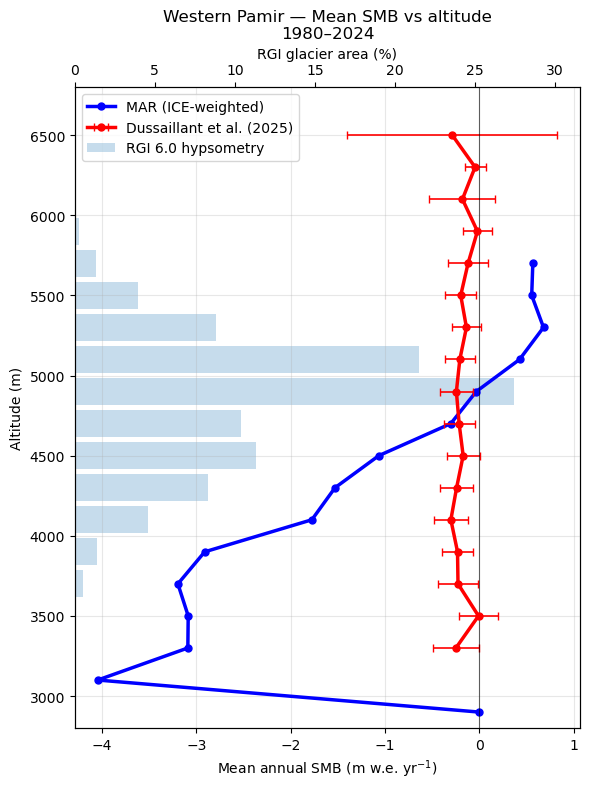

In [91]:
# ============================================================
# 0. INPUTS
# ============================================================

region_name = "Western Pamir"

yr_start = '1980-01-16T12:00:00.000000000'
yr_stop  = '2024-12-16T12:00:00.000000000'

da = ds_SMB_WP
df = dus_df_WP.copy()
hyps_rgi = hypsometry_rgi_WP.copy()

dz = 200


# ============================================================
# 1. DATASET MAR
# ============================================================

da = (
    da
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="1Y")
    .sum()
)


# ============================================================
# 2. EMPILEMENT SPATIAL
# ============================================================

smb_points = da.stack(points=("Y", "X"))

elevation = SH_pamir.stack(points=("Y", "X"))

ice = ICE_pamir.stack(points=("Y", "X"))


# ============================================================
# 3. GARDER UNIQUEMENT LES PIXELS GLACIERS
#    ICE_pamir sert de POIDS
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation) &
    np.isfinite(ice)
)

smb_points = smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)

ice = ice.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. HYPSOMÉTRIE RGI
# ============================================================

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values


# ============================================================
# 5. CLASSES D'ALTITUDE DE 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (
    bins[:-1] + bins[1:]
) / 2


# ============================================================
# 6. ATTRIBUER CHAQUE PIXEL MAR À UNE CLASSE D'ALTITUDE
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR PAR CLASSE D'ALTITUDE
#    PONDÉRÉ PAR ICE
# ============================================================

smb_mar_by_altitude = []

for i in range(len(z_center)):

    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_mar_by_altitude.append(
            np.full(
                smb_points.time.size,
                np.nan
            )
        )

        continue

    indices = np.where(pixel_class)[0]

    smb_class = smb_points.isel(
        points=indices
    )

    ice_class = ice.isel(
        points=indices
    )

    # --------------------------------------------------------
    # Moyenne pondérée par ICE
    # --------------------------------------------------------

    smb_weighted_class = (
        (smb_class * ice_class).sum(
            dim="points",
            skipna=True
        )
        /
        ice_class.sum(
            dim="points",
            skipna=True
        )
    )

    smb_mar_by_altitude.append(
        smb_weighted_class.values
    )


smb_mar_by_altitude = np.array(
    smb_mar_by_altitude
)


# ============================================================
# 8. MOYENNE TEMPORELLE DU SMB MAR
# ============================================================

smb_mar_mean_altitude = np.nanmean(
    smb_mar_by_altitude,
    axis=1
)


# ============================================================
# 9. ALIGNEMENT DE L'HYPSOMÉTRIE RGI
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(
        altitude_rgi[idx] - z
    ) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 10. DUSSAILLANT
# ============================================================

year_1 = pd.Timestamp(yr_start).year
year_2 = pd.Timestamp(yr_stop).year + 1

yrs = [
    str(y)
    for y in range(year_1, year_2)
]

# Garder uniquement les années disponibles
yrs = [
    y for y in yrs
    if y in df.columns
]

smb_dus = df[yrs]


# ============================================================
# 11. SMB MOYEN DE CHAQUE GLACIER SUR 1980–2024
# ============================================================

df["SMB_mean_1980_2024"] = (
    smb_dus.mean(
        axis=1,
        skipna=True
    )
)


# ============================================================
# 12. CLASSER LES GLACIERS DUSSAILLANT PAR Zmed
# ============================================================

class_index_dus = np.digitize(
    df["Zmed"].values,
    bins
) - 1


# ============================================================
# 13. SMB DUSSAILLANT PAR CLASSE D'ALTITUDE
#
#     MOYENNE :
#     pondérée par la surface des glaciers
#
#     ÉCART-TYPE :
#     calculé entre les SMB moyens individuels
#     des glaciers de la classe
# ============================================================

smb_dus_mean_altitude = []
smb_dus_std_altitude = []

for i in range(len(z_center)):

    glacier_class = (
        class_index_dus == i
    )

    if not np.any(glacier_class):

        smb_dus_mean_altitude.append(
            np.nan
        )

        smb_dus_std_altitude.append(
            np.nan
        )

        continue

    df_class = df.loc[
        glacier_class
    ].copy()

    # --------------------------------------------------------
    # SMB moyen 1980–2024 de chaque glacier
    # --------------------------------------------------------

    smb_glacier = df_class[
        "SMB_mean_1980_2024"
    ]

    area_class = df_class[
        "area"
    ]

    # --------------------------------------------------------
    # Garder les glaciers avec SMB et surface valides
    # --------------------------------------------------------

    valid = (
        np.isfinite(smb_glacier) &
        np.isfinite(area_class) &
        (area_class > 0)
    )

    smb_glacier = smb_glacier[valid]
    area_class = area_class[valid]

    if len(smb_glacier) == 0:

        smb_dus_mean_altitude.append(
            np.nan
        )

        smb_dus_std_altitude.append(
            np.nan
        )

        continue


    # ========================================================
    # 13a. MOYENNE SMB DE LA CLASSE
    #      PONDÉRÉE PAR LA SURFACE
    # ========================================================

    smb_weighted = (
        (smb_glacier * area_class).sum()
        /
        area_class.sum()
    )

    smb_dus_mean_altitude.append(
        smb_weighted
    )


    # ========================================================
    # 13b. ÉCART-TYPE ENTRE LES GLACIERS
    #
    #      Chaque glacier = une observation
    # ========================================================

    if len(smb_glacier) > 1:

        smb_std = np.std(
            smb_glacier,
            ddof=1
        )

    else:

        smb_std = np.nan

    smb_dus_std_altitude.append(
        smb_std
    )


smb_dus_mean_altitude = np.array(
    smb_dus_mean_altitude
)

smb_dus_std_altitude = np.array(
    smb_dus_std_altitude
)


# ============================================================
# 14. PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 8)
)


# ============================================================
# 15. HYPSOMÉTRIE RGI EN ARRIÈRE-PLAN
# ============================================================

valid_rgi = np.isfinite(
    percentage_rgi_aligned
)

ax2 = ax.twiny()

ax2.barh(
    z_center[valid_rgi],
    percentage_rgi_aligned[valid_rgi],
    height=dz * 0.85,
    alpha=0.25,
    label="RGI 6.0 hypsometry"
)

ax2.set_xlabel(
    "RGI glacier area (%)"
)

ax2.set_xlim(
    0,
    np.nanmax(
        percentage_rgi_aligned
    ) * 1.15
)

# Mettre l'hypsométrie derrière les courbes
ax.set_zorder(2)
ax2.set_zorder(1)

ax.patch.set_visible(False)


# ============================================================
# 16. PROFIL MAR
# ============================================================

valid_mar = np.isfinite(
    smb_mar_mean_altitude
)

ax.plot(
    smb_mar_mean_altitude[valid_mar],
    z_center[valid_mar],
    color="blue",
    lw=2.5,
    marker="o",
    markersize=5,
    label="MAR (ICE-weighted)"
)


# ============================================================
# 17. PROFIL DUSSAILLANT + ÉCART-TYPE
# ============================================================

valid_dus = (
    np.isfinite(
        smb_dus_mean_altitude
    )
    &
    np.isfinite(
        smb_dus_std_altitude
    )
)

ax.errorbar(
    smb_dus_mean_altitude[valid_dus],
    z_center[valid_dus],
    xerr=smb_dus_std_altitude[valid_dus],
    fmt="o-",
    color="red",
    lw=2.5,
    markersize=5,
    capsize=3,
    elinewidth=1.2,
    label="Dussaillant et al. (2025)"
)


# ============================================================
# 18. SMB = 0
# ============================================================

ax.axvline(
    0,
    color="black",
    lw=0.8,
    alpha=0.6
)


# ============================================================
# 19. LABELS
# ============================================================

ax.set_xlabel(
    "Mean annual SMB (m w.e. yr$^{-1}$)"
)

ax.set_ylabel(
    "Altitude (m)"
)


# ============================================================
# 20. LIMITES ALTITUDE
# ============================================================

ax.set_ylim(
    bins.min(),
    bins.max()
)


# ============================================================
# 21. TITRE
# ============================================================

ax.set_title(
    f"{region_name} — Mean SMB vs altitude\n"
    f"{year_1}–{year_2 - 1}"
)


# ============================================================
# 22. GRILLE
# ============================================================

ax.grid(
    alpha=0.3
)


# ============================================================
# 23. LÉGENDE COMBINÉE
# ============================================================

lines1, labels1 = (
    ax.get_legend_handles_labels()
)

lines2, labels2 = (
    ax2.get_legend_handles_labels()
)

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)


# ============================================================
# 24. AFFICHAGE
# ============================================================

plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


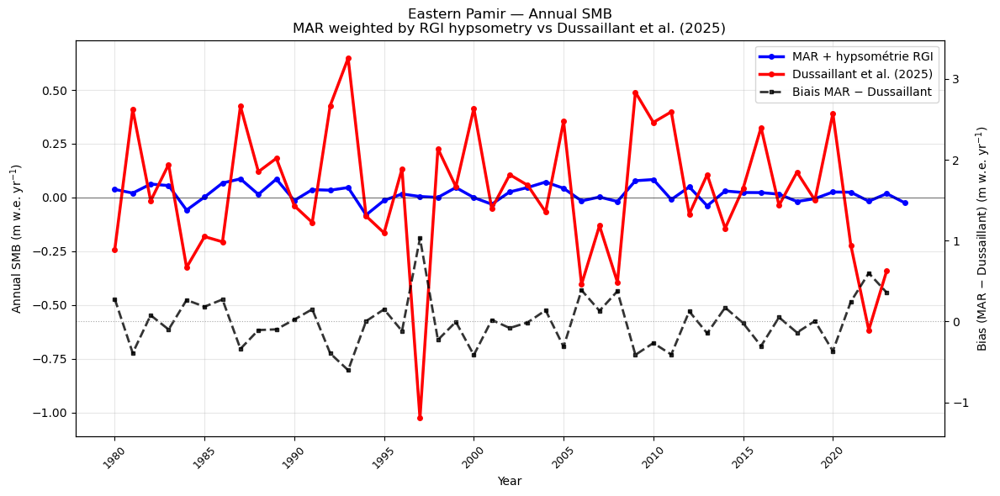

In [92]:
# ============================================================
# 1. MAR : SMB annuel
# ============================================================

yr_start = '1980-01-16T12:00:00.000000000'
yr_stop  = '2024-12-16T12:00:00.000000000'

da = (
    ds_SMB_EP
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="1Y")
    .sum()
)


# ============================================================
# 2. Empilement spatial
# ============================================================

smb_points = da.stack(points=("Y", "X"))

elevation = SH_pamir.stack(points=("Y", "X"))
ice = ICE_pamir.stack(points=("Y", "X"))


# ============================================================
# 3. Garder uniquement les pixels glaciers
#    ICE_pamir = masque uniquement, PAS un poids
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation)
)

smb_points = smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

hyps_rgi = hypsometry_rgi_EP.copy()

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values

dz = 200


# ============================================================
# 5. Classes d'altitude de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (bins[:-1] + bins[1:]) / 2


# ============================================================
# 6. Attribuer chaque pixel MAR à une classe d'altitude
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR moyen dans chaque classe d'altitude
# ============================================================

smb_by_altitude = []

for i in range(len(z_center)):

    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(smb_points.time.size, np.nan)
        )

    else:

        smb_class = smb_points.isel(
            points=np.where(pixel_class)[0]
        )

        smb_mean_class = smb_class.mean(
            dim="points",
            skipna=True
        )

        smb_by_altitude.append(
            smb_mean_class.values
        )

smb_by_altitude = np.array(smb_by_altitude)


# ============================================================
# 8. Aligner l'hypsométrie RGI avec les classes MAR
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(altitude_rgi[idx] - z) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB annuel régional MAR pondéré par RGI
# ============================================================

weighted_smb_mar = []

for t in range(smb_points.time.size):

    smb_t = smb_by_altitude[:, t]

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(percentage_rgi_aligned)
    )

    weighted_mean = (
        np.sum(
            smb_t[valid] *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb_mar.append(weighted_mean)

weighted_smb_mar = np.array(weighted_smb_mar)


# ============================================================
# 10. Années MAR
# ============================================================

years_mar = [
    str(pd.Timestamp(t).year)
    for t in smb_points.time.values
]


# ============================================================
# 11. DUSSAILLANT — Eastern PAMIR
# ============================================================

df = dus_df_EP.copy()

yrs = [str(y) for y in range(1980, 2024)]

# SMB annuel de chaque glacier
smb_dus = df[yrs]

# Moyenne pondérée par la surface des glaciers
weighted_mean_dus = (
    smb_dus.mul(
        df["area"],
        axis=0
    ).sum(axis=0)
    /
    df["area"].sum()
)


# ============================================================
# 12. Comparaison MAR vs Dussaillant + biais annuel
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# ------------------------------------------------------------
# Conversion en années numériques
# ------------------------------------------------------------

years_mar_num = np.array([int(y) for y in years_mar])
years_dus_num = np.array([int(y) for y in yrs])


# ------------------------------------------------------------
# 1. MAR + hypsométrie RGI
# ------------------------------------------------------------

ax.plot(
    years_mar_num,
    weighted_smb_mar,
    color="blue",
    lw=2.5,
    marker="o",
    markersize=4,
    label="MAR + hypsométrie RGI"
)


# ------------------------------------------------------------
# 2. Dussaillant
# ------------------------------------------------------------

ax.plot(
    years_dus_num,
    weighted_mean_dus.values,
    color="red",
    lw=2.5,
    marker="o",
    markersize=4,
    label="Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Ligne SMB = 0
# ------------------------------------------------------------

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ------------------------------------------------------------
# 3. Calcul du biais annuel
# ------------------------------------------------------------

common_years = np.intersect1d(
    years_mar_num,
    years_dus_num
)

idx_mar = np.isin(
    years_mar_num,
    common_years
)

idx_dus = np.isin(
    years_dus_num,
    common_years
)

mar_common = weighted_smb_mar[idx_mar]
dus_common = weighted_mean_dus.values[idx_dus]

# Biais = MAR - Dussaillant
bias = mar_common - dus_common


# ------------------------------------------------------------
# 4. Deuxième axe Y
# ------------------------------------------------------------

ax2 = ax.twinx()

ax2.plot(
    common_years,
    bias,
    color="black",
    lw=2,
    linestyle="--",
    marker="s",
    markersize=3,
    alpha=0.8,
    label="Biais MAR − Dussaillant"
)

ax2.axhline(
    0,
    color="gray",
    lw=0.8,
    linestyle=":",
    alpha=0.7
)


# ------------------------------------------------------------
# 5. Décaler visuellement l'échelle du biais vers le bas
# ------------------------------------------------------------

bias_min = np.nanmin(bias)
bias_max = np.nanmax(bias)

# Marge autour du biais
bias_range = bias_max - bias_min

if bias_range == 0:
    bias_range = 1

# On décale la fenêtre du deuxième axe vers le bas
ax2.set_ylim(
    bias_min - 0.5 * bias_range,
    bias_max + 1.5 * bias_range
)


# ------------------------------------------------------------
# Labels des axes
# ------------------------------------------------------------

ax.set_xlabel("Year")

ax.set_ylabel(
    "Annual SMB (m w.e. yr$^{-1}$)"
)

ax2.set_ylabel(
    "Bias (MAR − Dussaillant) "
    "(m w.e. yr$^{-1}$)"
)


# ------------------------------------------------------------
# Ticks de l'axe X
# ------------------------------------------------------------

years_ticks = np.arange(
    1980,
    2025,
    5
)

ax.set_xticks(years_ticks)

ax.tick_params(
    axis="x",
    labelrotation=45,
    labelsize=9
)


# ------------------------------------------------------------
# Titre
# ------------------------------------------------------------

ax.set_title(
    "Eastern Pamir — Annual SMB\n"
    "MAR weighted by RGI hypsometry vs "
    "Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Grille
# ------------------------------------------------------------

ax.grid(
    alpha=0.3
)


# ------------------------------------------------------------
# Légende combinée
# ------------------------------------------------------------

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)


plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


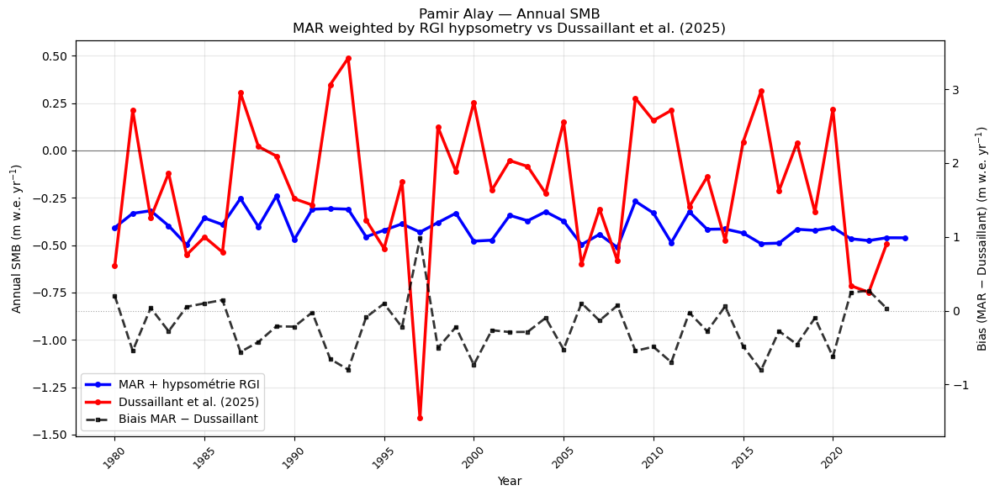

In [93]:
# ============================================================
# 1. MAR : SMB annuel
# ============================================================

yr_start = '1980-01-16T12:00:00.000000000'
yr_stop  = '2024-12-16T12:00:00.000000000'

da = (
    ds_SMB_PA
    .sel(time=slice(yr_start, yr_stop))
    .resample(time="1Y")
    .sum()
)


# ============================================================
# 2. Empilement spatial
# ============================================================

smb_points = da.stack(points=("Y", "X"))

elevation = SH_pamir.stack(points=("Y", "X"))
ice = ICE_pamir.stack(points=("Y", "X"))


# ============================================================
# 3. Garder uniquement les pixels glaciers
#    ICE_pamir = masque uniquement, PAS un poids
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation)
)

smb_points = smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

hyps_rgi = hypsometry_rgi_PA.copy()

altitude_rgi = hyps_rgi["altitude_m"].values
percentage_rgi = hyps_rgi["percentage_rgi"].values

dz = 200


# ============================================================
# 5. Classes d'altitude de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (bins[:-1] + bins[1:]) / 2


# ============================================================
# 6. Attribuer chaque pixel MAR à une classe d'altitude
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR moyen dans chaque classe d'altitude
# ============================================================

smb_by_altitude = []

for i in range(len(z_center)):

    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(smb_points.time.size, np.nan)
        )

    else:

        smb_class = smb_points.isel(
            points=np.where(pixel_class)[0]
        )

        smb_mean_class = smb_class.mean(
            dim="points",
            skipna=True
        )

        smb_by_altitude.append(
            smb_mean_class.values
        )

smb_by_altitude = np.array(smb_by_altitude)


# ============================================================
# 8. Aligner l'hypsométrie RGI avec les classes MAR
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)

for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(altitude_rgi - z)
    )

    if np.abs(altitude_rgi[idx] - z) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB annuel régional MAR pondéré par RGI
# ============================================================

weighted_smb_mar = []

for t in range(smb_points.time.size):

    smb_t = smb_by_altitude[:, t]

    valid = (
        np.isfinite(smb_t) &
        np.isfinite(percentage_rgi_aligned)
    )

    weighted_mean = (
        np.sum(
            smb_t[valid] *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )

    weighted_smb_mar.append(weighted_mean)

weighted_smb_mar = np.array(weighted_smb_mar)


# ============================================================
# 10. Années MAR
# ============================================================

years_mar = [
    str(pd.Timestamp(t).year)
    for t in smb_points.time.values
]


# ============================================================
# 11. DUSSAILLANT — PAMIR Alay
# ============================================================

df = dus_df_PA.copy()

yrs = [str(y) for y in range(1980, 2024)]

# SMB annuel de chaque glacier
smb_dus = df[yrs]

# Moyenne pondérée par la surface des glaciers
weighted_mean_dus = (
    smb_dus.mul(
        df["area"],
        axis=0
    ).sum(axis=0)
    /
    df["area"].sum()
)


# ============================================================
# 12. Comparaison MAR vs Dussaillant + biais annuel
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# ------------------------------------------------------------
# Conversion en années numériques
# ------------------------------------------------------------

years_mar_num = np.array([int(y) for y in years_mar])
years_dus_num = np.array([int(y) for y in yrs])


# ------------------------------------------------------------
# 1. MAR + hypsométrie RGI
# ------------------------------------------------------------

ax.plot(
    years_mar_num,
    weighted_smb_mar,
    color="blue",
    lw=2.5,
    marker="o",
    markersize=4,
    label="MAR + hypsométrie RGI"
)


# ------------------------------------------------------------
# 2. Dussaillant
# ------------------------------------------------------------

ax.plot(
    years_dus_num,
    weighted_mean_dus.values,
    color="red",
    lw=2.5,
    marker="o",
    markersize=4,
    label="Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Ligne SMB = 0
# ------------------------------------------------------------

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ------------------------------------------------------------
# 3. Calcul du biais annuel
# ------------------------------------------------------------

common_years = np.intersect1d(
    years_mar_num,
    years_dus_num
)

idx_mar = np.isin(
    years_mar_num,
    common_years
)

idx_dus = np.isin(
    years_dus_num,
    common_years
)

mar_common = weighted_smb_mar[idx_mar]
dus_common = weighted_mean_dus.values[idx_dus]

# Biais = MAR - Dussaillant
bias = mar_common - dus_common


# ------------------------------------------------------------
# 4. Deuxième axe Y
# ------------------------------------------------------------

ax2 = ax.twinx()

ax2.plot(
    common_years,
    bias,
    color="black",
    lw=2,
    linestyle="--",
    marker="s",
    markersize=3,
    alpha=0.8,
    label="Biais MAR − Dussaillant"
)

ax2.axhline(
    0,
    color="gray",
    lw=0.8,
    linestyle=":",
    alpha=0.7
)


# ------------------------------------------------------------
# 5. Décaler visuellement l'échelle du biais vers le bas
# ------------------------------------------------------------

bias_min = np.nanmin(bias)
bias_max = np.nanmax(bias)

# Marge autour du biais
bias_range = bias_max - bias_min

if bias_range == 0:
    bias_range = 1

# On décale la fenêtre du deuxième axe vers le bas
ax2.set_ylim(
    bias_min - 0.5 * bias_range,
    bias_max + 1.5 * bias_range
)


# ------------------------------------------------------------
# Labels des axes
# ------------------------------------------------------------

ax.set_xlabel("Year")

ax.set_ylabel(
    "Annual SMB (m w.e. yr$^{-1}$)"
)

ax2.set_ylabel(
    "Bias (MAR − Dussaillant) "
    "(m w.e. yr$^{-1}$)"
)


# ------------------------------------------------------------
# Ticks de l'axe X
# ------------------------------------------------------------

years_ticks = np.arange(
    1980,
    2025,
    5
)

ax.set_xticks(years_ticks)

ax.tick_params(
    axis="x",
    labelrotation=45,
    labelsize=9
)


# ------------------------------------------------------------
# Titre
# ------------------------------------------------------------

ax.set_title(
    "Pamir Alay — Annual SMB\n"
    "MAR weighted by RGI hypsometry vs "
    "Dussaillant et al. (2025)"
)


# ------------------------------------------------------------
# Grille
# ------------------------------------------------------------

ax.grid(
    alpha=0.3
)


# ------------------------------------------------------------
# Légende combinée
# ------------------------------------------------------------

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)


plt.tight_layout()
plt.show()

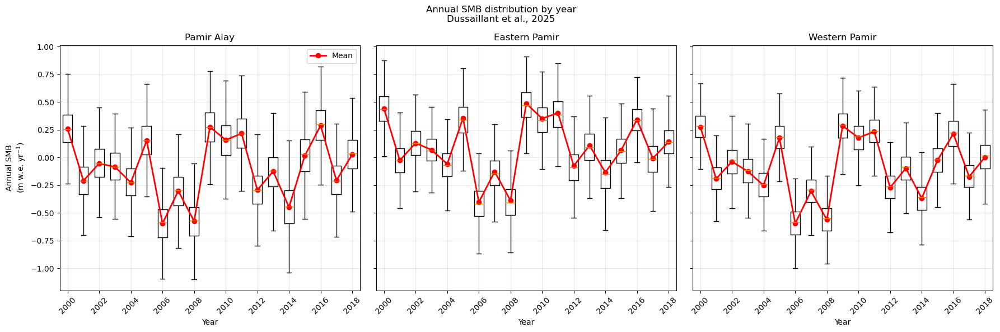

In [94]:
df_list = [
    dus_df_PA,
    dus_df_EP,
    dus_df_WP
]
region_names = [
    "Pamir Alay",
    "Eastern Pamir",
    "Western Pamir"
]
years = [str(y) for y in range(2000, 2019)]

# ==========================
# Figure
# ==========================
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6),
    sharey=True
)

for ax, df, region in zip(
        axes,
        df_list,
        region_names):
    
    df = df.copy()
    
    # --------------------------
    # données pour boxplot
    # --------------------------
    box_data = []

    for year in years:
        values = (
            df[year]
            .dropna()
            .values
        )

        box_data.append(values)

    # --------------------------
    # Boxplots temporels
    # --------------------------
    positions = np.arange(len(years))
    
    ax.boxplot(
        box_data,
        positions=positions,
        widths=0.6,
        showfliers=False
    )
    
    # --------------------------
    # moyenne annuelle
    # --------------------------
    mean_smb = [
        df[y].mean()
        for y in years
    ]

    ax.plot(
        positions,
        mean_smb,
        color="red",
        marker="o",
        lw=2,
        label="Mean"
    )

    # --------------------------
    # Mise en forme
    # --------------------------
    ax.set_title(region)
    ax.set_xlabel("Year")
    ax.set_xticks(
        positions[::2]
    )
    ax.set_xticklabels(
        years[::2],
        rotation=45
    )
    ax.grid(alpha=0.3)

axes[0].set_ylabel(
    "Annual SMB\n(m w.e. yr$^{-1}$)"
)

axes[0].legend()
plt.suptitle(
    "Annual SMB distribution by year\nDussaillant et al., 2025"
)
plt.tight_layout()
plt.show()

# Ca ne veut pas dire grand chose car je considere au meme niveau ds mon calcul de distribution des glaciers de tailles très différentes

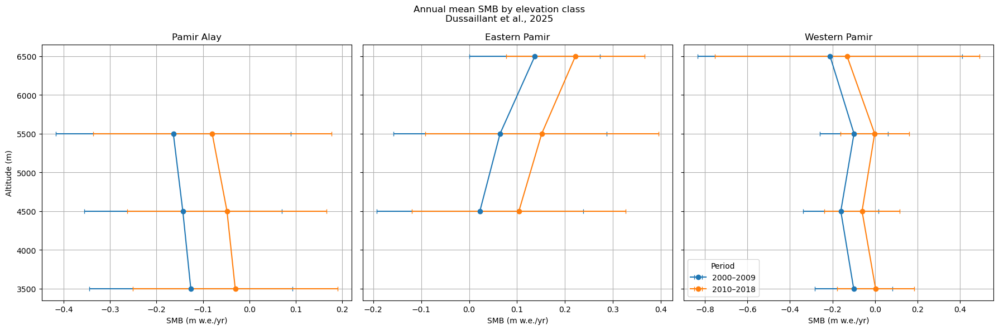

In [95]:
df_list = [
    dus_df_PA,
    dus_df_EP,
    dus_df_WP
]

region_names = [
    "Pamir Alay",
    "Eastern Pamir",
    "Western Pamir"
]

# Classes d'altitude
elev_bins = [3000, 4000, 5000, 6000, 7000]

elev_bin_labels = [
    "3000-4000 m",
    "4000-5000 m",
    "5000-6000 m",
    "6000-7000 m"
]

# centre des classes d'altitude
elev_centers = np.array([
    (elev_bins[i] + elev_bins[i+1]) / 2
    for i in range(len(elev_bins)-1)
])


fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6),
    sharey=True
)


for i, df in enumerate(df_list):

    df = df.copy()

    # ----------------------------
    # Création des classes d'altitude
    # ----------------------------
    df["elev_bin"] = pd.cut(
        df["Zmed"],
        bins=elev_bins,
        labels=elev_bin_labels,
        include_lowest=True
    )

    # ----------------------------
    # Moyenne et écart-type par classe
    # ----------------------------
    stats = (
        df.groupby(
            "elev_bin",
            observed=False
        )[[
            "2000_2009_mean",
            "2010_2018_mean"
        ]]
        .agg(["mean", "std"])
    )

    # enlever les classes sans données
    stats = stats.dropna(how="all")


    ax = axes[i]


    # récupérer les centres d'altitude correspondant
    y = []

    for label in stats.index:
        idx = elev_bin_labels.index(label)
        y.append(elev_centers[idx])

    y = np.array(y)


    # ----------------------------
    # Période 2000-2009
    # ----------------------------
    x1 = stats[("2000_2009_mean", "mean")]
    x1_err = stats[("2000_2009_mean", "std")]

    ax.errorbar(
        x1,
        y,
        xerr=x1_err,
        fmt="-o",
        capsize=3,
        label="2000–2009"
    )


    # ----------------------------
    # Période 2010-2018
    # ----------------------------
    x2 = stats[("2010_2018_mean", "mean")]
    x2_err = stats[("2010_2018_mean", "std")]

    ax.errorbar(
        x2,
        y,
        xerr=x2_err,
        fmt="-o",
        capsize=3,
        label="2010–2018"
    )


    ax.set_title(region_names[i])
    ax.set_xlabel("SMB (m w.e./yr)")
    ax.grid(True)


axes[0].set_ylabel("Altitude (m)")

axes[2].legend(title="Period")


plt.suptitle(
    "Annual mean SMB by elevation class\nDussaillant et al., 2025"
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2580185/3982504194.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("elev_bin")[years]


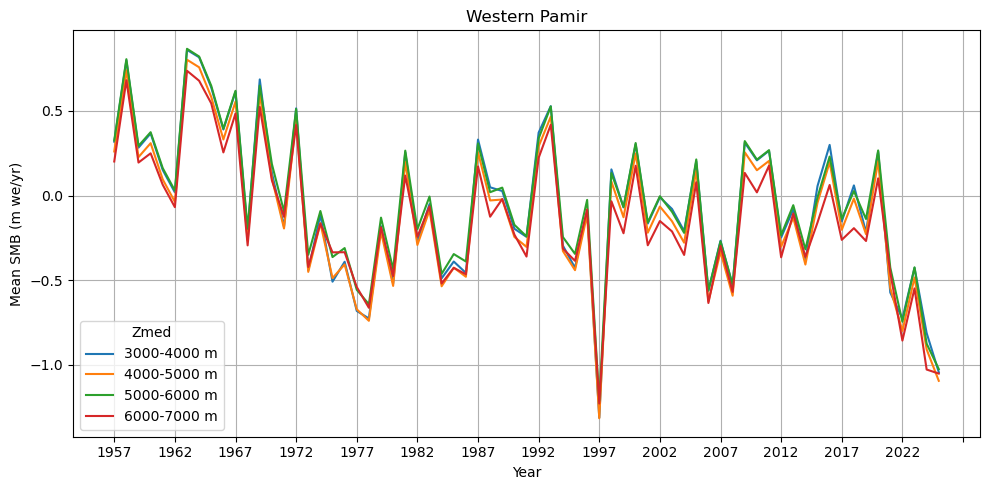

In [96]:
df = dus_df_WP.copy()

elev_bins = [3000, 4000, 5000, 6000, 7000]
elev_bin_labels = [
    "3000-4000 m",
    "4000-5000 m",
    "5000-6000 m",
    "6000-7000 m"
]

df["elev_bin"] = pd.cut(
    df["Zmed"],
    bins=elev_bins,
    labels=elev_bin_labels
)

years = [str(y) for y in range(1957, 2026)]

mean_by_elev = (
    df.groupby("elev_bin")[years]
    .mean()
)


plt.figure(figsize=(10,5))

for elev_class in mean_by_elev.index:
    plt.plot(
        years,
        mean_by_elev.loc[elev_class],
        label=elev_class
    )

plt.xlabel("Year")
plt.ylabel("Mean SMB (m we/yr)")
plt.title("Western Pamir")
plt.legend(title="Zmed")
plt.grid()
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.tight_layout()
plt.show()

#Incorrect, il faudrait 

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(


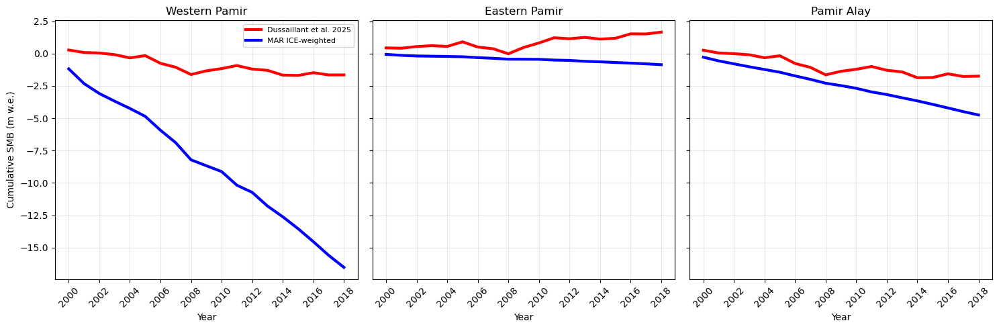

In [97]:
ds_dus_list = [dus_df_WP, dus_df_EP, dus_df_PA]
ds_mar_list = [ds_SMB_WP, ds_SMB_EP, ds_SMB_PA]

titles = [
    'Western Pamir',
    'Eastern Pamir',
    'Pamir Alay'
]

years = list(range(2000, 2019))
cols = [str(y) for y in years]

yr_start_mar = '1999-09-01T12:00:00'
yr_stop_mar  = '2018-08-31T12:00:00'

fig, axes = plt.subplots(
    1, 3,
    figsize=(15,5),
    sharex=True,
    sharey=True
)

weights = ICE_pamir.fillna(0)

for ax, df, ds, title in zip(
        axes,
        ds_dus_list,
        ds_mar_list,
        titles):

    # ==========================
    # Dussaillant
    # ==========================
    cum_dus = df[cols].cumsum(axis=1)
    
    ax.plot(
        years,
        cum_dus.mean(axis=0),
        color='red',
        lw=3,
        label='Dussaillant et al. 2025'
    )

    # ==========================
    # MAR
    # ==========================
    mar = (
        ds
        .sel(
            time=slice(
                yr_start_mar,
                yr_stop_mar
            )
        )
        .resample(time="A-AUG")
        .sum()
    )

    mar_cum = mar.cumsum(dim="time")

    mar_mean = (
        mar_cum
        .weighted(weights)
        .mean(dim=("Y","X"))
    )

    ax.plot(
        mar_mean.time.dt.year,
        mar_mean,
        color='blue',
#        linestyle='--',
        lw=3,
        label='MAR ICE-weighted'
    )

    # ==========================
    # Mise en forme
    # ==========================
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_xticks(
        np.arange(2000, 2019, 2)     # ticks tous les 2 ans
    )
    ax.set_xticklabels(
        np.arange(2000, 2019, 2),
        rotation=45
    )
    ax.grid(alpha=0.3)

axes[0].set_ylabel(
    "Cumulative SMB (m w.e.)"
)

axes[0].legend(
    fontsize=8
)

plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(


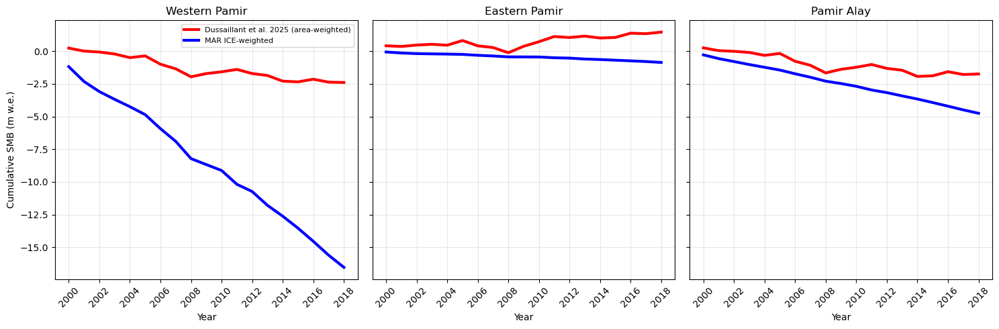

In [98]:
ds_dus_list = [dus_df_WP, dus_df_EP, dus_df_PA]
ds_mar_list = [ds_SMB_WP, ds_SMB_EP, ds_SMB_PA]

titles = [
    'Western Pamir',
    'Eastern Pamir',
    'Pamir Alay'
]

years = list(range(2000, 2019))
cols = [str(y) for y in years]

yr_start_mar = '1999-09-01T12:00:00'
yr_stop_mar  = '2018-08-31T12:00:00'

fig, axes = plt.subplots(
    1, 3,
    figsize=(15,5),
    sharex=True,
    sharey=True
)

weights = ICE_pamir.fillna(0)

for ax, df, ds, title in zip(
        axes,
        ds_dus_list,
        ds_mar_list,
        titles):

    # ==========================
    # Dussaillant
    # ==========================

    # SMB cumulatif pour chaque glacier
    cum_dus = df[cols].cumsum(axis=1)

    # Pondération par la surface du glacier
    area_weights = df["area"]

    # Moyenne régionale pondérée par la surface
    cum_dus_weighted = (
        cum_dus
        .mul(area_weights, axis=0)
        .sum(axis=0)
        / area_weights.sum()
    )

    ax.plot(
        years,
        cum_dus_weighted,
        color='red',
        lw=3,
        label='Dussaillant et al. 2025 (area-weighted)'
    )

    # ==========================
    # MAR
    # ==========================

    mar = (
        ds
        .sel(
            time=slice(
                yr_start_mar,
                yr_stop_mar
            )
        )
        .resample(time="A-AUG")
        .sum()
    )

    mar_cum = mar.cumsum(dim="time")

    mar_mean = (
        mar_cum
        .weighted(weights)
        .mean(dim=("Y","X"))
    )

    ax.plot(
        mar_mean.time.dt.year,
        mar_mean,
        color='blue',
        lw=3,
        label='MAR ICE-weighted'
    )

    # ==========================
    # Mise en forme
    # ==========================

    ax.set_title(title)
    ax.set_xlabel("Year")

    ax.set_xticks(
        np.arange(2000, 2019, 2)
    )

    ax.set_xticklabels(
        np.arange(2000, 2019, 2),
        rotation=45
    )

    ax.grid(alpha=0.3)

axes[0].set_ylabel(
    "Cumulative SMB (m w.e.)"
)

axes[0].legend(
    fontsize=8
)

plt.tight_layout()
plt.show()

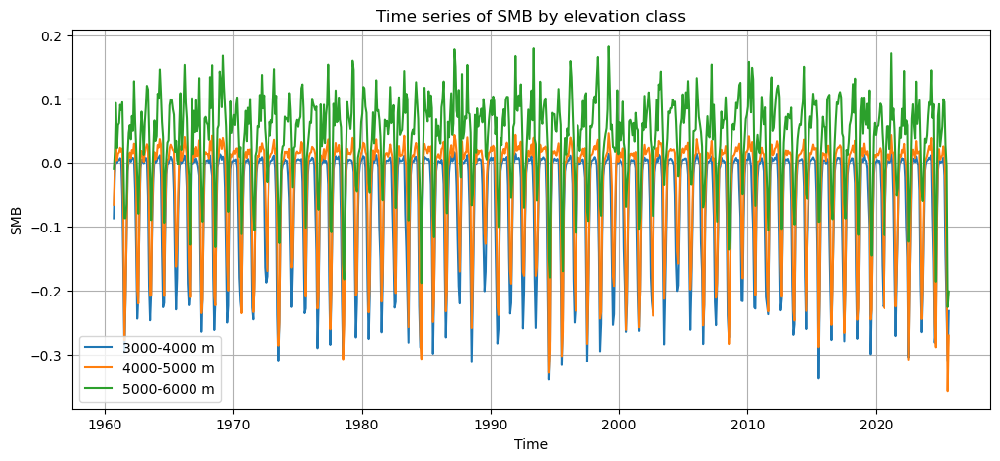

In [99]:
# Classes d'altitude
elev_bins = [3000, 4000, 5000, 6000]
elev_bin_labels = [
    "3000-4000 m",
    "4000-5000 m",
    "5000-6000 m"
]

ds_SMB = ds_SMB_WP.sel(time=slice("1960-09-01", "2025-08-31"))

# Dictionnaire pour stocker les séries temporelles par classe
SMB_by_elev = {}

# Boucle sur les classes d'altitude
for i in range(len(elev_bins)-1):
    
    zmin = elev_bins[i]
    zmax = elev_bins[i+1]
    
    # masque des points de grille dans la classe d'altitude
    mask_2 = (SH_pamir >= zmin) & (SH_pamir < zmax)
    
    # application du masque au SMB
    SMB_class = ds_SMB.where(mask_2)
    SMB_class = SMB_class#.resample(time="AS-SEP").sum()
    
    # moyenne spatiale (Y,X)
    SMB_ts = SMB_class.mean(dim=["Y", "X"], skipna=True)
    SMB_ts = SMB_ts
    SMB_by_elev[elev_bin_labels[i]] = SMB_ts


# Tracé
plt.figure(figsize=(12,5))

for label, ts in SMB_by_elev.items():
    plt.plot(
        ts.time,
        ts,
        label=label
    )

plt.xlabel("Time")
plt.ylabel("SMB")
plt.legend()
plt.grid()
plt.title("Time series of SMB by elevation class")
plt.show()

In [118]:
# Extraire de la database Dussaillant le point le plus proche de Fedchenko/Jasgulem
# A DISCUTER AVEC FANNY

# Faire une comparaison de la tendance SMB sur un site en particulier
# Ca n'a peut etre aucun sens ..!

# supprimer les lignes sans coordonnées
df_valid = dus_df_WP.dropna(subset=["lat", "lon"])

# calcul distance
dist = np.sqrt(
    (df_valid["lat"] - jasg_lat)**2 +
    (df_valid["lon"] - jasg_lon)**2
)

# position dans df_valid
idx_nearest = dist.values.argmin()

# extraction
nearest_point = df_valid.iloc[idx_nearest]

print(nearest_point[["lat", "lon"]])

lat    38.561303
lon    72.218702
Name: 19718, dtype: object


## Hugonnet et al. 2021

In [101]:
# Dussaillant = update of Hugonnet

In [117]:
hug_df_all = pd.read_csv('/bettik/PROJECTS/pr-regional-climate/bricej/dh_HIMAP_rates.csv')

subregs = ['Western Pamir', 'Pamir Alay', 'Eastern Pamir']
periods = ['2000-01-01_2010-01-01', '2010-01-01_2020-01-01', '2000-01-01_2020-01-01']
hug_df = hug_df_all[
    hug_df_all['subreg'].isin(subregs) &
    hug_df_all['period'].isin(periods)
]
hug_df = hug_df[['subreg', 'period', 'dhdt']]
hug_df = hug_df.rename(columns={"subreg": "region"})

## Barandun et al., 2021

In [112]:
# https://zenodo.org/records/4782116?preview_file=Barandunetal_annualtimeseries_mb.csv
# this dataset reported on RGI v6
baran_df = pd.read_csv('/bettik/PROJECTS/pr-regional-climate/fainx/PAMIR_SMB_OBS/Barandunetal_annualtimeseries_mb.csv', sep=",")

In [113]:
# Get glacier altitudes from RGI and include them to Baraudum dataset
rgi_v6["key"] = rgi_v6["RGIId"].str[-5:]

baran_df["RGI_code"] = baran_df["RGI_code"].astype(str)
baran_df["key"] = baran_df["RGI_code"].str[-5:]

baran_df = baran_df.merge(
    rgi_v6[["key", 'Zmin', 'Zmax', 'Zmed','Area','CenLon', 'CenLat']], # checked that area, lon, and lat reported by Dussaillant are identical to RGI v6 database => OK
    on="key",
    how="left"
)

baran_df = baran_df.drop(columns=["key"])
baran_df = baran_df.rename(columns={"CenLon": "lon"})
baran_df = baran_df.rename(columns={"CenLat": "lat"})
baran_df = baran_df.rename(columns={"Area": "area"})

baran_df.head()

,RGI_code,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,Zmin,Zmax,Zmed,area,lon,lat
0,13.04832,-1.69,0.32,0.01,0.06,0.36,0.32,-0.57,-0.61,-1.18,...,-0.46,-0.50,-0.89,-0.86,3280.0,4060.0,3652.0,2.403,80.944691,45.194752
1,13.04837,-1.69,0.21,-0.05,-0.06,0.20,-0.04,-0.89,-0.35,-0.78,...,-0.55,-0.32,-0.92,-0.40,3319.0,3923.0,3506.0,2.961,80.921483,45.163640
2,13.04867,-0.90,-0.77,-0.95,-0.66,-0.77,-0.69,-0.06,0.12,-0.10,...,-0.78,-0.81,-0.80,-0.80,3637.0,4610.0,4009.0,4.132,80.032757,42.353314
3,13.04873,-0.85,-0.71,-0.90,-0.60,-0.72,-0.63,-0.08,-0.09,-0.11,...,-0.74,-0.75,-0.74,-0.74,3673.0,4681.0,4028.0,4.781,80.058255,42.356050
4,13.04886,-0.87,-0.72,-0.84,-0.80,-0.88,-0.75,0.44,0.41,-0.09,...,-1.23,-0.94,-1.08,-1.08,3670.0,4314.0,3957.0,2.772,80.063274,42.394744


In [130]:
# Calculate mean SMB per decade

cols_2000_2009 = [str(y) for y in range(2000, 2010)]
cols_2010_2018 = [str(y) for y in range(2010, 2019)]
cols_2000_2018 = [str(y) for y in range(2000, 2019)]

baran_df["2000_2009_mean"] = baran_df[cols_2000_2009].mean(axis=1)
baran_df["2010_2018_mean"] = baran_df[cols_2010_2018].mean(axis=1)
baran_df["2000_2018_mean"] = baran_df[cols_2000_2018].mean(axis=1)

In [131]:
# en cas de bug recharger : 
#himap_folder = "/bettik/PROJECTS/pr-regional-climate/fainx/HMA_regions_Bolch/boundary_mountain_regions_hma_v3.shp"
#regions = gpd.read_file(himap_folder)
#regions = regions.to_crs(epsg=4326)
#regions[['OBJECTID','Primary_ID']]


# ----------------------------
# 1. construire GeoDataFrame depuis ds_baran
# ----------------------------
gdf = gpd.GeoDataFrame(
    baran_df,
    geometry=gpd.points_from_xy(baran_df["lon"], baran_df["lat"]),
    crs="EPSG:4326"
)

# ----------------------------
# 3. spatial join (point in polygon)
# ----------------------------
gdf_joined = gpd.sjoin(
    gdf,
    regions[["OBJECTID", "Primary_ID", "geometry"]],
    how="left",
    predicate="within"
)

# ----------------------------
# 5. retour DataFrame classique (sans geometry)
# ----------------------------
baran_df = gdf_joined.drop(columns="geometry")

In [132]:
baran_df_PA = baran_df[baran_df["OBJECTID"] == 5]
baran_df_WP = baran_df[baran_df["OBJECTID"] == 6]
baran_df_EP = baran_df[baran_df["OBJECTID"] == 7]

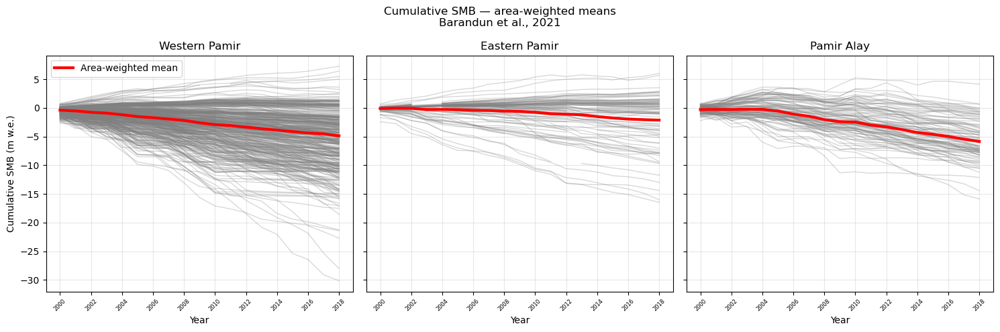

In [142]:
dfs = [baran_df_WP, baran_df_EP, baran_df_PA]
titles = ['Western Pamir', 'Eastern Pamir', 'Pamir Alay']

yrs = [str(y) for y in range(2000, 2019)]

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

for ax, df, title in zip(axes, dfs, titles):

    # SMB cumulatif pour chaque glacier
    cum_smb = df[yrs].cumsum(axis=1)

    # -----------------------------------------
    # Moyenne pondérée par la surface du glacier
    # -----------------------------------------
    weighted_mean_cum = (
        cum_smb.mul(df["area"], axis=0).sum(axis=0)
        / df["area"].sum()
    )

    # Moyenne pondérée par la surface
    
    ax.plot(yrs, cum_smb.T, color='gray', alpha=0.3, lw=1)
    
    ax.plot(
        yrs,
        weighted_mean_cum,
        color='red',
        lw=3,
        label='Area-weighted mean'
    )

    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.tick_params(axis='x', labelsize=6)
    ax.grid(alpha=0.3)


axes[0].set_ylabel('Cumulative SMB (m w.e.)')
axes[0].legend()

plt.suptitle(
    "Cumulative SMB — area-weighted means\nBarandun et al., 2021"
)

for ax in axes:
    ax.set_xticks(yrs[::2])
    ax.tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

### Comparaison Barandun et Dussaillant

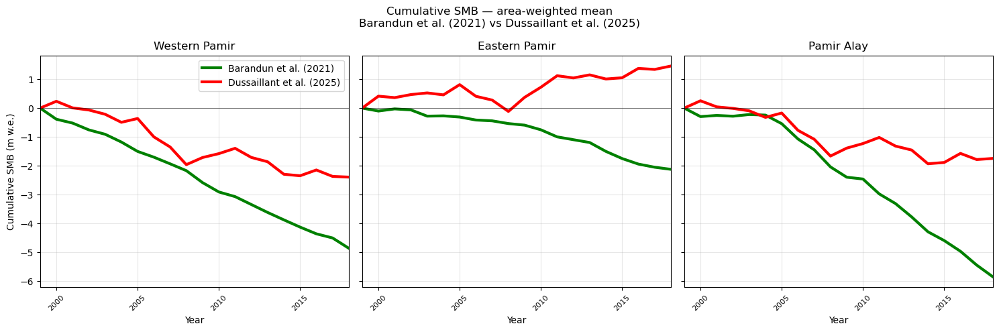

In [133]:
# ============================================================
# 0. DONNÉES
# ============================================================

dfs_baran = [
    baran_df_WP,
    baran_df_EP,
    baran_df_PA
]

dfs_dus = [
    dus_df_WP,
    dus_df_EP,
    dus_df_PA
]

titles = [
    'Western Pamir',
    'Eastern Pamir',
    'Pamir Alay'
]


# ============================================================
# 1. ANNÉES
# ============================================================

year_start = 2000
year_end = 2018

years = np.arange(
    year_start,
    year_end + 1
)

yrs = [
    str(y)
    for y in years
]


# ============================================================
# 2. FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)


# ============================================================
# 3. BOUCLE SUR LES RÉGIONS
# ============================================================

for ax, df_baran, df_dus, title in zip(
    axes,
    dfs_baran,
    dfs_dus,
    titles
):


    # ========================================================
    # BARANDUN
    # ========================================================

    # SMB annuel de chaque glacier
    smb_baran = df_baran[yrs]


    # --------------------------------------------------------
    # Cumul pour chaque glacier
    # --------------------------------------------------------

    cum_smb_baran = smb_baran.cumsum(
        axis=1
    )


    # --------------------------------------------------------
    # Moyenne pondérée par la surface
    # --------------------------------------------------------

    weighted_mean_cum_baran = (
        cum_smb_baran
        .mul(
            df_baran["area"],
            axis=0
        )
        .sum(axis=0)
        /
        df_baran["area"].sum()
    )


    # --------------------------------------------------------
    # Ajouter le point initial à 0
    # --------------------------------------------------------

    years_baran_plot = np.insert(
        years,
        0,
        year_start - 1
    )

    cum_baran_plot = np.insert(
        weighted_mean_cum_baran.values,
        0,
        0
    )


    # ========================================================
    # DUSSAILLANT
    # ========================================================

    # Garder uniquement les années disponibles
    yrs_dus = [
        y for y in yrs
        if y in df_dus.columns
    ]

    years_dus = np.array([
        int(y)
        for y in yrs_dus
    ])


    # --------------------------------------------------------
    # SMB annuel de chaque glacier
    # --------------------------------------------------------

    smb_dus = df_dus[yrs_dus]


    # --------------------------------------------------------
    # Cumul pour chaque glacier
    # --------------------------------------------------------

    cum_smb_dus = smb_dus.cumsum(
        axis=1
    )


    # --------------------------------------------------------
    # Moyenne pondérée par la surface
    # --------------------------------------------------------

    weighted_mean_cum_dus = (
        cum_smb_dus
        .mul(
            df_dus["area"],
            axis=0
        )
        .sum(axis=0)
        /
        df_dus["area"].sum()
    )


    # --------------------------------------------------------
    # Ajouter le point initial à 0
    # --------------------------------------------------------

    years_dus_plot = np.insert(
        years_dus,
        0,
        years_dus[0] - 1
    )

    cum_dus_plot = np.insert(
        weighted_mean_cum_dus.values,
        0,
        0
    )


    # ========================================================
    # 4. PLOT BARANDUN
    # ========================================================

    ax.plot(
        years_baran_plot,
        cum_baran_plot,
        color="green",
        lw=3,
        label="Barandun et al. (2021)"
    )


    # ========================================================
    # 5. PLOT DUSSAILLANT
    # ========================================================

    ax.plot(
        years_dus_plot,
        cum_dus_plot,
        color="red",
        lw=3,
        label="Dussaillant et al. (2025)"
    )


    # ========================================================
    # 6. LIGNE DE RÉFÉRENCE
    # ========================================================

    ax.axhline(
        0,
        color="black",
        lw=0.8,
        alpha=0.5
    )


    # ========================================================
    # 7. FORMAT DU PANEL
    # ========================================================

    ax.set_title(
        title
    )

    ax.set_xlabel(
        "Year"
    )

    ax.grid(
        alpha=0.3
    )


# ============================================================
# 8. LABEL Y
# ============================================================

axes[0].set_ylabel(
    "Cumulative SMB (m w.e.)"
)


# ============================================================
# 9. AXE X — ANNÉES NUMÉRIQUES
# ============================================================

ticks = np.arange(
    year_start,
    year_end + 1,
    5
)

for ax in axes:

    ax.set_xticks(
        ticks
    )

    ax.set_xlim(
        year_start - 1,
        year_end
    )

    ax.tick_params(
        axis="x",
        labelrotation=45,
        labelsize=8
    )


# ============================================================
# 10. LÉGENDE
# ============================================================

axes[0].legend(
    loc="best"
)


# ============================================================
# 11. TITRE GÉNÉRAL
# ============================================================

plt.suptitle(
    "Cumulative SMB — area-weighted mean\n"
    "Barandun et al. (2021) vs Dussaillant et al. (2025)"
)


# ============================================================
# 12. MISE EN PAGE
# ============================================================

plt.tight_layout()

plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


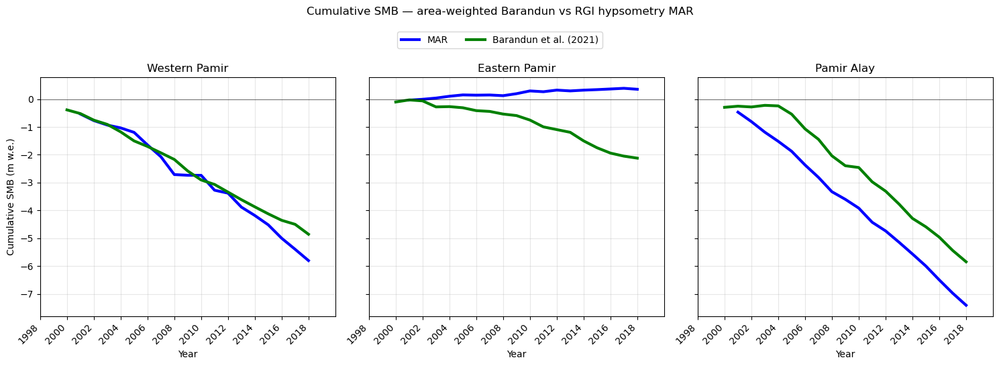

In [145]:
# ============================================================
# 1. PARAMÈTRES
# ============================================================

yr_start = '2000-10-01T12:00:00.000000000'
yr_stop  = '2018-09-30T12:00:00.000000000'

dz = 200


# ============================================================
# 2. DONNÉES DES 3 RÉGIONS
# ============================================================

regions = [
    {
        "name": "Western Pamir",
        "ds": ds_SMB_WP,
        "df": baran_df_WP.copy(),
        "hyps": hypsometry_rgi_WP.copy(),
    },
    {
        "name": "Eastern Pamir",
        "ds": ds_SMB_EP,
        "df": baran_df_EP.copy(),
        "hyps": hypsometry_rgi_EP.copy(),
    },
    {
        "name": "Pamir Alay",
        "ds": ds_SMB_PA,
        "df": baran_df_PA.copy(),
        "hyps": hypsometry_rgi_PA.copy(),
    }
]


# ============================================================
# 3. FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)


# ============================================================
# 4. BOUCLE SUR LES RÉGIONS
# ============================================================

for ax, region in zip(axes, regions):

    region_name = region["name"]
    da = region["ds"]
    df = region["df"]
    hyps_rgi = region["hyps"]


    # ========================================================
    # MAR : SMB annuel puis cumulatif
    # ========================================================

    da = (
        da
        .sel(
            time=slice(
                yr_start,
                yr_stop
            )
        )
        .resample(time="A-SEP")
        .sum()
    )

    cum_smb = da.cumsum(
        dim="time"
    )


    # ========================================================
    # Empilement spatial
    # ========================================================

    cum_smb_points = cum_smb.stack(
        points=("Y", "X")
    )

    elevation = SH_pamir.stack(
        points=("Y", "X")
    )

    ice = ICE_pamir.stack(
        points=("Y", "X")
    )


    # ========================================================
    # Garder uniquement les pixels glaciers
    # ========================================================

    valid_glacier = (
        (ice > 0) &
        np.isfinite(elevation) &
        np.isfinite(ice)
    )

    cum_smb_points = cum_smb_points.where(
        valid_glacier,
        drop=True
    )

    elevation = elevation.where(
        valid_glacier,
        drop=True
    )

    ice = ice.where(
        valid_glacier,
        drop=True
    )


    # ========================================================
    # Hypsométrie RGI
    # ========================================================

    altitude_rgi = hyps_rgi[
        "altitude_m"
    ].values

    percentage_rgi = hyps_rgi[
        "percentage_rgi"
    ].values


    # ========================================================
    # Classes d'altitude de 200 m
    # ========================================================

    bins = np.arange(
        altitude_rgi.min() - dz / 2,
        altitude_rgi.max() + dz / 2 + dz,
        dz
    )

    z_center = (
        bins[:-1] +
        bins[1:]
    ) / 2


    # ========================================================
    # Attribuer chaque pixel MAR à une classe
    # ========================================================

    class_index = np.digitize(
        elevation.values,
        bins
    ) - 1


    # ========================================================
    # SMB MAR moyen par classe d'altitude
    # ========================================================

    smb_by_altitude = []

    for i in range(
        len(z_center)
    ):

        pixel_class = (
            class_index == i
        )

        if not np.any(
            pixel_class
        ):

            smb_by_altitude.append(
                np.full(
                    cum_smb_points.time.size,
                    np.nan
                )
            )

            continue


        # ----------------------------------------------------
        # Sélection des pixels
        # ----------------------------------------------------

        indices = np.where(
            pixel_class
        )[0]

        smb_class = cum_smb_points.isel(
            points=indices
        )


        # ----------------------------------------------------
        # Moyenne ARITHMÉTIQUE des pixels
        #
        # Aucun poids ICE
        # ----------------------------------------------------

        smb_mean_class = smb_class.mean(
            dim="points",
            skipna=True
        )

        smb_by_altitude.append(
            smb_mean_class.values
        )


    smb_by_altitude = np.array(
        smb_by_altitude
    )


    # ========================================================
    # Alignement de l'hypsométrie RGI
    # ========================================================

    percentage_rgi_aligned = np.full(
        len(z_center),
        np.nan
    )

    for i, z in enumerate(
        z_center
    ):

        idx = np.argmin(
            np.abs(
                altitude_rgi - z
            )
        )

        if np.abs(
            altitude_rgi[idx] - z
        ) < dz / 2:

            percentage_rgi_aligned[i] = (
                percentage_rgi[idx]
            )


    # ========================================================
    # SMB régional MAR
    # pondéré par l'hypsométrie RGI
    # ========================================================

    weighted_smb_mar = []

    for t in range(
        cum_smb_points.time.size
    ):

        smb_t = smb_by_altitude[
            :, t
        ]

        valid = (
            np.isfinite(smb_t) &
            np.isfinite(
                percentage_rgi_aligned
            )
        )

        weighted_mean = (
            np.sum(
                smb_t[valid] *
                percentage_rgi_aligned[valid]
            )
            /
            np.sum(
                percentage_rgi_aligned[valid]
            )
        )

        weighted_smb_mar.append(
            weighted_mean
        )


    weighted_smb_mar = np.array(
        weighted_smb_mar
    )


    # ========================================================
    # Années MAR
    # ========================================================

    years_mar = [
        str(
            pd.Timestamp(t).year
        )
        for t in cum_smb_points.time.values
    ]

    years_mar_num = np.array([
        int(y)
        for y in years_mar
    ])


    # ========================================================
    # Barandun
    # ========================================================

    year_1 = pd.Timestamp(
        yr_start
    ).year

    year_2 = pd.Timestamp(
        yr_stop
    ).year + 1

    yrs = [
        str(y)
        for y in range(
            year_1,
            year_2
        )
    ]


    # ========================================================
    # SMB cumulatif de chaque glacier
    # ========================================================

    cum_smb_dus = df[
        yrs
    ].cumsum(
        axis=1
    )


    # ========================================================
    # Moyenne pondérée par la surface
    # ========================================================

    weighted_mean_dus = (
        cum_smb_dus
        .mul(
            df["area"],
            axis=0
        )
        .sum(
            axis=0
        )
        /
        df["area"].sum()
    )


    years_dus_num = np.array([
        int(y)
        for y in yrs
    ])


    # ========================================================
    # PLOT MAR
    # ========================================================

    ax.plot(
        years_mar_num,
        weighted_smb_mar,
        color="blue",
        lw=3,
        label="MAR"
    )


    # ========================================================
    # PLOT DUSSAILLANT
    # ========================================================

    ax.plot(
        years_dus_num,
        weighted_mean_dus.values,
        color="green",
        lw=3,
        label="Barandun et al. (2021)"
    )


    # ========================================================
    # SMB = 0
    # ========================================================

    ax.axhline(
        0,
        color="black",
        lw=0.8,
        alpha=0.5
    )


    # ========================================================
    # TITRE
    # ========================================================

    ax.set_title(
        region_name
    )


    # ========================================================
    # GRILLE
    # ========================================================

    ax.grid(
        alpha=0.3
    )


    # ========================================================
    # AXE X
    # ========================================================

    years_ticks = np.arange(
        1998,
        2020,
        2
    )

    ax.set_xticks(
        years_ticks
    )

    ax.set_xticklabels(
        [
            str(y)
            for y in years_ticks
        ],
        rotation=45,
        ha="right"
    )

    ax.set_xlim(
        1998,
        2020
    )


# ============================================================
# 5. LABELS COMMUNS
# ============================================================

axes[0].set_ylabel(
    "Cumulative SMB (m w.e.)"
)

for ax in axes:
    ax.set_xlabel(
        "Year"
    )


# ============================================================
# 6. LÉGENDE UNIQUE
# ============================================================

handles, labels = (
    axes[0].get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2
)


# ============================================================
# 7. TITRE GLOBAL
# ============================================================

fig.suptitle(
    "Cumulative SMB — area-weighted Barandun vs "
    "RGI hypsometry MAR",
    y=1.08
)


# ============================================================
# 8. MISE EN PAGE
# ============================================================

plt.tight_layout()

plt.show()


/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


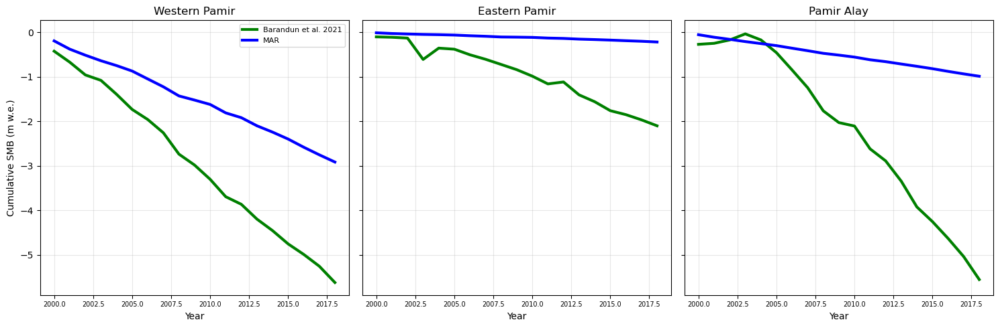

In [135]:
ds_baran_list = [baran_df_WP, baran_df_EP, baran_df_PA]
ds_mar_list = [ds_SMB_WP, ds_SMB_EP, ds_SMB_PA]

titles = [
    'Western Pamir',
    'Eastern Pamir',
    'Pamir Alay'
]

years = list(range(2000, 2019))
cols = [str(y) for y in years]

yr_start_mar = '1999-10-01T12:00:00'
yr_stop_mar  = '2018-09-30T12:00:00'

fig, axes = plt.subplots(
    1, 3,
    figsize=(15,5),
    sharex=True,
    sharey=True
)

weights = ICE_pamir.fillna(0)

for ax, df, ds, title in zip(
        axes, ds_baran_list, ds_mar_list, titles):

# Barandun
    cum_baran = df[cols].cumsum(axis=1)

#    ax.plot(years, cum_baran.T, color='gray', alpha=0.25, lw=0.8)
    ax.plot(years, cum_baran.mean(axis=0), color='green', lw=3, label='Barandun et al. 2021')

# MAR
    mar = (
        ds
        .sel(time=slice(yr_start_mar, yr_stop_mar))
        .resample(time="A-SEP")
        .sum()
    )

    mar_cum = mar.cumsum(dim="time")

    mar_mean = (
        mar_cum
#        .weighted(weights)
        .mean(dim=("Y","X"))
    )


    ax.plot(
        mar_mean.time.dt.year,
        mar_mean,
        color='blue',
        lw=3,
        label='MAR'
    )


    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(alpha=0.3)


axes[0].set_ylabel("Cumulative SMB (m w.e.)")
axes[0].legend(fontsize=8)

plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


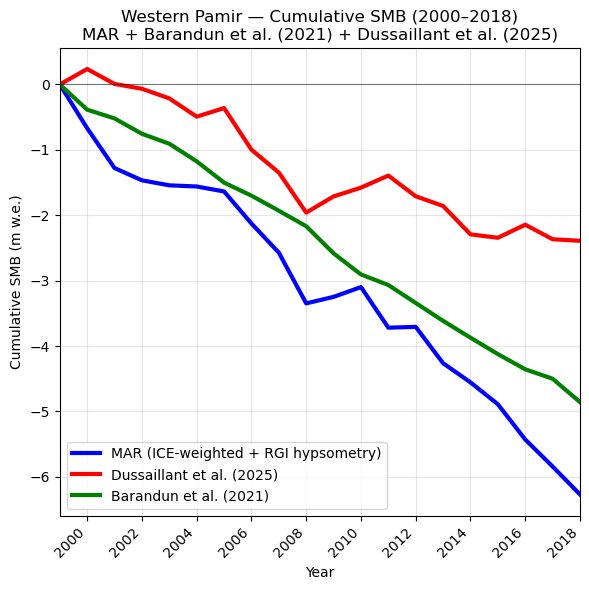

In [146]:
# ============================================================
# 0. INPUTS
# ============================================================

region_name = "Western Pamir"

# Période commune pour la comparaison
year_start = 2000
year_end = 2018

da = ds_SMB_WP

df = dus_df_WP.copy()

df_baran = baran_df_WP.copy()

hyps_rgi = hypsometry_rgi_WP.copy()


# ============================================================
# 1. MAR : SMB annuel puis cumulatif
#    2000-2018 uniquement
# ============================================================

da = (
    da
    .sel(
        time=slice(
            "1999-10-01",
            "2018-09-30"
        )
    )
    .resample(time="A-SEP")
    .sum()
)

cum_smb = da.cumsum(dim="time")


# ============================================================
# 2. Empilement spatial
# ============================================================

cum_smb_points = cum_smb.stack(
    points=("Y", "X")
)


elevation = (
    SH_pamir
    .where(
        mask_smb == region_id[region_name]
    )
    .stack(points=("Y", "X"))
)


ice = (
    ICE_pamir
    .where(
        mask_smb == region_id[region_name]
    )
    .stack(points=("Y", "X"))
)


# ============================================================
# 3. Garder uniquement les pixels glaciers
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation) &
    np.isfinite(ice)
)


cum_smb_points = cum_smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)

ice = ice.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

altitude_rgi = (
    hyps_rgi["altitude_m"].values
)

percentage_rgi = (
    hyps_rgi["percentage_rgi"].values
)

dz = 200


# ============================================================
# 5. Classes d'altitude de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (
    bins[:-1] + bins[1:]
) / 2


# ============================================================
# 6. Assigner chaque pixel MAR à une classe
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR moyen dans chaque classe
#    PONDÉRÉ PAR ICE
# ============================================================

smb_by_altitude = []

for i in range(len(z_center)):

    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(
                cum_smb_points.time.size,
                np.nan
            )
        )

        continue


    indices = np.where(
        pixel_class
    )[0]


    smb_class = (
        cum_smb_points.isel(
            points=indices
        )
    )


    ice_class = (
        ice.isel(
            points=indices
        )
    )


    # --------------------------------------------------------
    # Moyenne pondérée par ICE
    # --------------------------------------------------------

    smb_weighted_class = (
        (smb_class * ice_class).sum(
            dim="points",
            skipna=True
        )
        /
        ice_class.sum(
            dim="points",
            skipna=True
        )
    )


    smb_by_altitude.append(
        smb_weighted_class.values
    )


smb_by_altitude = np.array(
    smb_by_altitude
)


# ============================================================
# 8. Aligner l'hypsométrie RGI
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)


for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(
            altitude_rgi - z
        )
    )

    if np.abs(
        altitude_rgi[idx] - z
    ) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB régional MAR
#    pondéré par l'hypsométrie RGI
# ============================================================

weighted_smb_mar = []


for t in range(
    cum_smb_points.time.size
):

    smb_t = (
        smb_by_altitude[:, t]
    )


    valid = (
        np.isfinite(smb_t) &
        np.isfinite(
            percentage_rgi_aligned
        )
    )


    weighted_mean = (
        np.sum(
            smb_t[valid]
            *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )


    weighted_smb_mar.append(
        weighted_mean
    )


weighted_smb_mar = np.array(
    weighted_smb_mar
)


# ============================================================
# 10. ANNÉES MAR
# ============================================================

years_mar = np.arange(
    year_start,
    year_end + 1
)


# Ajouter le point initial à 0
years_mar_plot = np.insert(
    years_mar,
    0,
    year_start - 1
)

cum_mar_plot = np.insert(
    weighted_smb_mar,
    0,
    0
)


# ============================================================
# 11. DUSSAILLANT
#     2000-2018 uniquement
# ============================================================

yrs = [
    str(y)
    for y in range(
        year_start,
        year_end + 1
    )
]


# ------------------------------------------------------------
# Vérifier les années disponibles
# ------------------------------------------------------------

yrs_dus = [
    y
    for y in yrs
    if y in df.columns
]


years_dus = np.array([
    int(y)
    for y in yrs_dus
])


# ------------------------------------------------------------
# SMB annuel de chaque glacier
# ------------------------------------------------------------

smb_dus = df[yrs_dus]


# ------------------------------------------------------------
# Cumul pour chaque glacier
# ------------------------------------------------------------

cum_smb_dus = smb_dus.cumsum(
    axis=1
)


# ------------------------------------------------------------
# Moyenne pondérée par la surface
# ------------------------------------------------------------

weighted_mean_dus = (
    cum_smb_dus
    .mul(
        df["area"],
        axis=0
    )
    .sum(axis=0)
    /
    df["area"].sum()
)


# ------------------------------------------------------------
# Ajouter le point initial à 0
# ------------------------------------------------------------

years_dus_plot = np.insert(
    years_dus,
    0,
    year_start - 1
)

cum_dus_plot = np.insert(
    weighted_mean_dus.values,
    0,
    0
)


# ============================================================
# 12. BARANDUN
#     2000-2018
# ============================================================

years_baran = np.arange(
    year_start,
    year_end + 1
)


yrs_baran = [
    str(y)
    for y in years_baran
]


# ------------------------------------------------------------
# SMB annuel de chaque glacier
# ------------------------------------------------------------

smb_baran = (
    df_baran[yrs_baran]
)


# ------------------------------------------------------------
# Cumul pour chaque glacier
# ------------------------------------------------------------

cum_smb_baran = (
    smb_baran.cumsum(
        axis=1
    )
)


# ------------------------------------------------------------
# Moyenne pondérée par la surface
# ------------------------------------------------------------

weighted_mean_cum_baran = (
    cum_smb_baran
    .mul(
        df_baran["area"],
        axis=0
    )
    .sum(axis=0)
    /
    df_baran["area"].sum()
)


# ------------------------------------------------------------
# Ajouter le point initial à 0
# ------------------------------------------------------------

years_baran_plot = np.insert(
    years_baran,
    0,
    year_start - 1
)

cum_baran_plot = np.insert(
    weighted_mean_cum_baran.values,
    0,
    0
)


# ============================================================
# 13. FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 6)
)


# ============================================================
# 14. MAR
# ============================================================

ax.plot(
    years_mar_plot,
    cum_mar_plot,
    color="blue",
    lw=3,
    label="MAR (ICE-weighted + RGI hypsometry)"
)


# ============================================================
# 15. DUSSAILLANT
# ============================================================

ax.plot(
    years_dus_plot,
    cum_dus_plot,
    color="red",
    lw=3,
    label="Dussaillant et al. (2025)"
)


# ============================================================
# 16. BARANDUN
# ============================================================

ax.plot(
    years_baran_plot,
    cum_baran_plot,
    color="green",
    lw=3,
    label="Barandun et al. (2021)"
)


# ============================================================
# 17. Ligne SMB = 0
# ============================================================

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ============================================================
# 18. LABELS
# ============================================================

ax.set_xlabel(
    "Year"
)

ax.set_ylabel(
    "Cumulative SMB (m w.e.)"
)


# ============================================================
# 19. AXE X
# ============================================================

ticks = np.arange(
    year_start,
    year_end + 1,
    2
)

ax.set_xticks(
    ticks
)

ax.set_xticklabels(
    [str(y) for y in ticks],
    rotation=45,
    ha="right"
)


# ============================================================
# 20. LIMITES
# ============================================================

ax.set_xlim(
    year_start - 1,
    year_end
)


# ============================================================
# 21. TITRE
# ============================================================

ax.set_title(
    f"{region_name} — Cumulative SMB (2000–2018)\n"
    "MAR + Barandun et al. (2021) + "
    "Dussaillant et al. (2025)"
)


# ============================================================
# 22. GRILLE + LÉGENDE
# ============================================================

ax.grid(
    alpha=0.3
)

ax.legend()


plt.tight_layout()

plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


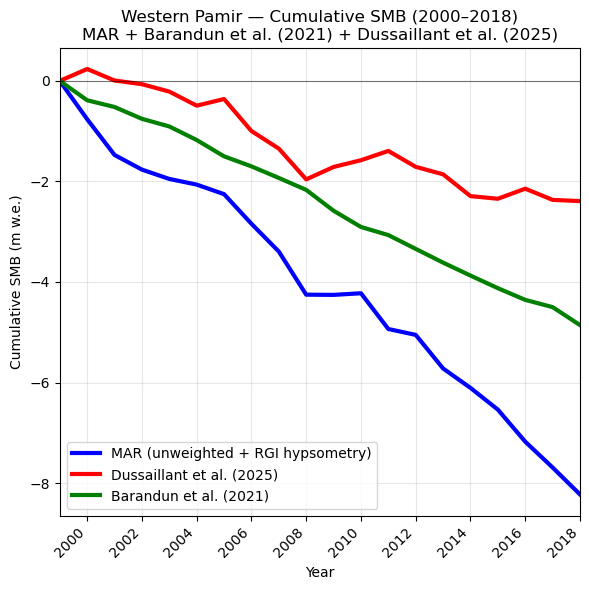

In [149]:
# ============================================================
# 0. INPUTS
# ============================================================

region_name = "Western Pamir"

# Période commune pour la comparaison
year_start = 2000
year_end = 2018

da = ds_SMB_WP

df = dus_df_WP.copy()

df_baran = baran_df_WP.copy()

hyps_rgi = hypsometry_rgi_WP.copy()


# ============================================================
# 1. MAR : SMB annuel puis cumulatif
#    2000-2018 uniquement
# ============================================================

da = (
    da
    .sel(
        time=slice(
            "1999-10-01",
            "2018-09-30"
        )
    )
    .resample(time="A-SEP")
    .sum()
)

cum_smb = da.cumsum(dim="time")


# ============================================================
# 2. Empilement spatial
# ============================================================

cum_smb_points = cum_smb.stack(
    points=("Y", "X")
)


elevation = (
    SH_pamir
    .where(
        mask_smb == region_id[region_name]
    )
    .stack(points=("Y", "X"))
)


ice = (
    ICE_pamir
    .where(
        mask_smb == region_id[region_name]
    )
    .stack(points=("Y", "X"))
)


# ============================================================
# 3. Garder uniquement les pixels glaciers
# ============================================================
#
# ICE est utilisé uniquement comme MASQUE.
# Il ne sert PAS de poids dans le calcul du SMB.
# ============================================================

valid_glacier = (
    (ice > 0) &
    np.isfinite(elevation) &
    np.isfinite(ice)
)


cum_smb_points = cum_smb_points.where(
    valid_glacier,
    drop=True
)

elevation = elevation.where(
    valid_glacier,
    drop=True
)

ice = ice.where(
    valid_glacier,
    drop=True
)


# ============================================================
# 4. Hypsométrie RGI
# ============================================================

altitude_rgi = (
    hyps_rgi["altitude_m"].values
)

percentage_rgi = (
    hyps_rgi["percentage_rgi"].values
)

dz = 200


# ============================================================
# 5. Classes d'altitude de 200 m
# ============================================================

bins = np.arange(
    altitude_rgi.min() - dz / 2,
    altitude_rgi.max() + dz / 2 + dz,
    dz
)

z_center = (
    bins[:-1] + bins[1:]
) / 2


# ============================================================
# 6. Assigner chaque pixel MAR à une classe
# ============================================================

class_index = np.digitize(
    elevation.values,
    bins
) - 1


# ============================================================
# 7. SMB MAR moyen dans chaque classe
#    SANS PONDÉRATION PAR ICE
# ============================================================
#
# Chaque pixel glacier possède le même poids.
#
# SMB(z) = moyenne des SMB des pixels de la classe.
# ============================================================

smb_by_altitude = []

for i in range(len(z_center)):

    pixel_class = class_index == i

    if not np.any(pixel_class):

        smb_by_altitude.append(
            np.full(
                cum_smb_points.time.size,
                np.nan
            )
        )

        continue


    indices = np.where(
        pixel_class
    )[0]


    smb_class = (
        cum_smb_points.isel(
            points=indices
        )
    )


    # --------------------------------------------------------
    # Moyenne ARITHMÉTIQUE des pixels
    #
    # Aucun poids ICE
    # --------------------------------------------------------

    smb_mean_class = (
        smb_class.mean(
            dim="points",
            skipna=True
        )
    )


    smb_by_altitude.append(
        smb_mean_class.values
    )


smb_by_altitude = np.array(
    smb_by_altitude
)


# ============================================================
# 8. Aligner l'hypsométrie RGI
# ============================================================

percentage_rgi_aligned = np.full(
    len(z_center),
    np.nan
)


for i, z in enumerate(z_center):

    idx = np.argmin(
        np.abs(
            altitude_rgi - z
        )
    )

    if np.abs(
        altitude_rgi[idx] - z
    ) < dz / 2:

        percentage_rgi_aligned[i] = (
            percentage_rgi[idx]
        )


# ============================================================
# 9. SMB régional MAR
#    pondéré par l'hypsométrie RGI
# ============================================================

weighted_smb_mar = []


for t in range(
    cum_smb_points.time.size
):

    smb_t = (
        smb_by_altitude[:, t]
    )


    valid = (
        np.isfinite(smb_t) &
        np.isfinite(
            percentage_rgi_aligned
        )
    )


    weighted_mean = (
        np.sum(
            smb_t[valid]
            *
            percentage_rgi_aligned[valid]
        )
        /
        np.sum(
            percentage_rgi_aligned[valid]
        )
    )


    weighted_smb_mar.append(
        weighted_mean
    )


weighted_smb_mar = np.array(
    weighted_smb_mar
)


# ============================================================
# 10. ANNÉES MAR
# ============================================================

years_mar = np.arange(
    year_start,
    year_end + 1
)


# Ajouter le point initial à 0
years_mar_plot = np.insert(
    years_mar,
    0,
    year_start - 1
)

cum_mar_plot = np.insert(
    weighted_smb_mar,
    0,
    0
)


# ============================================================
# 11. DUSSAILLANT
#     2000-2018 uniquement
# ============================================================

yrs = [
    str(y)
    for y in range(
        year_start,
        year_end + 1
    )
]


# ------------------------------------------------------------
# Vérifier les années disponibles
# ------------------------------------------------------------

yrs_dus = [
    y
    for y in yrs
    if y in df.columns
]


years_dus = np.array([
    int(y)
    for y in yrs_dus
])


# ------------------------------------------------------------
# SMB annuel de chaque glacier
# ------------------------------------------------------------

smb_dus = df[yrs_dus]


# ------------------------------------------------------------
# Cumul pour chaque glacier
# ------------------------------------------------------------

cum_smb_dus = smb_dus.cumsum(
    axis=1
)


# ------------------------------------------------------------
# Moyenne pondérée par la surface
# ------------------------------------------------------------

weighted_mean_dus = (
    cum_smb_dus
    .mul(
        df["area"],
        axis=0
    )
    .sum(axis=0)
    /
    df["area"].sum()
)


# ------------------------------------------------------------
# Ajouter le point initial à 0
# ------------------------------------------------------------

years_dus_plot = np.insert(
    years_dus,
    0,
    year_start - 1
)

cum_dus_plot = np.insert(
    weighted_mean_dus.values,
    0,
    0
)


# ============================================================
# 12. BARANDUN
#     2000-2018
# ============================================================

years_baran = np.arange(
    year_start,
    year_end + 1
)


yrs_baran = [
    str(y)
    for y in years_baran
]


# ------------------------------------------------------------
# SMB annuel de chaque glacier
# ------------------------------------------------------------

smb_baran = (
    df_baran[yrs_baran]
)


# ------------------------------------------------------------
# Cumul pour chaque glacier
# ------------------------------------------------------------

cum_smb_baran = (
    smb_baran.cumsum(
        axis=1
    )
)


# ------------------------------------------------------------
# Moyenne pondérée par la surface
# ------------------------------------------------------------

weighted_mean_cum_baran = (
    cum_smb_baran
    .mul(
        df_baran["area"],
        axis=0
    )
    .sum(axis=0)
    /
    df_baran["area"].sum()
)


# ------------------------------------------------------------
# Ajouter le point initial à 0
# ------------------------------------------------------------

years_baran_plot = np.insert(
    years_baran,
    0,
    year_start - 1
)

cum_baran_plot = np.insert(
    weighted_mean_cum_baran.values,
    0,
    0
)


# ============================================================
# 13. FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 6)
)


# ============================================================
# 14. MAR
# ============================================================

ax.plot(
    years_mar_plot,
    cum_mar_plot,
    color="blue",
    lw=3,
    label="MAR (unweighted + RGI hypsometry)"
)


# ============================================================
# 15. DUSSAILLANT
# ============================================================

ax.plot(
    years_dus_plot,
    cum_dus_plot,
    color="red",
    lw=3,
    label="Dussaillant et al. (2025)"
)


# ============================================================
# 16. BARANDUN
# ============================================================

ax.plot(
    years_baran_plot,
    cum_baran_plot,
    color="green",
    lw=3,
    label="Barandun et al. (2021)"
)


# ============================================================
# 17. Ligne SMB = 0
# ============================================================

ax.axhline(
    0,
    color="black",
    lw=0.8,
    alpha=0.5
)


# ============================================================
# 18. LABELS
# ============================================================

ax.set_xlabel(
    "Year"
)

ax.set_ylabel(
    "Cumulative SMB (m w.e.)"
)


# ============================================================
# 19. AXE X
# ============================================================

ticks = np.arange(
    year_start,
    year_end + 1,
    2
)

ax.set_xticks(
    ticks
)

ax.set_xticklabels(
    [str(y) for y in ticks],
    rotation=45,
    ha="right"
)


# ============================================================
# 20. LIMITES
# ============================================================

ax.set_xlim(
    year_start - 1,
    year_end
)


# ============================================================
# 21. TITRE
# ============================================================

ax.set_title(
    f"{region_name} — Cumulative SMB (2000–2018)\n"
    "MAR + Barandun et al. (2021) + "
    "Dussaillant et al. (2025)"
)


# ============================================================
# 22. GRILLE + LÉGENDE
# ============================================================

ax.grid(
    alpha=0.3
)

ax.legend()


plt.tight_layout()

plt.show()


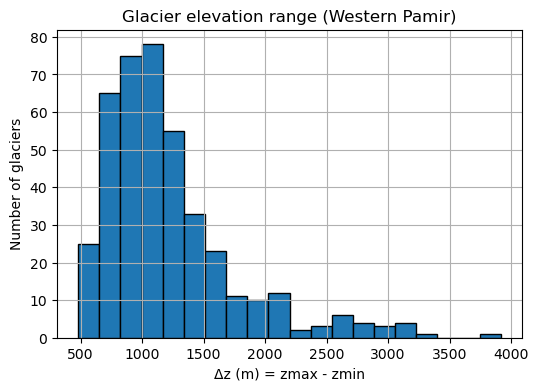

In [146]:
df = baran_df_WP.copy()
df["dz_m"] = df["Zmax"] - df["Zmin"]

plt.figure(figsize=(6,4))

plt.hist(df["dz_m"], bins=20, edgecolor="black")

plt.xlabel("Δz (m) = zmax - zmin")
plt.ylabel("Number of glaciers")
plt.title("Glacier elevation range (Western Pamir)")
plt.grid()

plt.show()

In [147]:
# Classes d'altitude
elev_bins = np.arange(3000, 7000, 500)
elev_bin_labels = [
    "3000-3500 m",
    "3500-4000 m",
    "4000-4500 m",
    "4500-5000 m",
    "5000-5500 m",
    "5500-6000 m",
    "6000-6500 m",
]
elev_bins

array([3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500])

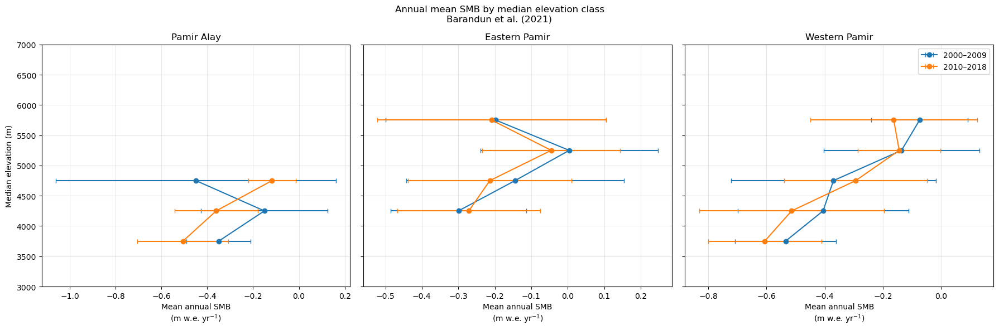

In [148]:
# ==========================
# Classes d'altitude
# ==========================

elev_bins = np.arange(3000, 7000, 500)

# centre des classes
elev_centers = (elev_bins[:-1] + elev_bins[1:]) / 2


# ==========================
# DataFrames
# ==========================

df_baran_list = [
    baran_df_PA,
    baran_df_EP,
    baran_df_WP
]

region_names = [
    "Pamir Alay",
    "Eastern Pamir",
    "Western Pamir"
]


# ==========================
# Figure
# ==========================

fig, axes = plt.subplots(
    1, 3,
    figsize=(18,6),
    sharey=True
)


for i, df in enumerate(df_baran_list):

    df = df.copy()


    # ----------------------------
    # classes altitude médiane
    # ----------------------------

    df["elev_bin"] = pd.cut(
        df["Zmed"],
        bins=elev_bins
    )


    # ----------------------------
    # statistiques par classe
    # ----------------------------

    stats = (
        df
        .groupby("elev_bin", observed=False)[
            [
                "2000_2009_mean",
                "2010_2018_mean"
            ]
        ]
        .agg(["mean", "std"])
        .dropna()
    )


    ax = axes[i]


    # récupérer les centres d'altitude
    y = []

    for interval in stats.index:
        y.append(interval.mid)

    y = np.array(y)


    # ----------------------------
    # période 2000-2009
    # ----------------------------

    x1 = stats[("2000_2009_mean", "mean")]
    x1_err = stats[("2000_2009_mean", "std")]


    ax.errorbar(
        x1,
        y,
        xerr=x1_err,
        fmt='-o',
        capsize=3,
        label="2000–2009"
    )


    # ----------------------------
    # période 2010-2018
    # ----------------------------

    x2 = stats[("2010_2018_mean", "mean")]
    x2_err = stats[("2010_2018_mean", "std")]


    ax.errorbar(
        x2,
        y,
        xerr=x2_err,
        fmt='-o',
        capsize=3,
        label="2010–2018"
    )


    # ----------------------------
    # mise en forme
    # ----------------------------

    ax.set_title(region_names[i])

    ax.set_xlabel(
        "Mean annual SMB\n(m w.e. yr$^{-1}$)"
    )

    ax.grid(alpha=0.3)


axes[0].set_ylabel(
    "Median elevation (m)"
)

axes[0].set_ylim(3000, 7000)

axes[2].legend()


plt.suptitle(
    "Annual mean SMB by median elevation class\nBarandun et al. (2021)"
)

plt.tight_layout()
plt.show()

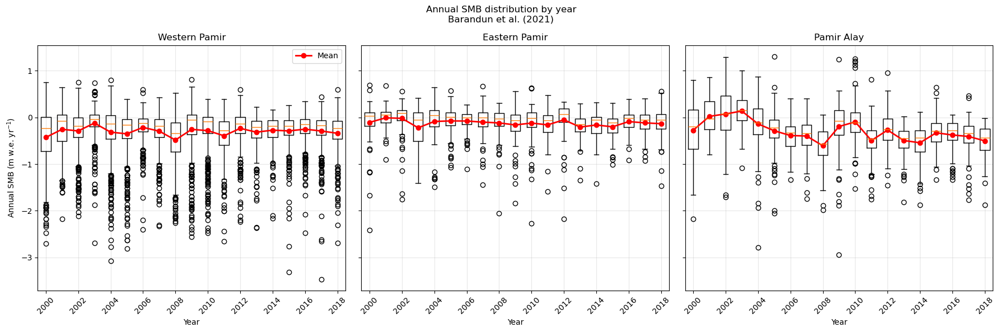

In [149]:
# ==========================
# Données
# ==========================

df_baran_list = [
    baran_df_WP,
    baran_df_EP,
    baran_df_PA
]

region_names = [
    "Western Pamir",
    "Eastern Pamir",
    "Pamir Alay"
]


years = [str(y) for y in range(2000, 2019)]


# ==========================
# Figure
# ==========================

fig, axes = plt.subplots(
    1, 3,
    figsize=(18,6),
    sharey=True
)


for ax, df, region in zip(
        axes,
        df_baran_list,
        region_names):


    # --------------------------
    # préparation des données
    # --------------------------

    smb_data = [
        df[year].dropna().values
        for year in years
    ]


    # --------------------------
    # boxplot
    # --------------------------

    ax.boxplot(
        smb_data,
        positions=np.arange(len(years)),
        widths=0.6,
        showfliers=True
    )


    # --------------------------
    # moyenne annuelle
    # --------------------------

    mean_smb = [
        df[year].mean()
        for year in years
    ]

    ax.plot(
        np.arange(len(years)),
        mean_smb,
        color='red',
        lw=2,
        marker='o',
        label='Mean'
    )


    # --------------------------
    # mise en forme
    # --------------------------

    ax.set_title(region)

    ax.set_xticks(
        np.arange(len(years))[::2]
    )

    ax.set_xticklabels(
        years[::2],
        rotation=45
    )

    ax.set_xlabel("Year")

    ax.grid(alpha=0.3)



axes[0].set_ylabel(
    "Annual SMB (m w.e. yr$^{-1}$)"
)

axes[0].legend()


plt.suptitle(
    "Annual SMB distribution by year\nBarandun et al. (2021)"
)

plt.tight_layout()
plt.show()

NameError: name 'Patch' is not defined

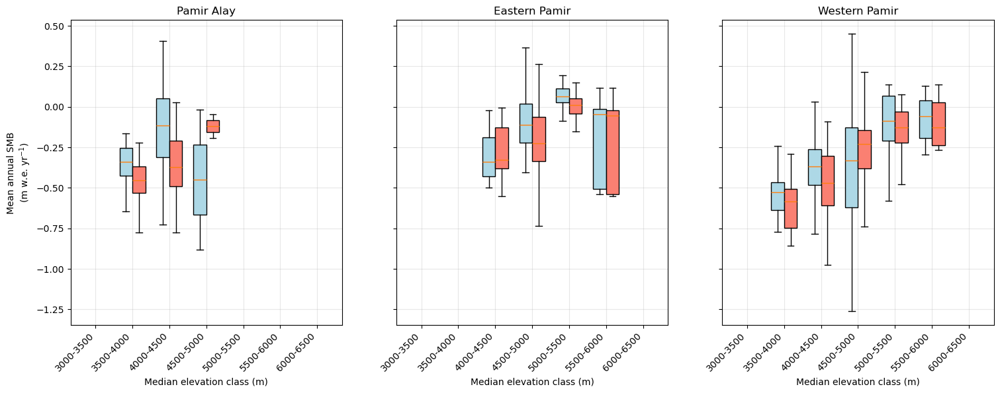

In [150]:
# ==========================
# Classes d'altitude
# ==========================

elev_bins = np.arange(3000, 7000, 500)


# ==========================
# DataFrames
# ==========================

df_baran_list = [
    baran_df_PA,
    baran_df_EP,
    baran_df_WP
]

region_names = [
    "Pamir Alay",
    "Eastern Pamir",
    "Western Pamir"
]


periods = {
    "2000–2009": [str(y) for y in range(2000, 2010)],
    "2010–2018": [str(y) for y in range(2010, 2019)]
}


# ==========================
# Figure
# ==========================

fig, axes = plt.subplots(
    1, 3,
    figsize=(18,6),
    sharey=True
)


for ax, df, region in zip(
        axes,
        df_baran_list,
        region_names):


    df = df.copy()


    # classes altitude
    df["elev_bin"] = pd.cut(
        df["Zmed"],
        bins=elev_bins
    )


    data_2000 = []
    data_2010 = []

    labels = []


    for elev_class in df["elev_bin"].cat.categories:

        df_class = df[
            df["elev_bin"] == elev_class
        ]


        smb_2000 = (
            df_class[periods["2000–2009"]]
            .mean(axis=1)
            .dropna()
        )

        smb_2010 = (
            df_class[periods["2010–2018"]]
            .mean(axis=1)
            .dropna()
        )


        data_2000.append(smb_2000.values)
        data_2010.append(smb_2010.values)


        labels.append(
            f"{elev_class.left:.0f}-"
            f"{elev_class.right:.0f}"
        )


    # positions côte à côte
    pos = np.arange(len(labels))

    width = 0.35


    bp1 = ax.boxplot(
        data_2000,
        positions=pos-width/2,
        widths=width,
        patch_artist=True,
        showfliers=False
    )


    bp2 = ax.boxplot(
        data_2010,
        positions=pos+width/2,
        widths=width,
        patch_artist=True,
        showfliers=False
    )


    # couleurs
    for box in bp1["boxes"]:
        box.set_facecolor("lightblue")

    for box in bp2["boxes"]:
        box.set_facecolor("salmon")


    ax.set_xticks(pos)

    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right"
    )


    ax.set_title(region)

    ax.set_xlabel(
        "Median elevation class (m)"
    )

    ax.grid(alpha=0.3)



axes[0].set_ylabel(
    "Mean annual SMB\n(m w.e. yr$^{-1}$)"
)


# légende commune
legend_elements = [
    Patch(facecolor="lightblue",
          label="2000–2009"),
    Patch(facecolor="salmon",
          label="2010–2018")
]

axes[2].legend(
    handles=legend_elements,
    loc="best"
)


plt.suptitle(
    "Annual mean SMB distribution by median elevation class\nBarandun et al. (2021)"
)

plt.tight_layout()
plt.show()

## In situ SMB Obs Timeseries

In [157]:
others_glaciers_df = pd.DataFrame(others_glaciers_list)

In [158]:
glaciers = pd.concat([wgms_glaciers, others_glaciers_df], ignore_index=True)
glaciers

,name,id,latitude,longitude
0,Abramov,732.0,39.620000,71.560000
1,Zulmart,13493.0,38.862824,73.003255
2,Kyzylsu,9276.0,39.473701,73.543701
3,Glacier_457,21063.0,37.397110,72.827362
4,Kangxiwa,NaN,38.280000,75.280000
5,Fedchenko,NaN,38.540630,72.269816
6,Kon Chukurbashi,NaN,39.250066,73.557790


/tmp/ipykernel_2580185/3838870106.py:38: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for coll in ICE2.collections:


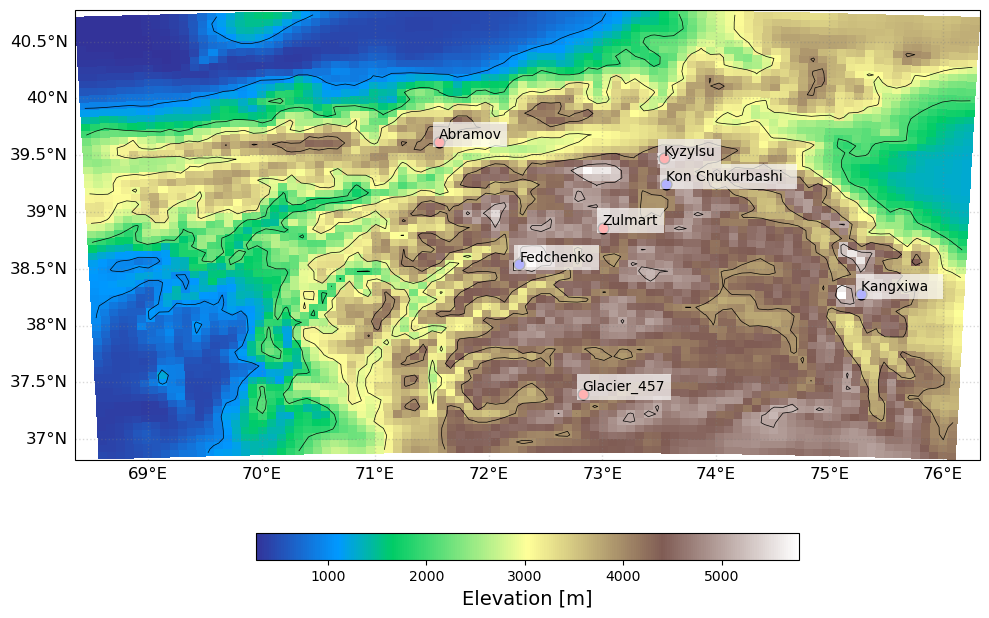

In [159]:
cmap = 'terrain'

# --- FIGURE ---
fig = plt.figure(figsize=(10, 15))

ax2 = fig.add_subplot(111, projection=ccrs.PlateCarree())

# --- DATA ---
CS2 = ax2.pcolormesh(LONS_pamir, LATS_pamir,SH_pamir,
                     transform=ccrs.PlateCarree(),
                     cmap=cmap, shading="auto")

# --- GRIDLINES ---
gl = ax2.gridlines(draw_labels=True,
                   linewidth=1, color="gray",
                   alpha=0.3, linestyle=":")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

# --- CONTOURS ---
ax2.contour(LONS_pamir, LATS_pamir,SH_pamir,
            levels=[1000, 2000, 3000, 4000, 5000, 6000, 7000],
            colors="k", linewidths=0.5,
            transform=ccrs.PlateCarree())

# --- ICE HATCHING ---
ICE2 = ax2.contourf(
    LONS_pamir, LATS_pamir,SH_pamir,
    levels=[20, 100],
    hatches=['XX'],
    colors='none',
    transform=ccrs.PlateCarree(),
    zorder=5
)

for coll in ICE2.collections:
    coll.set_edgecolor('cyan')
    coll.set_linewidth(0.6)
    coll.set_facecolor('none')
    coll.set_zorder(6)


for _, row in glaciers.iterrows():
    ax2.scatter(
        row["longitude"],
        row["latitude"],
        s=60,
        color="red" if not np.isnan(row["id"]) else "blue",
        edgecolor="black",
        transform=ccrs.PlateCarree(),
        zorder=10
    )

for _, row in glaciers.iterrows():
    ax2.text(
        row["longitude"],
        row["latitude"],
        row["name"],
        fontsize=10,
        ha="left",
        va="bottom",
        transform=ccrs.PlateCarree(),
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
        zorder=11
    )

# --- COLORBAR ---
cbar = fig.colorbar(
    CS2,
    ax=ax2,
    orientation="horizontal",
    pad=0.05,
    fraction=0.05,
    shrink=0.6
)

cbar.set_label("Elevation [m]", fontsize=14)


# --- LAYOUT ---
plt.tight_layout()

plt.show()

In [151]:
wgms_smb_df = pd.read_csv(wgms_folder+wgms_file_smb , sep=",")

In [152]:
wgms_smb_df = pd.read_csv(wgms_folder+wgms_file_smb , sep=",")
wgms_smb_df = wgms_smb_df.rename(columns={"glacier_id": "id"})

wgms_smb_df["id"] = pd.to_numeric(wgms_smb_df["id"], errors="coerce")
wgms_smb_df["year"] = pd.to_numeric(wgms_smb_df["year"], errors="coerce")

In [153]:
balance_col = "annual_balance"

In [154]:
smb_obs = {}

for _, row in wgms_glaciers.iterrows():
    gid = row["id"]
    sub = wgms_smb_df.loc[wgms_smb_df["id"] == gid, ["year", balance_col]].dropna()
    sub = sub.sort_values("year")
    smb_obs[row["name"]] = sub

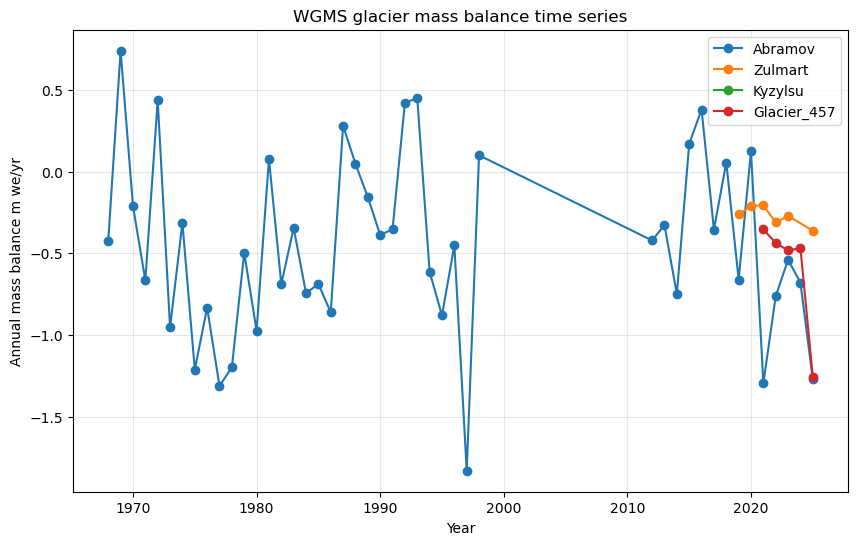

In [155]:
plt.figure(figsize=(10, 6))

for name, ts in smb_obs.items():
    
    plt.plot(
        ts["year"],
        ts[balance_col],
        marker="o",
        linewidth=1.5,
        label=name
    )

plt.xlabel("Year")
plt.ylabel("Annual mass balance m we/yr")
plt.title("WGMS glacier mass balance time series")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

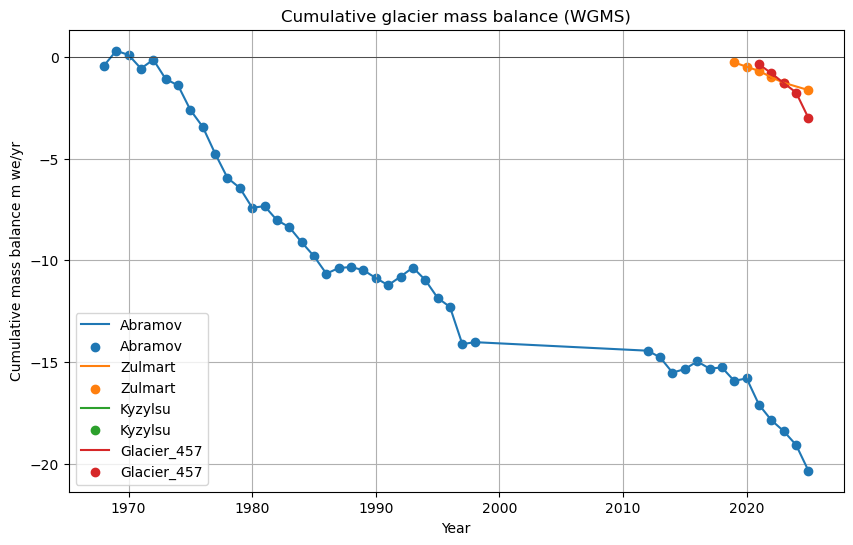

In [156]:
plt.figure(figsize=(10,6))

for name, df in smb_obs.items():
    
    # tri par année (important)
    df = df.sort_values("year")
    
    # cumul SMB
    df["cumulative_smb"] = df["annual_balance"].cumsum()
    
    # plot
    plt.plot(df["year"], df["cumulative_smb"], label=name)
    plt.scatter(df["year"], df["cumulative_smb"], label=name)

# ----------------------------
# styling
# ----------------------------
plt.axhline(0, color="black", linewidth=0.4)
plt.xlabel("Year")
plt.ylabel("Cumulative mass balance m we/yr")
plt.title("Cumulative glacier mass balance (WGMS)")
plt.legend()
plt.grid()
plt.show()